In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import LeaveOneOut
import numpy as np
import pdb
from imblearn.over_sampling import SMOTE
#from catboost import CatBoostClassifier
#from imblearn.combine import SMOTEENN  # ✅ Import SMOTEENN
from collections import Counter
print("okay")

okay


In [2]:
file_path = '/home/tanvirdell3/Downloads/ASDvsControl/Waves data Individual Trajectories-modified.xlsx'

In [3]:
asd_data = pd.read_excel(file_path, sheet_name="ASD", skiprows=0, nrows=237)
control_data = pd.read_excel(file_path, sheet_name="Control", skiprows=0, nrows=237)

In [4]:
# Drop all columns starting with "Unnamed"
asd_data = asd_data.loc[:, ~asd_data.columns.str.startswith('Unnamed')]
control_data = control_data.loc[:, ~control_data.columns.str.startswith('Unnamed')]
print('*')

*


In [5]:
asd_data.shape, control_data.shape

((237, 1025), (237, 1563))

In [5]:
selected_asd = asd_data.drop(index=[0, 1]).reset_index(drop=True)
selected_control = control_data.drop(index=[0, 1]).reset_index(drop=True)

In [7]:
selected_asd.shape, selected_control.shape

((235, 1025), (235, 1563))

In [6]:
filtered_asd_df = selected_asd.T  
filtered_control_df = selected_control.T 
print('*')

*


In [7]:
asd_reshaped = filtered_asd_df.reset_index(drop=True)
control_reshaped = filtered_control_df.reset_index(drop=True)
print('*')

*


In [8]:
n_features = asd_reshaped.shape[1]
asd_reshaped.columns = [f'F{i}' for i in range(n_features)]
control_reshaped.columns = [f'F{i}' for i in range(n_features)]
print('*')

*


In [11]:
asd_reshaped.shape, control_reshaped.shape

((1025, 235), (1563, 235))

In [9]:
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

In [10]:
from sklearn.preprocessing import PowerTransformer


# Combine ASD and Control data (original, real data)
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

# Scale data (MinMax for all)
scaler = MinMaxScaler()
X_scaled_mm = scaler.fit_transform(X)

scaler = StandardScaler()
X_scaled_ss = scaler.fit_transform(X)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)


# Create feature column names (e.g., F0, F1, ..., Fn)
feature_columns_mm = [f'F{i}' for i in range(X_scaled_mm.shape[1])]
feature_columns_ss = [f'F{i}' for i in range(X_scaled_ss.shape[1])]

# Create the DataFrame
df_mm = pd.DataFrame(X_scaled_mm, columns=feature_columns_mm)
df_ss = pd.DataFrame(X_scaled_ss, columns=feature_columns_ss)

df_power = pd.DataFrame(X_transformed, columns=feature_columns_mm)
# Add the label column
df_mm['Label'] = y
df_ss['Label'] = y

df_power['Label'] = y

# Show the first few rows
df_mm.shape, df_ss.shape, df_power.shape



((2588, 236), (2588, 236), (2588, 236))

In [ ]:
pip install umap-learn

In [17]:
import umap

In [16]:
y.shape

(2588,)

In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(X)

## UMAP, PCA and t-SNE

In [21]:
from sklearn.manifold import TSNE

# Custom t-SNE parameters
reducer_custom = TSNE(
    n_components=3,               # t-SNE typically uses 2-3 components for visualization
    perplexity=30,                # Controls balance between local/global structure (5-50)
    early_exaggeration=12,        # How tight natural clusters are in embedded space
    learning_rate='auto',         # Can also set fixed value like 200
    n_iter=1000,                  # Number of optimization iterations
    n_iter_without_progress=300,  # Early stopping if no progress
    metric='euclidean',           # Distance metric
    random_state=42,              # For reproducibility
    init='pca',                   # Initialization method (pca or random)
    verbose=1                     # Shows progress (0 for silent)
)

# Fit and transform the data (fit_transform does both fitting and transforming)
# Note: t-SNE doesn't have separate fit and transform - use fit_transform only
embedding_custom = reducer_custom.fit_transform(X_clean)

# Optional: Check t-SNE information
print(f"\nt-SNE completed with {reducer_custom.n_iter_} iterations")
print(f"Final KL divergence: {reducer_custom.kl_divergence_:.4f}")
print(f"Embedding shape: {embedding_custom.shape}")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2588 samples in 0.002s...
[t-SNE] Computed neighbors for 2588 samples in 0.057s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2588
[t-SNE] Computed conditional probabilities for sample 2000 / 2588
[t-SNE] Computed conditional probabilities for sample 2588 / 2588
[t-SNE] Mean sigma: 13.333583
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.213669
[t-SNE] KL divergence after 1000 iterations: 1.187144

t-SNE completed with 999 iterations
Final KL divergence: 1.1871
Embedding shape: (2588, 3)


In [13]:
from sklearn.decomposition import PCA

# Custom PCA parameters
reducer_custom = PCA(
    n_components=10,          # Same number of components as UMAP
    random_state=42,          # For reproducibility
    svd_solver='auto'         # Automatically chooses best solver
)

# Fit and transform the data
embedding_custom = reducer_custom.fit_transform(X_clean)

# Optional: Check explained variance ratio
print(f"Explained variance ratio by each component: {reducer_custom.explained_variance_ratio_}")
print(f"Total explained variance: {reducer_custom.explained_variance_ratio_.sum():.2%}")

Explained variance ratio by each component: [0.47550004 0.18086024 0.13842087 0.05945702 0.03499357 0.01970926
 0.01242205 0.01116981 0.00913676 0.00889713]
Total explained variance: 95.06%


In [19]:
# Custom UMAP parameters
reducer_custom = umap.UMAP(
    n_components=10,
    n_neighbors=200,          # Larger values = more global structure
    min_dist=0.1,           # Smaller values = tighter clusters
    metric='euclidean',      # Distance metric
    random_state=42
)
# X_clean = df_mm.dropna() 
embedding_custom = reducer_custom.fit_transform(X_clean)

/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [18]:
embedding_custom.shape

(2588, 2)

In [19]:
y.shape

(2588,)

In [15]:
from sklearn.preprocessing import PowerTransformer


# Combine ASD and Control data (original, real data)
# X = np.vstack([asd_reshaped, control_reshaped])
# y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

# Scale data (MinMax for all)
scaler = MinMaxScaler()
X_scaled_mm = scaler.fit_transform(embedding_custom)

scaler = StandardScaler()
X_scaled_ss = scaler.fit_transform(embedding_custom)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(embedding_custom)


# Create feature column names (e.g., F0, F1, ..., Fn)
feature_columns_mm = [f'F{i}' for i in range(X_scaled_mm.shape[1])]
feature_columns_ss = [f'F{i}' for i in range(X_scaled_ss.shape[1])]

# Create the DataFrame
df_mm = pd.DataFrame(X_scaled_mm, columns=feature_columns_mm)
df_ss = pd.DataFrame(X_scaled_ss, columns=feature_columns_ss)

df_power = pd.DataFrame(X_transformed, columns=feature_columns_mm)
# Add the label column
df_mm['Label'] = y
df_ss['Label'] = y

df_power['Label'] = y

# Show the first few rows
df_mm.shape, df_ss.shape, df_power.shape



((2588, 4), (2588, 4), (2588, 4))

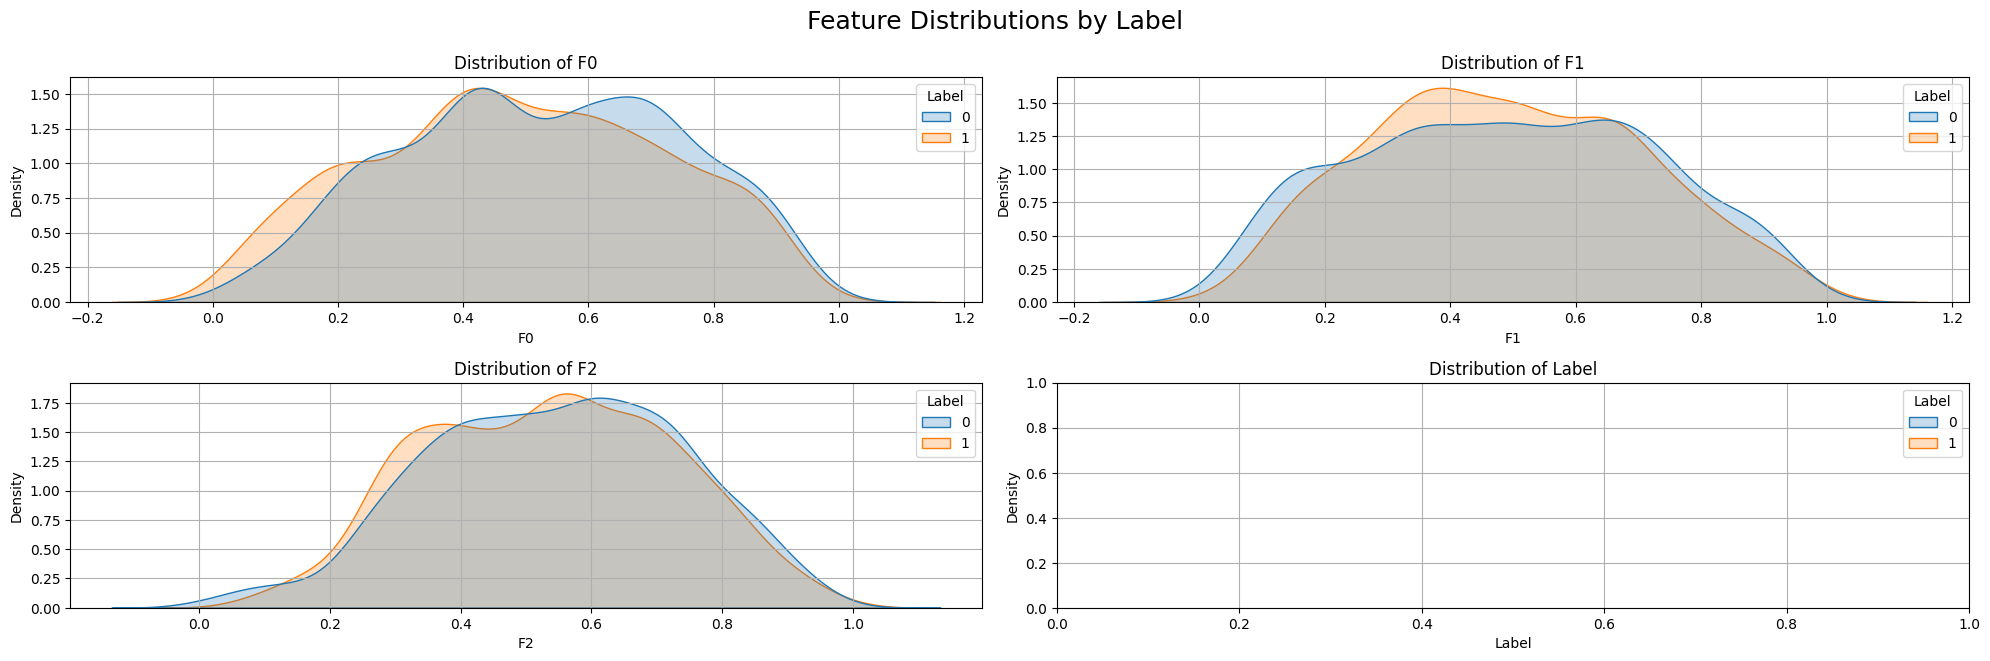

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
df_plot = df_mm
# Ensure numeric conversion
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

# Select only numeric columns
numeric_cols = df_plot.select_dtypes(include=['number'])

# Plot the first N numeric features (change N as needed)
N = 10
features_to_plot = numeric_cols.columns[:N]  # ✅ Correct way to get first N columns

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(5, 2, i)
    sns.kdeplot(data=df_plot, x=feature, hue="Label", common_norm=False, fill=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Feature Distributions by Label", fontsize=18, y=1.02)
plt.show()


# All ML model

In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "KNN": KNeighborsClassifier(),
}

def evaluate_model(y_true, y_pred):
    """
    Calculate all evaluation metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp)  # Specificity = TN / (TN + FP)
    f1 = f1_score(y_true, y_pred)
    recall = sensitivity  # Recall is the same as sensitivity
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }

def train_and_evaluate_models(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate models with SMOTE only on training data
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        
        try:
            # Create pipeline with SMOTE and model
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions
            y_pred = pipeline.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[model_name] = metrics
            
            # Print results
            print(f"{model_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results, X_test, y_test

def display_results(results):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print("MODEL COMPARISON RESULTS")
    print("="*80)
    print(results_df)
    
    # Find best model for each metric
    print("\n" + "="*80)
    print("BEST MODELS FOR EACH METRIC")
    print("="*80)
    for metric in results_df.columns:
        best_model = results_df[metric].idxmax()
        best_score = results_df[metric].max()
        print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

# Alternative approach without pipeline (more explicit control)
def train_and_evaluate_models_explicit(X, y, test_size=0.2, random_state=42):
    """
    Alternative implementation with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        
        try:
            # Fit the model on resampled data
            model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions
            y_pred = model.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[model_name] = metrics
            
            # Print results
            print(f"{model_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results, X_test, y_test

# Example usage:
if __name__ == "__main__":
    # Assuming you have your features (X) and target (y)
    # X, y = your_data, your_target
    
    # Method 1: Using Pipeline (recommended)
    print("METHOD 1: Using Pipeline")
    print("="*50)
    results, X_test, y_test = train_and_evaluate_models(embedding_custom, y)
    
    # Display results
    results_df = display_results(results)
    
    # Method 2: Explicit SMOTE application
    print("\n\nMETHOD 2: Explicit SMOTE Application")
    print("="*50)
    results_explicit, _, _ = train_and_evaluate_models_explicit(embedding_custom, y)
    results_df_explicit = display_results(results_explicit)

METHOD 1: Using Pipeline
Original training set shape: (2070, 10)
Class distribution in training set: [1250  820]
Test set shape: (518, 10)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training Random Forest...
Random Forest Results:
  Accuracy: 0.6506
  Precision: 0.5638
  Sensitivity: 0.5171
  Specificity: 0.7380
  F1 Score: 0.5394
  Recall: 0.5171
--------------------------------------------------
Training AdaBoost...
AdaBoost Results:
  Accuracy: 0.5869
  Precision: 0.4830
  Sensitivity: 0.6244
  Specificity: 0.5623
  F1 Score: 0.5447
  Recall: 0.6244
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Results:
  Accuracy: 0.6120
  Precision: 0.5097
  Sensitivity: 0.5122
  Specificity: 0.6773
  F1 Score: 0.5109
  Recall: 0.5122
--------------------------------------------------
Training XGBoost...
XGBoost Results:
  Accuracy: 0.6313
  Precision: 0.5333
  Sensi

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "KNN": KNeighborsClassifier(),
}

def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Calculate all evaluation metrics including AUC
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity = TN / (TN + FP)
    f1 = f1_score(y_true, y_pred)
    recall = sensitivity  # Recall is the same as sensitivity
    
    # Calculate AUC if probability scores are provided
    auc = None
    if y_proba is not None:
        try:
            # For binary classification
            if len(np.unique(y_true)) == 2:
                if y_proba.ndim == 2:
                    auc = roc_auc_score(y_true, y_proba[:, 1])
                else:
                    auc = roc_auc_score(y_true, y_proba)
            else:
                # For multi-class, use one-vs-rest
                auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
        except Exception as e:
            print(f"Could not calculate AUC: {e}")
            auc = None
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall,
        'AUC': auc
    }

def train_and_evaluate_models_10fold(X, y, random_state=42):
    """
    Train and evaluate models with 10-fold cross-validation using SMOTE
    """
    # Initialize 10-fold stratified cross-validation
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    print(f"Class 0: {np.sum(y == 0)}, Class 1: {np.sum(y == 1)}")
    print("=" * 80)
    
    results = {}
    all_predictions = {}
    all_probabilities = {}
    
    for model_name, model in models.items():
        print(f"\nTraining {model_name} with 10-fold CV...")
        
        try:
            # Create pipeline with SMOTE and model
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', model)
            ])
            
            # Store metrics for each fold
            fold_metrics = {
                'Accuracy': [], 'Precision': [], 'Sensitivity': [], 
                'Specificity': [], 'F1 Score': [], 'Recall': [], 'AUC': []
            }
            
            # Perform 10-fold cross-validation manually to get all metrics
            for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]
                
                # Apply SMOTE only on training fold
                smote = SMOTE(random_state=random_state)
                X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
                
                # Train model
                pipeline.fit(X_train_resampled, y_train_resampled)
                
                # Predictions
                y_pred = pipeline.predict(X_val)
                
                # Get probabilities for AUC
                if hasattr(pipeline.named_steps['classifier'], 'predict_proba'):
                    y_proba = pipeline.predict_proba(X_val)
                else:
                    y_proba = None
                
                # Calculate metrics for this fold
                metrics = evaluate_model(y_val, y_pred, y_proba)
                
                # Store metrics
                for metric_name, metric_value in metrics.items():
                    if metric_value is not None:
                        fold_metrics[metric_name].append(metric_value)
                
                print(f"  Fold {fold}: Accuracy = {metrics['Accuracy']:.4f}, AUC = {metrics['AUC']:.4f}")
            
            # Calculate mean and std for each metric
            results[model_name] = {}
            summary_stats = {}
            
            for metric_name, metric_values in fold_metrics.items():
                if metric_values:  # Only if we have values
                    results[model_name][metric_name] = {
                        'mean': np.mean(metric_values),
                        'std': np.std(metric_values),
                        'values': metric_values
                    }
                    summary_stats[metric_name] = f"{np.mean(metric_values):.4f} (±{np.std(metric_values):.4f})"
            
            # Store all predictions for the model
            all_predictions[model_name] = cross_val_predict(pipeline, X, y, cv=cv, method='predict')
            
            # Get probabilities across all folds
            if hasattr(model, 'predict_proba'):
                all_probabilities[model_name] = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')
            
            # Print summary
            print(f"\n{model_name} - 10-Fold CV Results:")
            for metric_name, summary in summary_stats.items():
                print(f"  {metric_name}: {summary}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results, all_predictions, all_probabilities

def display_results_10fold(results):
    """
    Display 10-fold CV results in a formatted table
    """
    # Create summary dataframe
    summary_data = {}
    for model_name, model_results in results.items():
        if model_results is not None:
            summary_data[model_name] = {}
            for metric_name, metric_stats in model_results.items():
                summary_data[model_name][metric_name] = f"{metric_stats['mean']:.4f} (±{metric_stats['std']:.4f})"
    
    results_df = pd.DataFrame(summary_data).T
    
    print("\n" + "="*80)
    print("10-FOLD CROSS-VALIDATION RESULTS (Mean ± Std)")
    print("="*80)
    print(results_df)
    
    # Find best model for each metric based on mean
    print("\n" + "="*80)
    print("BEST MODELS FOR EACH METRIC (based on mean score)")
    print("="*80)
    
    # Get the metrics (excluding std information)
    metrics = list(results[list(results.keys())[0]].keys()) if results else []
    
    for metric in metrics:
        best_model = None
        best_score = -np.inf
        
        for model_name, model_results in results.items():
            if model_results is not None and metric in model_results:
                score = model_results[metric]['mean']
                if score > best_score:
                    best_score = score
                    best_model = model_name
        
        if best_model:
            std_value = results[best_model][metric]['std']
            print(f"{metric}: {best_model} ({best_score:.4f} ± {std_value:.4f})")
    
    return results_df

def get_detailed_fold_results(results):
    """
    Display detailed fold-by-fold results for each model
    """
    print("\n" + "="*80)
    print("DETAILED FOLD-BY-FOLD RESULTS")
    print("="*80)
    
    for model_name, model_results in results.items():
        if model_results is not None:
            print(f"\n{model_name}:")
            print("-" * 40)
            
            # Create dataframe for this model's fold results
            fold_data = {}
            for metric_name, metric_stats in model_results.items():
                fold_data[metric_name] = metric_stats['values']
            
            fold_df = pd.DataFrame(fold_data)
            fold_df.index = [f"Fold {i+1}" for i in range(len(fold_df))]
            print(fold_df.round(4))
            print()

def train_and_evaluate_models_10fold_verbose(X, y, random_state=42):
    """
    Alternative implementation with more detailed output and confidence intervals
    """
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    print("=" * 80)
    
    results = {}
    
    for model_name, model in models.items():
        print(f"\nProcessing {model_name}...")
        
        try:
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', model)
            ])
            
            # Define scoring metrics for cross_validate
            scoring = {
                'accuracy': 'accuracy',
                'precision': 'precision',
                'recall': 'recall',
                'f1': 'f1',
                'roc_auc': 'roc_auc'
            }
            
            # Perform cross-validation with multiple metrics
            cv_results = cross_validate(
                pipeline, X, y, 
                cv=cv, 
                scoring=scoring,
                return_train_score=False,
                n_jobs=-1  # Use all available cores
            )
            
            # Store results
            results[model_name] = {}
            summary_stats = {}
            
            for metric_name in scoring.keys():
                scores = cv_results[f'test_{metric_name}']
                results[model_name][metric_name] = {
                    'mean': np.mean(scores),
                    'std': np.std(scores),
                    'values': scores,
                    '95%_ci': (np.mean(scores) - 1.96 * np.std(scores), 
                               np.mean(scores) + 1.96 * np.std(scores))
                }
                summary_stats[metric_name] = f"{np.mean(scores):.4f} (±{np.std(scores):.4f})"
            
            # Print results
            print(f"{model_name} - 10-Fold CV Results:")
            for metric_name, summary in summary_stats.items():
                ci = results[model_name][metric_name]['95%_ci']
                print(f"  {metric_name.upper()}: {summary} [95% CI: ({ci[0]:.4f}, {ci[1]:.4f})]")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results

# Example usage:
if __name__ == "__main__":
    # Assuming you have your features (embedding_custom) and target (y)
    # X = embedding_custom
    # y = target_variable
    
    # Method 1: Full 10-fold CV with all metrics including AUC
    print("METHOD 1: Detailed 10-Fold Cross-Validation with SMOTE")
    print("="*60)
    results, all_predictions, all_probabilities = train_and_evaluate_models_10fold(embedding_custom, y)
    
    # Display summary results
    results_df = display_results_10fold(results)
    
    # Display detailed fold results
    get_detailed_fold_results(results)
    
    # Method 2: Faster implementation with confidence intervals
    print("\n\nMETHOD 2: Fast 10-Fold CV with Confidence Intervals")
    print("="*60)
    results_fast = train_and_evaluate_models_10fold_verbose(embedding_custom, y)
    
    # Optional: Compare models statistically
    from scipy import stats
    
    print("\n" + "="*80)
    print("STATISTICAL COMPARISON (Paired t-tests between best model and others)")
    print("="*80)
    
    # Get predictions from the best model (assuming Random Forest for example)
    # This requires storing all predictions from the cross-validation
    # You can add this functionality if needed

METHOD 1: Detailed 10-Fold Cross-Validation with SMOTE
Dataset shape: (2588, 3)
Class distribution: [1563 1025]
Class 0: 1563, Class 1: 1025

Training Random Forest with 10-fold CV...
  Fold 1: Accuracy = 0.6602, AUC = 0.6752
  Fold 2: Accuracy = 0.6448, AUC = 0.6759
  Fold 3: Accuracy = 0.6602, AUC = 0.6881
  Fold 4: Accuracy = 0.6680, AUC = 0.6823
  Fold 5: Accuracy = 0.6332, AUC = 0.6935
  Fold 6: Accuracy = 0.5521, AUC = 0.5761
  Fold 7: Accuracy = 0.5985, AUC = 0.6048
  Fold 8: Accuracy = 0.6873, AUC = 0.7066
  Fold 9: Accuracy = 0.7248, AUC = 0.7633
  Fold 10: Accuracy = 0.6357, AUC = 0.6566

Random Forest - 10-Fold CV Results:
  Accuracy: 0.6465 (±0.0449)
  Precision: 0.5564 (±0.0599)
  Sensitivity: 0.5433 (±0.0535)
  Specificity: 0.7141 (±0.0481)
  F1 Score: 0.5493 (±0.0540)
  Recall: 0.5433 (±0.0535)
  AUC: 0.6722 (±0.0493)
--------------------------------------------------

Training AdaBoost with 10-fold CV...
  Fold 1: Accuracy = 0.5985, AUC = 0.5597
  Fold 2: Accuracy = 0.6

/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:27:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:27:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:27:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:27:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/

METHOD 1: Using Pipeline
Original training set shape: (2070, 3)
Class distribution in training set: [1250  820]
Test set shape: (518, 3)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training Random Forest...
Random Forest Results:
  Accuracy: 0.6486
  Precision: 0.5550
  Sensitivity: 0.5659
  Specificity: 0.7029
  F1 Score: 0.5604
  Recall: 0.5659
  AUC: 0.6492
--------------------------------------------------
Training AdaBoost...
AdaBoost Results:
  Accuracy: 0.5985
  Precision: 0.4800
  Sensitivity: 0.1756
  Specificity: 0.8754
  F1 Score: 0.2571
  Recall: 0.1756
  AUC: 0.5517
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Results:
  Accuracy: 0.5541
  Precision: 0.4440
  Sensitivity: 0.5024
  Specificity: 0.5879
  F1 Score: 0.4714
  Recall: 0.5024
  AUC: 0.5758
--------------------------------------------------
Training XGBoost...
XGBoost Results:
  Accu

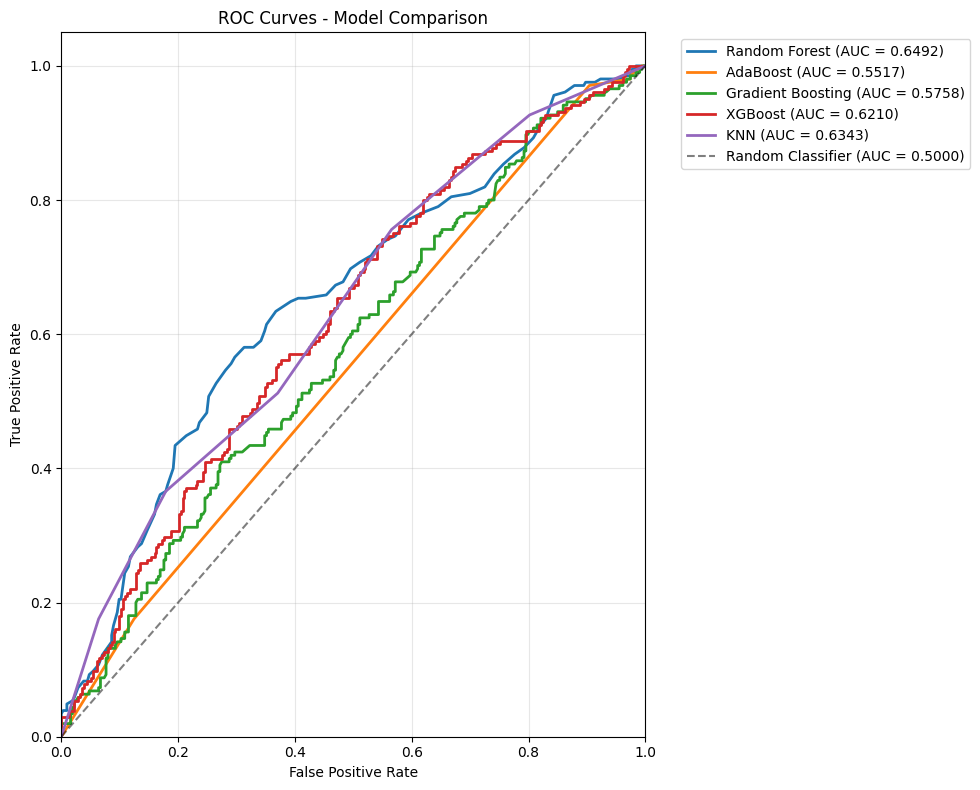


Generating Metrics Comparison...


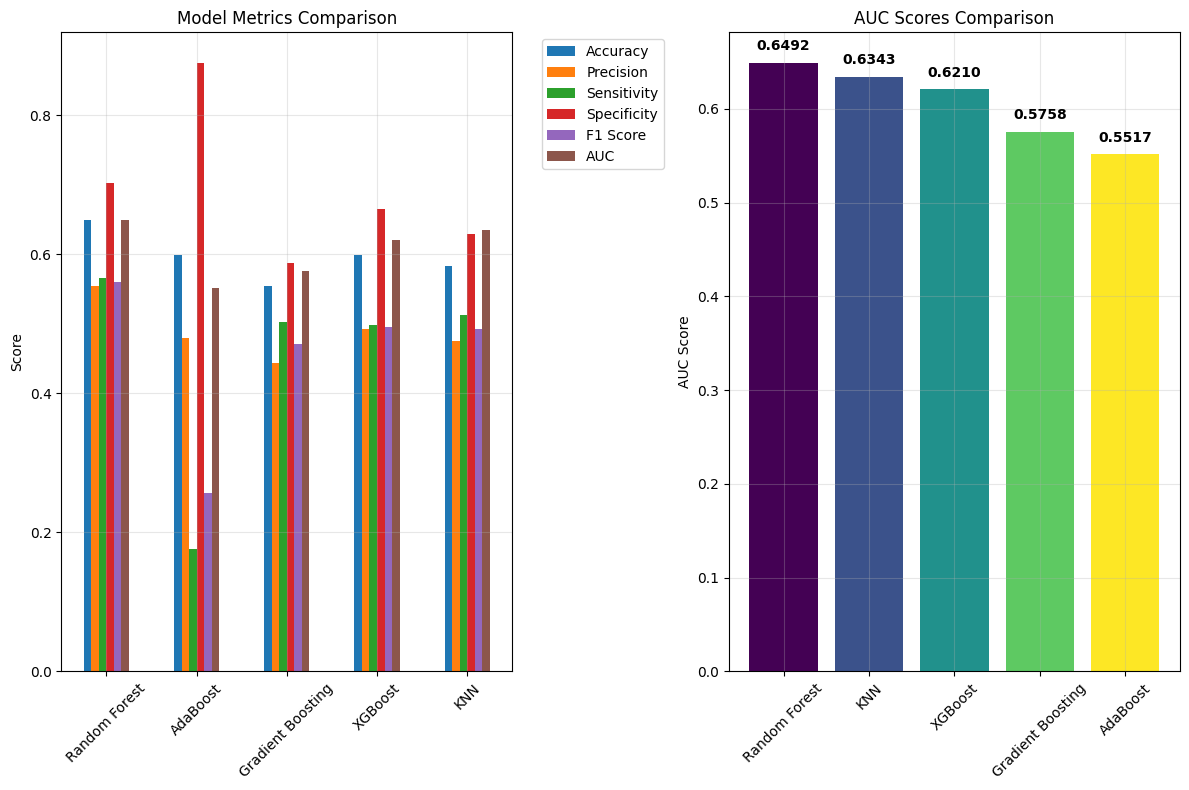


Analyzing Probability Distributions...


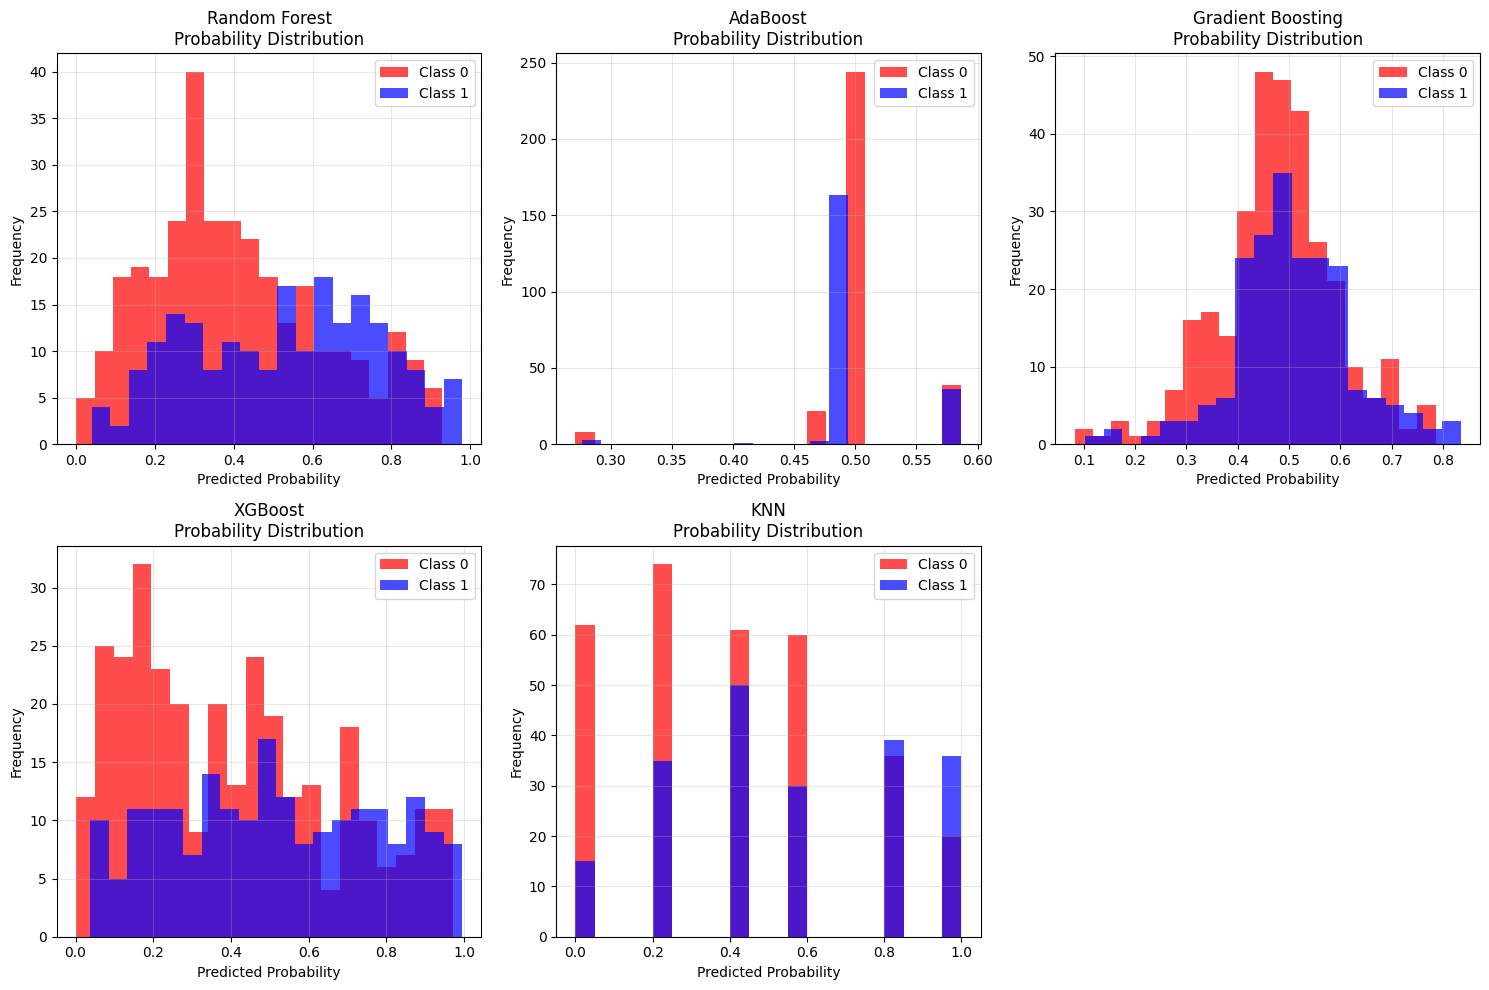



METHOD 2: Explicit SMOTE Application
Applying SMOTE only to training data...
Training set shape before SMOTE: (2070, 3)
Training set shape after SMOTE: (2500, 3)
Class distribution after SMOTE: [1250 1250]
--------------------------------------------------------------------------------
Training Random Forest...
Random Forest Results:
  Accuracy: 0.6486
  Precision: 0.5550
  Sensitivity: 0.5659
  Specificity: 0.7029
  F1 Score: 0.5604
  Recall: 0.5659
  AUC: 0.6492
--------------------------------------------------
Training AdaBoost...
AdaBoost Results:
  Accuracy: 0.5985
  Precision: 0.4800
  Sensitivity: 0.1756
  Specificity: 0.8754
  F1 Score: 0.2571
  Recall: 0.1756
  AUC: 0.5517
--------------------------------------------------
Training Gradient Boosting...
Gradient Boosting Results:
  Accuracy: 0.5541
  Precision: 0.4440
  Sensitivity: 0.5024
  Specificity: 0.5879
  F1 Score: 0.4714
  Recall: 0.5024
  AUC: 0.5758
--------------------------------------------------
Training XGBoo

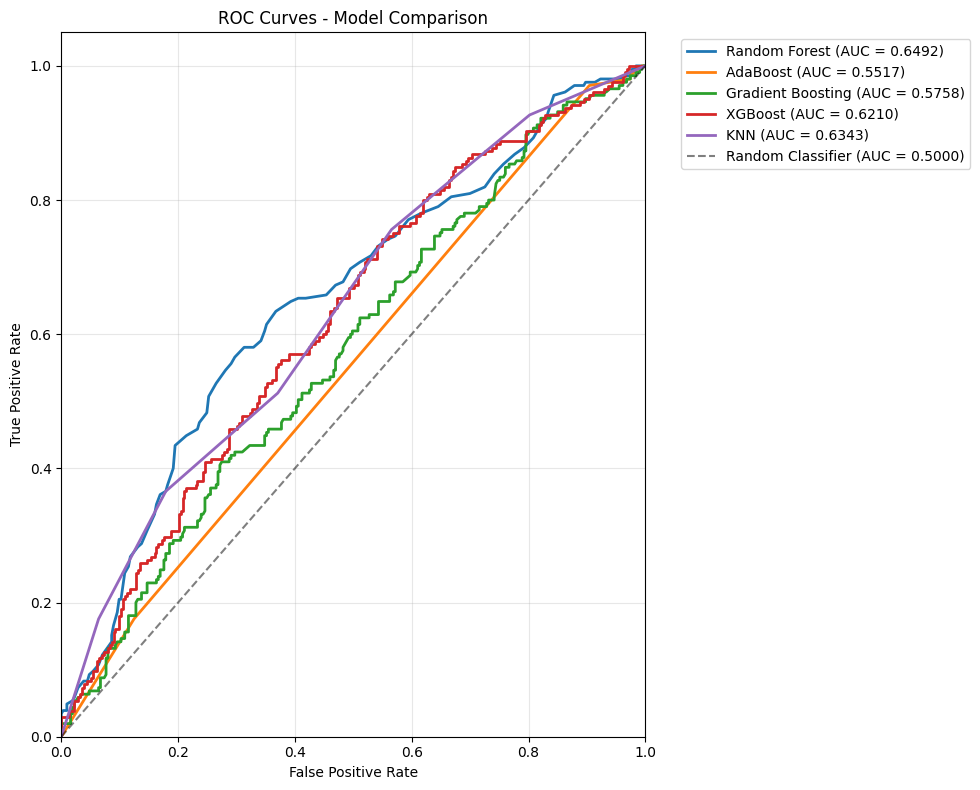


COMPARISON BETWEEN PIPELINE AND EXPLICIT METHODS
               Model  Pipeline_AUC  Explicit_AUC  Difference
0      Random Forest        0.6492        0.6492         0.0
1           AdaBoost        0.5517        0.5517         0.0
2  Gradient Boosting        0.5758        0.5758         0.0
3            XGBoost        0.6210        0.6210         0.0
4                KNN        0.6343        0.6343         0.0


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "KNN": KNeighborsClassifier(),
}

def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Calculate all evaluation metrics including AUC
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = sensitivity  # Recall is the same as sensitivity
    
    # Calculate AUC if probabilities are provided
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    
    results = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }
    
    if auc is not None:
        results['AUC'] = auc
    
    return results

def train_and_evaluate_models(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate models with SMOTE only on training data
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    all_predictions = {}
    all_probabilities = {}
    
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        
        try:
            # Create pipeline with SMOTE and model
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions and probabilities
            y_pred = pipeline.predict(X_test)
            y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[model_name] = metrics
            all_predictions[model_name] = y_pred
            all_probabilities[model_name] = y_proba
            
            # Print results
            print(f"{model_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results, X_test, y_test, all_predictions, all_probabilities

def plot_roc_curves(y_test, probabilities_dict, figsize=(10, 8)):
    """
    Plot ROC curves for all models
    """
    plt.figure(figsize=figsize)
    
    # Plot ROC curve for each model
    for model_name, y_proba in probabilities_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.5000)')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Model Comparison')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(results_df, figsize=(12, 8)):
    """
    Plot comparison of all metrics including AUC
    """
    metrics_to_plot = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']
    available_metrics = [metric for metric in metrics_to_plot if metric in results_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot for metrics
    results_df[available_metrics].plot(kind='bar', ax=axes[0], rot=45)
    axes[0].set_title('Model Metrics Comparison')
    axes[0].set_ylabel('Score')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # AUC-focused comparison
    if 'AUC' in results_df.columns:
        auc_sorted = results_df.sort_values('AUC', ascending=False)
        colors = plt.cm.viridis(np.linspace(0, 1, len(auc_sorted)))
        bars = axes[1].bar(range(len(auc_sorted)), auc_sorted['AUC'], color=colors)
        axes[1].set_title('AUC Scores Comparison')
        axes[1].set_ylabel('AUC Score')
        axes[1].set_xticks(range(len(auc_sorted)))
        axes[1].set_xticklabels(auc_sorted.index, rotation=45)
        axes[1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, auc_sorted['AUC']):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def display_results(results):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print("MODEL COMPARISON RESULTS")
    print("="*80)
    print(results_df)
    
    # Find best model for each metric
    print("\n" + "="*80)
    print("BEST MODELS FOR EACH METRIC")
    print("="*80)
    for metric in results_df.columns:
        if results_df[metric].notna().any():
            best_model = results_df[metric].idxmax()
            best_score = results_df[metric].max()
            print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

# Alternative approach without pipeline (more explicit control)
def train_and_evaluate_models_explicit(X, y, test_size=0.2, random_state=42):
    """
    Alternative implementation with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    all_predictions = {}
    all_probabilities = {}
    
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        
        try:
            # Fit the model on resampled data
            model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions and probabilities
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[model_name] = metrics
            all_predictions[model_name] = y_pred
            all_probabilities[model_name] = y_proba
            
            # Print results
            print(f"{model_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = None
    
    return results, X_test, y_test, all_predictions, all_probabilities

# Additional function to get detailed probability analysis
def analyze_probability_distributions(probabilities_dict, y_test, figsize=(15, 10)):
    """
    Analyze probability distributions for each model
    """
    n_models = len(probabilities_dict)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    
    for idx, (model_name, y_proba) in enumerate(probabilities_dict.items()):
        if idx < len(axes):
            # Separate probabilities by true class
            proba_class_0 = y_proba[y_test == 0]
            proba_class_1 = y_proba[y_test == 1]
            
            # Plot histogram
            axes[idx].hist(proba_class_0, alpha=0.7, label='Class 0', bins=20, color='red')
            axes[idx].hist(proba_class_1, alpha=0.7, label='Class 1', bins=20, color='blue')
            axes[idx].set_title(f'{model_name}\nProbability Distribution')
            axes[idx].set_xlabel('Predicted Probability')
            axes[idx].set_ylabel('Frequency')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Assuming you have your features (X) and target (y)
    # X, y = your_data, your_target
    
    # Method 1: Using Pipeline (recommended)
    print("METHOD 1: Using Pipeline")
    print("="*50)
    results, X_test, y_test, predictions, probabilities = train_and_evaluate_models(embedding_custom, y)
    
    # Display results
    results_df = display_results(results)
    
    # Plot ROC curves
    print("\nGenerating ROC Curves...")
    plot_roc_curves(y_test, probabilities)
    
    # Plot metrics comparison
    print("\nGenerating Metrics Comparison...")
    plot_metrics_comparison(results_df)
    
    # Analyze probability distributions
    print("\nAnalyzing Probability Distributions...")
    analyze_probability_distributions(probabilities, y_test)
    
    # Method 2: Explicit SMOTE application
    print("\n\nMETHOD 2: Explicit SMOTE Application")
    print("="*50)
    results_explicit, X_test_explicit, y_test_explicit, predictions_explicit, probabilities_explicit = train_and_evaluate_models_explicit(embedding_custom, y)
    
    # Display results
    results_df_explicit = display_results(results_explicit)
    
    # Plot ROC curves for explicit method
    print("\nGenerating ROC Curves for Explicit Method...")
    plot_roc_curves(y_test_explicit, probabilities_explicit)
    
    # Compare both methods
    print("\n" + "="*80)
    print("COMPARISON BETWEEN PIPELINE AND EXPLICIT METHODS")
    print("="*80)
    
    comparison_data = []
    for model_name in models.keys():
        if model_name in results and model_name in results_explicit:
            pipeline_auc = results[model_name].get('AUC', None)
            explicit_auc = results_explicit[model_name].get('AUC', None)
            comparison_data.append({
                'Model': model_name,
                'Pipeline_AUC': pipeline_auc,
                'Explicit_AUC': explicit_auc,
                'Difference': pipeline_auc - explicit_auc if pipeline_auc and explicit_auc else None
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.round(4))

# SVM

🚀 SVM MODEL EVALUATION WITH SMOTE

METHOD 1: SVM with Pipeline
Original training set shape: (2070, 10)
Class distribution in training set: [1250  820]
Test set shape: (518, 10)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training SVM RBF...
SVM RBF Results:
  Accuracy: 0.5290
  Precision: 0.4170
  Sensitivity: 0.4780
  Specificity: 0.5623
  F1 Score: 0.4455
  Recall: 0.4780
--------------------------------------------------

SVM RESULTS - Pipeline Method
         Accuracy  Precision  Sensitivity  Specificity  F1 Score  Recall
SVM RBF     0.529      0.417        0.478       0.5623    0.4455   0.478

BEST SVM MODELS - Pipeline Method
Accuracy: SVM RBF (0.5290)
Precision: SVM RBF (0.4170)
Sensitivity: SVM RBF (0.4780)
Specificity: SVM RBF (0.5623)
F1 Score: SVM RBF (0.4455)
Recall: SVM RBF (0.4780)

METHOD 2: SVM with Explicit SMOTE
Applying SMOTE only to training data...
Training set shape before SMOTE: (2070,

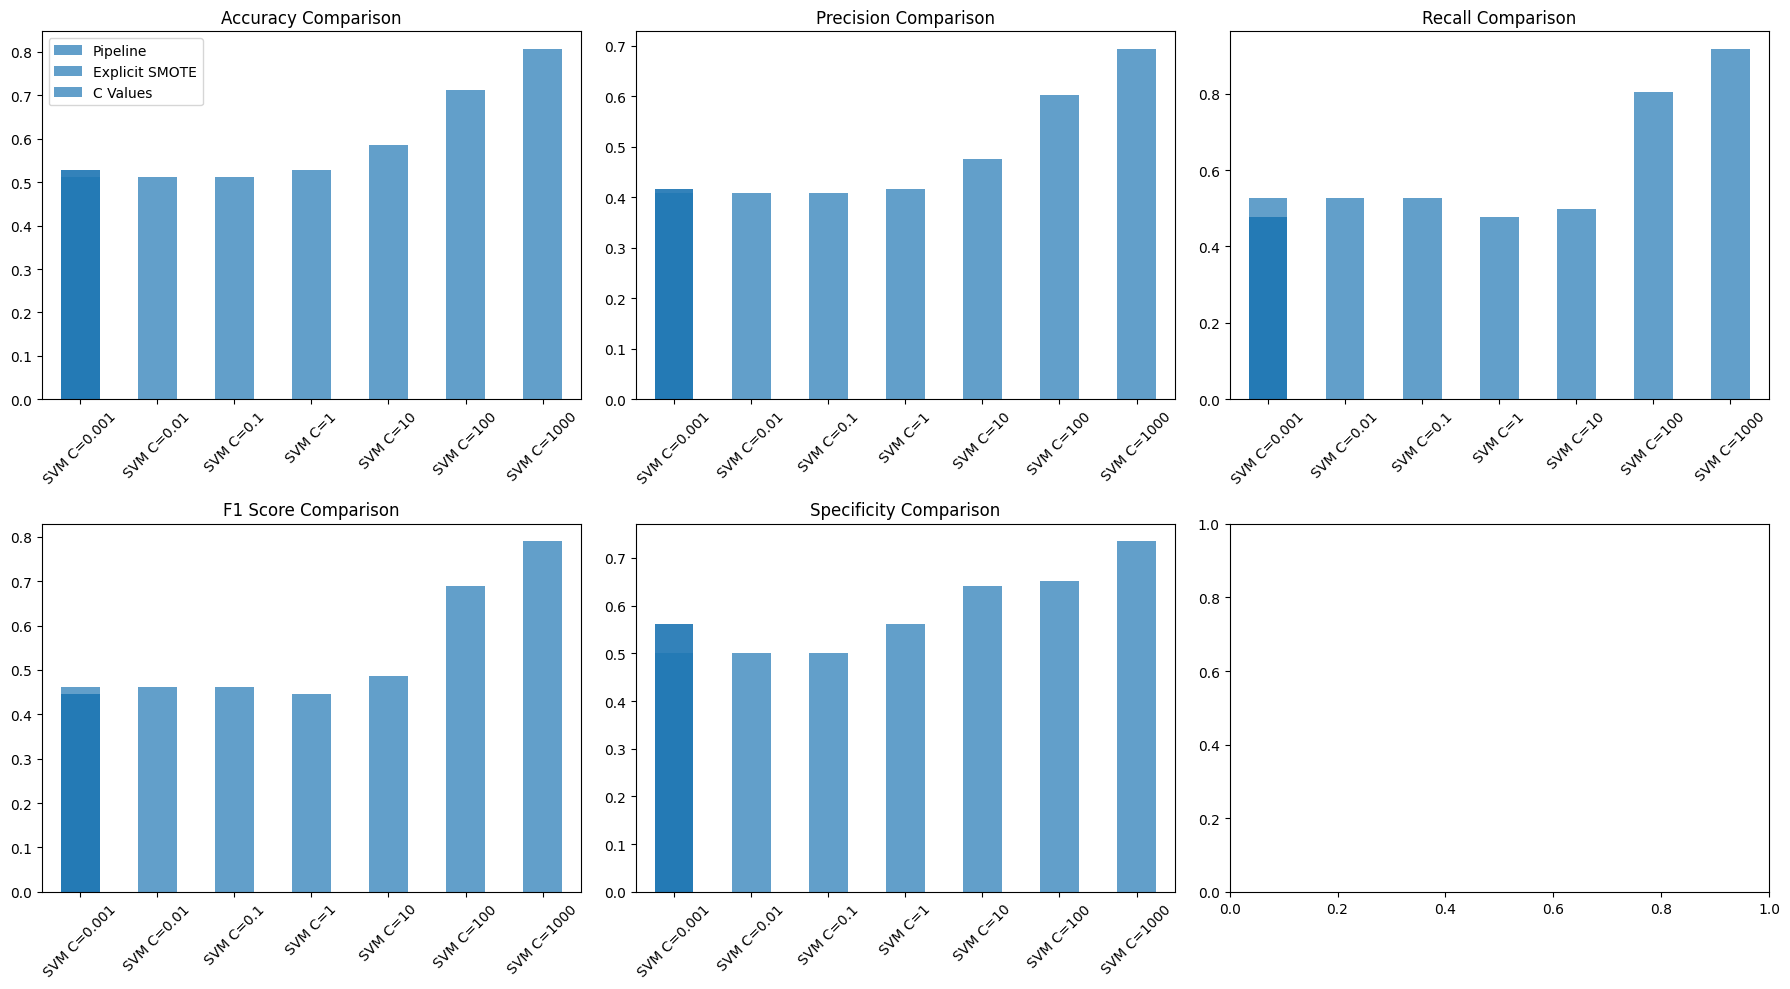


Results saved to 'svm_pipeline_results.csv' and 'svm_explicit_results.csv'


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Initialize SVM models with different kernels
svm_models = {
    # "SVM Linear": SVC(kernel='linear', random_state=42, probability=True),
    "SVM RBF": SVC(kernel='rbf', random_state=42, probability=True),
    # "SVM Poly": SVC(kernel='poly', degree=3, random_state=42, probability=True),
    # "SVM Sigmoid": SVC(kernel='sigmoid', random_state=42, probability=True),
    # "SVM Default": SVC(random_state=42, probability=True)
}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

def evaluate_model(y_true, y_pred):
    """
    Calculate all evaluation metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = sensitivity  # Recall is the same as sensitivity
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }

def train_and_evaluate_svm_pipeline(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate SVM models with SMOTE using Pipeline
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    
    for svm_name, svm_model in svm_models.items():
        print(f"Training {svm_name}...")
        
        try:
            # Create pipeline with SMOTE and SVM
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', svm_model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions
            y_pred = pipeline.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[svm_name] = metrics
            
            # Print results
            print(f"{svm_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {svm_name}: {e}")
            results[svm_name] = None
    
    return results, X_test, y_test

def train_and_evaluate_svm_explicit(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate SVM models with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    
    for svm_name, svm_model in svm_models.items():
        print(f"Training {svm_name}...")
        
        try:
            # Fit the SVM model on resampled data
            svm_model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions
            y_pred = svm_model.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[svm_name] = metrics
            
            # Print results
            print(f"{svm_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {svm_name}: {e}")
            results[svm_name] = None
    
    return results, X_test, y_test

def display_results(results, method_name=""):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print(f"SVM RESULTS - {method_name}")
    print("="*80)
    print(results_df)
    
    # Find best SVM for each metric
    print("\n" + "="*80)
    print(f"BEST SVM MODELS - {method_name}")
    print("="*80)
    for metric in results_df.columns:
        if results_df[metric].notna().any():
            best_model = results_df[metric].idxmax()
            best_score = results_df[metric].max()
            print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

# SVM with hyperparameter tuning
def train_svm_with_hyperparameter_tuning(X, y, test_size=0.2, random_state=42):
    """
    Train SVM with GridSearchCV for hyperparameter optimization
    """
    from sklearn.model_selection import GridSearchCV
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE to training data
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # Define parameter grid for SVM
    param_grid = {
        'C': [100],
        'kernel': ['rbf'],
        'gamma': [0.01],
        'degree': [3]  # for poly kernel
    }
    
    print("Performing Grid Search for SVM...")
    svm = SVC(random_state=random_state, probability=True)
    grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Train with best parameters
    best_svm = grid_search.best_estimator_
    y_pred = best_svm.predict(X_test)
    metrics = evaluate_model(y_test, y_pred)
    
    print("\nTuned SVM Results:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    
    return metrics, best_svm, grid_search.best_params_

# SVM with different C values
def train_svm_with_different_c(X, y, test_size=0.2, random_state=42):
    """
    Train SVM with different C values to see the effect on performance
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    results = {}
    
    for c in c_values:
        print(f"Training SVM with C={c}...")
        
        try:
            # Train SVM with specific C value
            svm_model = SVC(C=c, kernel='rbf', random_state=random_state, probability=True)
            svm_model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions
            y_pred = svm_model.predict(X_test)
            
            # Evaluate
            metrics = evaluate_model(y_test, y_pred)
            results[f"SVM C={c}"] = metrics
            
            print(f"SVM C={c} Results:")
            print(f"  Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1 Score']:.4f}")
            
        except Exception as e:
            print(f"Error training SVM with C={c}: {e}")
    
    return results

# Plot SVM results
def plot_svm_results(results_dict, titles):
    """
    Plot comparison of different SVM configurations
    """
    import matplotlib.pyplot as plt
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    
    for i, metric in enumerate(metrics):
        for j, (results, title) in enumerate(zip(results_dict, titles)):
            if results is not None:
                df = pd.DataFrame(results).T
                if metric in df.columns:
                    df[metric].plot(kind='bar', ax=axes[i], alpha=0.7, 
                                   label=title if i == 0 else "")
                    axes[i].set_title(f'{metric} Comparison')
                    axes[i].tick_params(axis='x', rotation=45)
        if i == 0:
            axes[i].legend()
    
    plt.tight_layout()
    plt.show()

# Main execution function
def main():
    """
    Main function to run all SVM experiments
    """
    print("🚀 SVM MODEL EVALUATION WITH SMOTE")
    print("="*50)
    
    # Method 1: Using Pipeline
    print("\nMETHOD 1: SVM with Pipeline")
    print("="*30)
    results_pipeline, X_test, y_test = train_and_evaluate_svm_pipeline(embedding_custom, y)
    results_df_pipeline = display_results(results_pipeline, "Pipeline Method")
    
    # Method 2: Explicit SMOTE
    print("\nMETHOD 2: SVM with Explicit SMOTE")
    print("="*30)
    results_explicit, _, _ = train_and_evaluate_svm_explicit(embedding_custom, y)
    results_df_explicit = display_results(results_explicit, "Explicit SMOTE")
    
    # Method 3: Hyperparameter Tuning
    print("\nMETHOD 3: SVM with Hyperparameter Tuning")
    print("="*30)
    try:
        tuned_metrics, best_model, best_params = train_svm_with_hyperparameter_tuning(embedding_custom, y)
        print(f"\nBest Parameters: {best_params}")
    except Exception as e:
        print(f"Hyperparameter tuning failed: {e}")
        tuned_metrics, best_model, best_params = None, None, None
    
    # Method 4: Different C values
    print("\nMETHOD 4: SVM with Different C Values")
    print("="*30)
    results_c = train_svm_with_different_c(embedding_custom, y)
    display_results(results_c, "Different C Values")
    
    # Compare all results
    all_results = [results_pipeline, results_explicit, results_c]
    method_names = ['Pipeline', 'Explicit SMOTE', 'C Values']
    
    # Plot results
    try:
        plot_svm_results(all_results, method_names)
    except:
        print("Plotting failed, but results are available above")
    
    return {
        'results_pipeline': results_pipeline,
        'results_explicit': results_explicit,
        'tuned_metrics': tuned_metrics,
        'best_model': best_model,
        'best_params': best_params,
        'results_c': results_c
    }

# Run the main function
if __name__ == "__main__":
    # Run all SVM experiments
    svm_results = main()
    
    # Save results to CSV
    results_df_pipeline = pd.DataFrame(svm_results['results_pipeline']).T
    results_df_explicit = pd.DataFrame(svm_results['results_explicit']).T
    
    results_df_pipeline.to_csv('svm_pipeline_results.csv')
    results_df_explicit.to_csv('svm_explicit_results.csv')
    
    print("\nResults saved to 'svm_pipeline_results.csv' and 'svm_explicit_results.csv'")

🚀 SVM MODEL EVALUATION WITH SMOTE AND AUC

METHOD 1: SVM with Pipeline
Original training set shape: (2070, 3)
Class distribution in training set: [1250  820]
Test set shape: (518, 3)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training SVM RBF...
SVM RBF Results:
  Accuracy: 0.5927
  Precision: 0.4867
  Sensitivity: 0.5366
  Specificity: 0.6294
  F1 Score: 0.5104
  Recall: 0.5366
  AUC: 0.5978
--------------------------------------------------

SVM RESULTS
         Accuracy  Precision  Sensitivity  Specificity  F1 Score  Recall  \
SVM RBF    0.5927     0.4867       0.5366       0.6294    0.5104  0.5366   

            AUC  
SVM RBF  0.5978  

BEST SVM MODELS FOR EACH METRIC
Accuracy: SVM RBF (0.5927)
Precision: SVM RBF (0.4867)
Sensitivity: SVM RBF (0.5366)
Specificity: SVM RBF (0.6294)
F1 Score: SVM RBF (0.5104)
Recall: SVM RBF (0.5366)
AUC: SVM RBF (0.5978)

Generating ROC Curves for Pipeline Method...


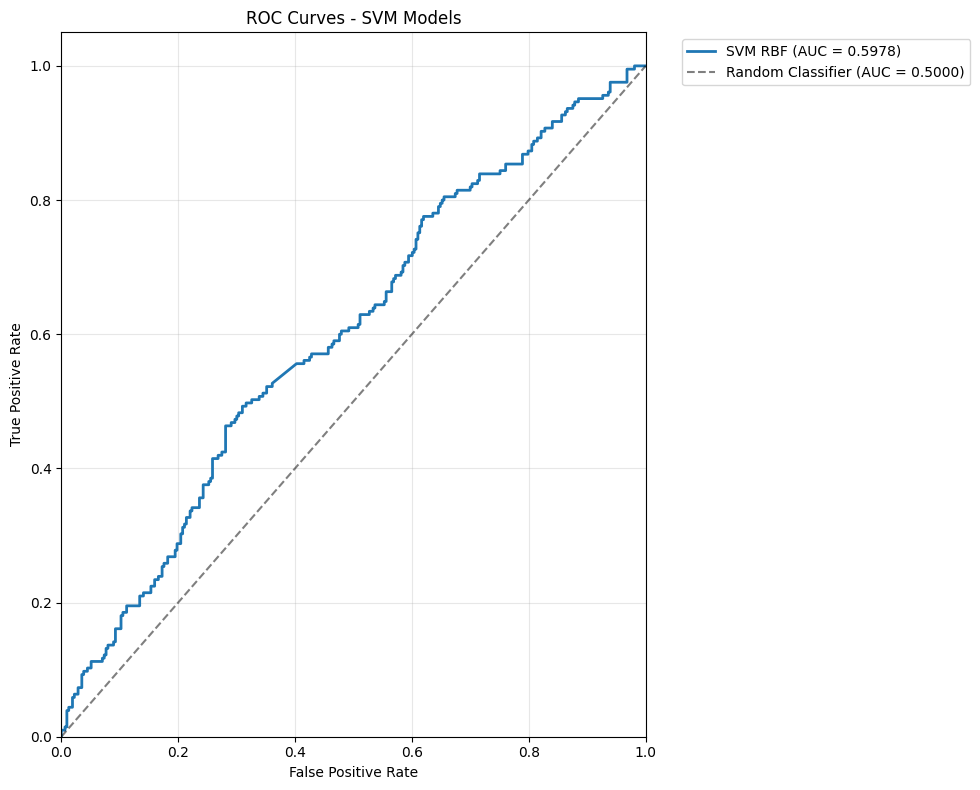


Generating Metrics Comparison for Pipeline Method...


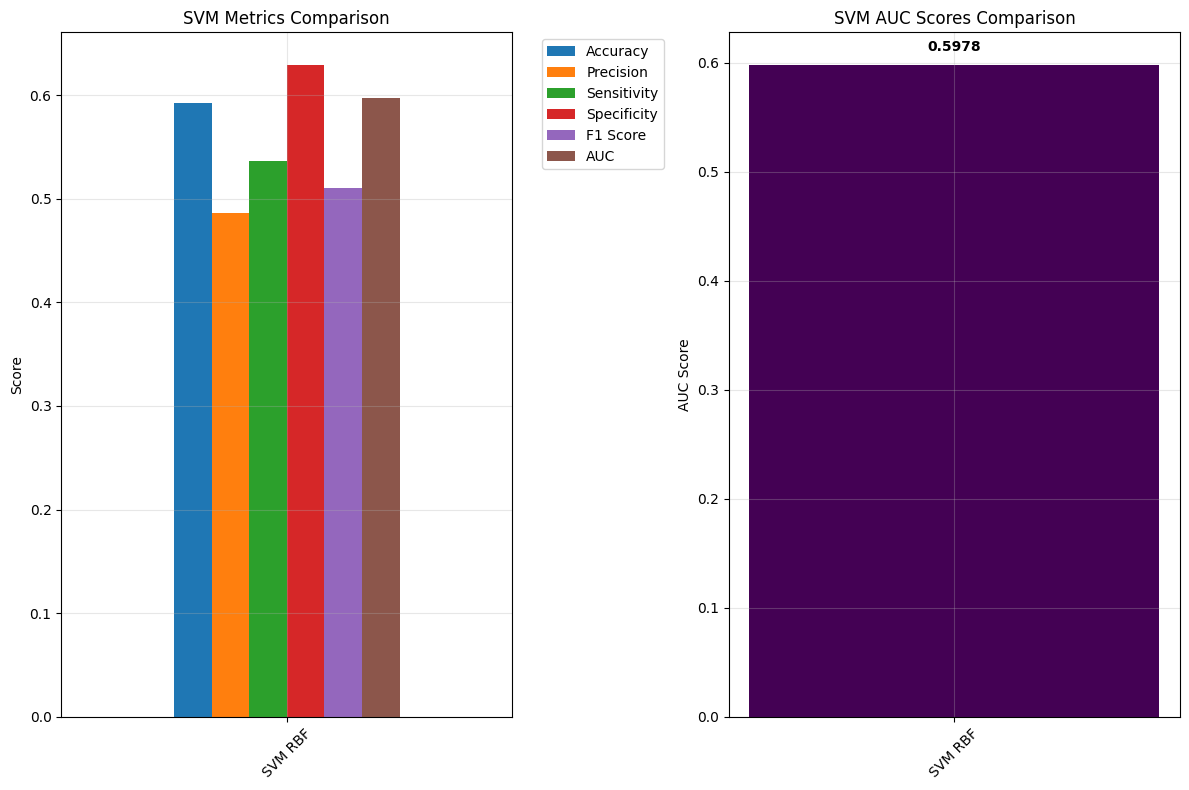


METHOD 2: SVM with Explicit SMOTE
Applying SMOTE only to training data...
Training set shape before SMOTE: (2070, 3)
Training set shape after SMOTE: (2500, 3)
Class distribution after SMOTE: [1250 1250]
--------------------------------------------------------------------------------
Training SVM RBF...
SVM RBF Results:
  Accuracy: 0.5927
  Precision: 0.4867
  Sensitivity: 0.5366
  Specificity: 0.6294
  F1 Score: 0.5104
  Recall: 0.5366
  AUC: 0.5978
--------------------------------------------------

SVM RESULTS
         Accuracy  Precision  Sensitivity  Specificity  F1 Score  Recall  \
SVM RBF    0.5927     0.4867       0.5366       0.6294    0.5104  0.5366   

            AUC  
SVM RBF  0.5978  

BEST SVM MODELS FOR EACH METRIC
Accuracy: SVM RBF (0.5927)
Precision: SVM RBF (0.4867)
Sensitivity: SVM RBF (0.5366)
Specificity: SVM RBF (0.6294)
F1 Score: SVM RBF (0.5104)
Recall: SVM RBF (0.5366)
AUC: SVM RBF (0.5978)

Generating ROC Curves for Explicit Method...


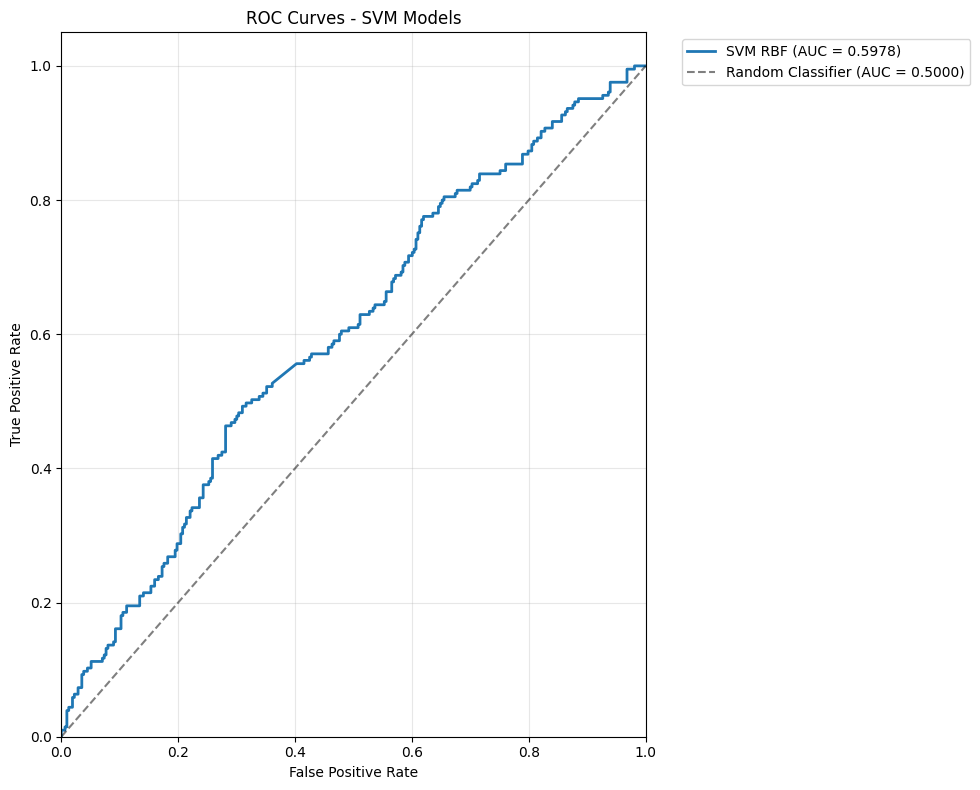


Generating Metrics Comparison for Explicit Method...


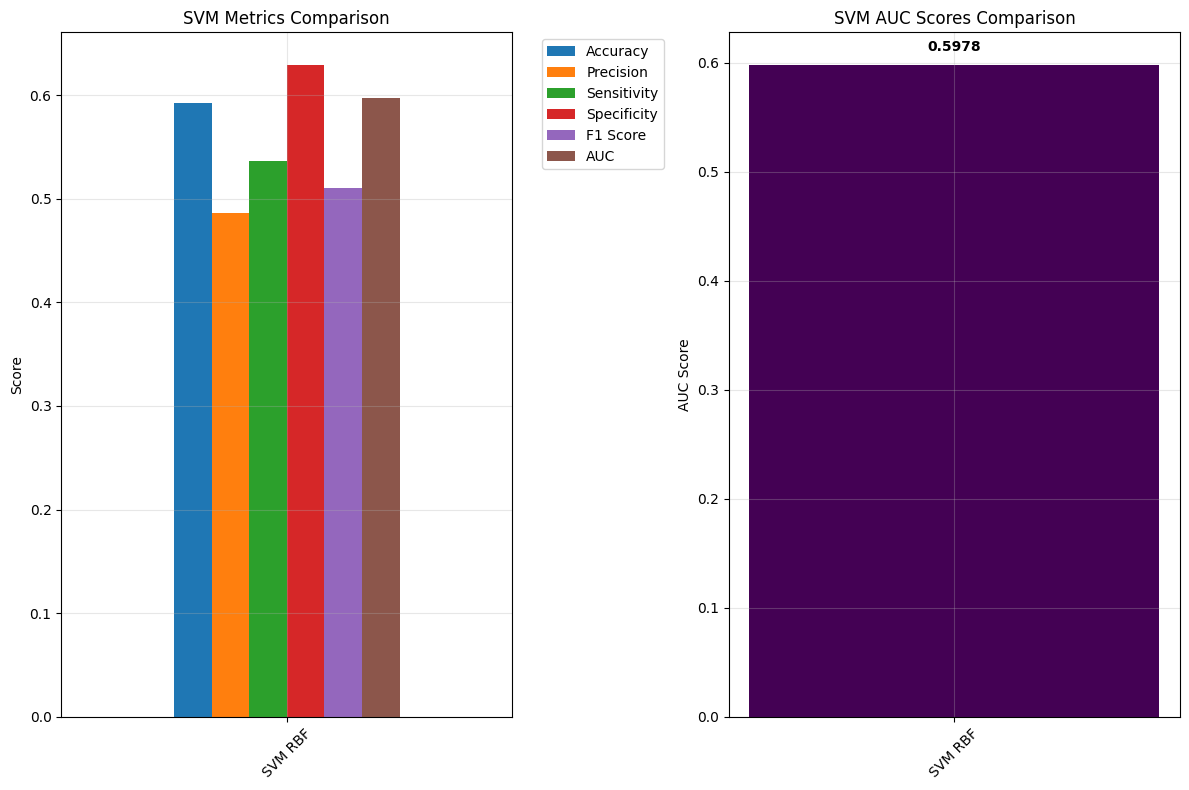


METHOD 3: SVM with Hyperparameter Tuning
Performing Grid Search for SVM...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 100, 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 0.6109

Tuned SVM Results:
  Accuracy: 0.6004
  Precision: 0.4961
  Sensitivity: 0.6146
  Specificity: 0.5911
  F1 Score: 0.5490
  Recall: 0.6146
  AUC: 0.6083

Best Parameters: {'C': 100, 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf'}

SVM RESULTS
           Accuracy  Precision  Sensitivity  Specificity  F1 Score  Recall  \
SVM Tuned    0.6004     0.4961       0.6146       0.5911     0.549  0.6146   

              AUC  
SVM Tuned  0.6083  

BEST SVM MODELS FOR EACH METRIC
Accuracy: SVM Tuned (0.6004)
Precision: SVM Tuned (0.4961)
Sensitivity: SVM Tuned (0.6146)
Specificity: SVM Tuned (0.5911)
F1 Score: SVM Tuned (0.5490)
Recall: SVM Tuned (0.6146)
AUC: SVM Tuned (0.6083)


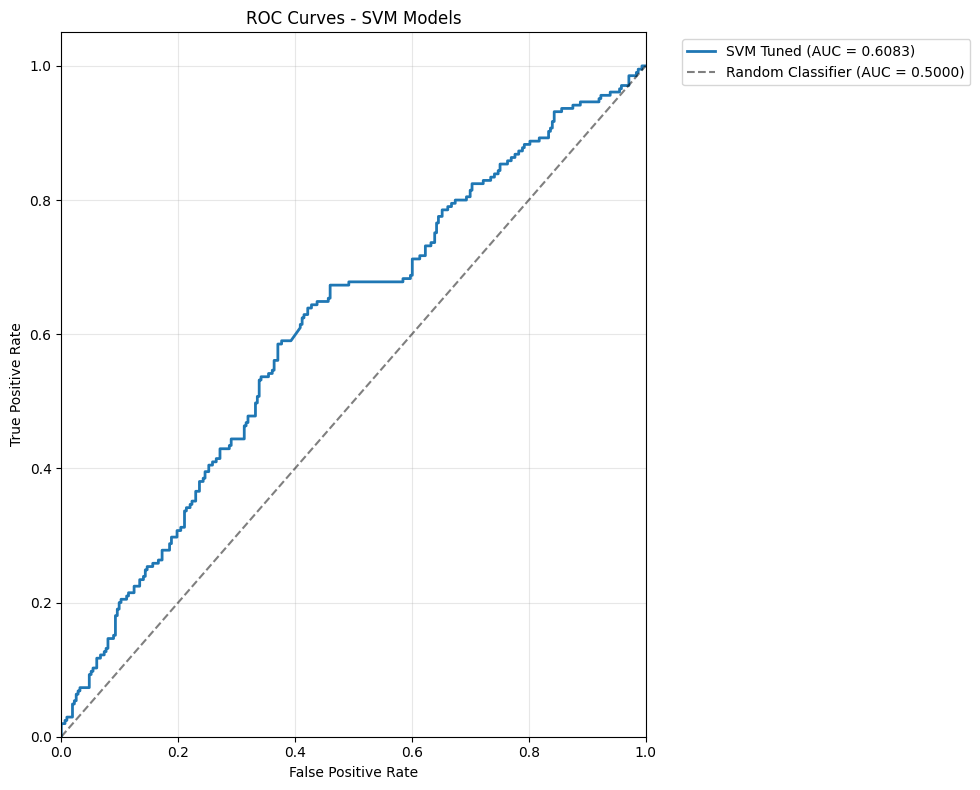


METHOD 4: SVM with Different C Values
Training SVM with C=0.001...
SVM C=0.001 Results:
  Accuracy: 0.5541, F1: 0.3671, AUC: 0.5
Training SVM with C=0.01...
SVM C=0.01 Results:
  Accuracy: 0.5541, F1: 0.3671, AUC: 0.5023766851087041
Training SVM with C=0.1...
SVM C=0.1 Results:
  Accuracy: 0.5753, F1: 0.4787, AUC: 0.5809085950284423
Training SVM with C=1...
SVM C=1 Results:
  Accuracy: 0.5927, F1: 0.5104, AUC: 0.5978492947868776
Training SVM with C=10...
SVM C=10 Results:
  Accuracy: 0.5869, F1: 0.5158, AUC: 0.6114392581625498
Training SVM with C=100...
SVM C=100 Results:
  Accuracy: 0.5734, F1: 0.5206, AUC: 0.6014805579365697
Training SVM with C=1000...
SVM C=1000 Results:
  Accuracy: 0.5714, F1: 0.5088, AUC: 0.5976311073014884

SVM RESULTS
             Accuracy  Precision  Sensitivity  Specificity  F1 Score  Recall  \
SVM C=0.001    0.5541     0.4188       0.3268       0.7029    0.3671  0.3268   
SVM C=0.01     0.5541     0.4188       0.3268       0.7029    0.3671  0.3268   
SVM C=0

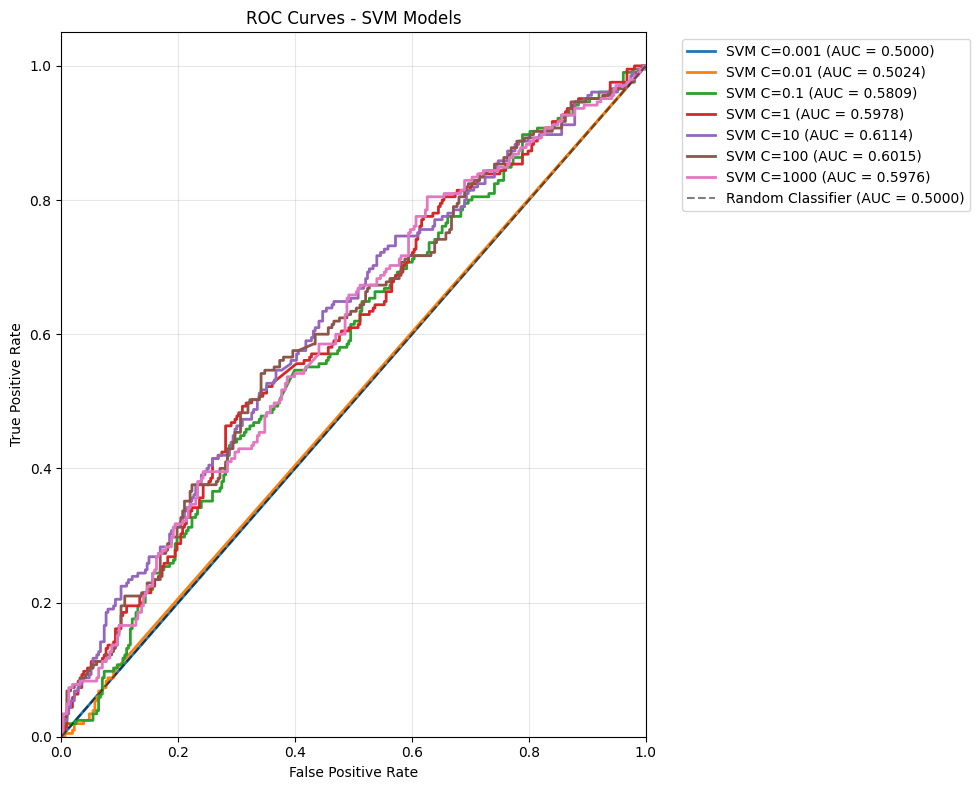


Generating Metrics Comparison for C Values...


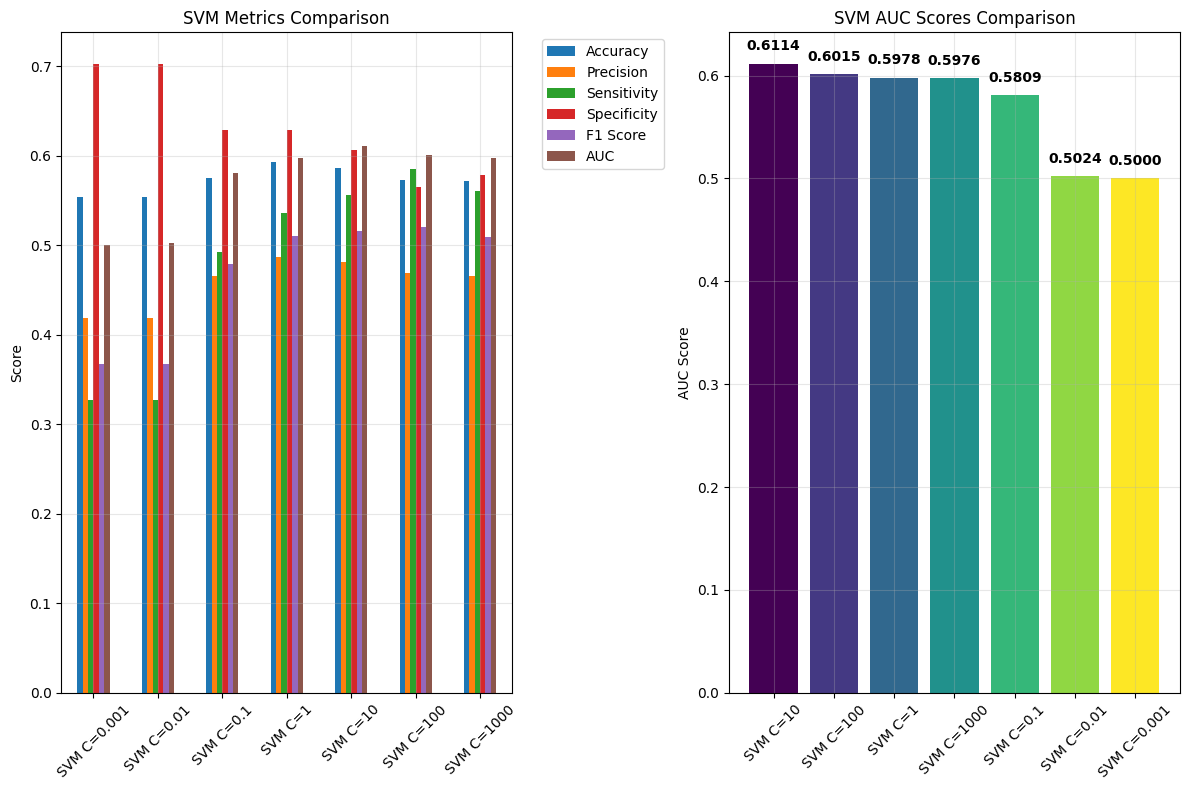


Analyzing Probability Distributions...


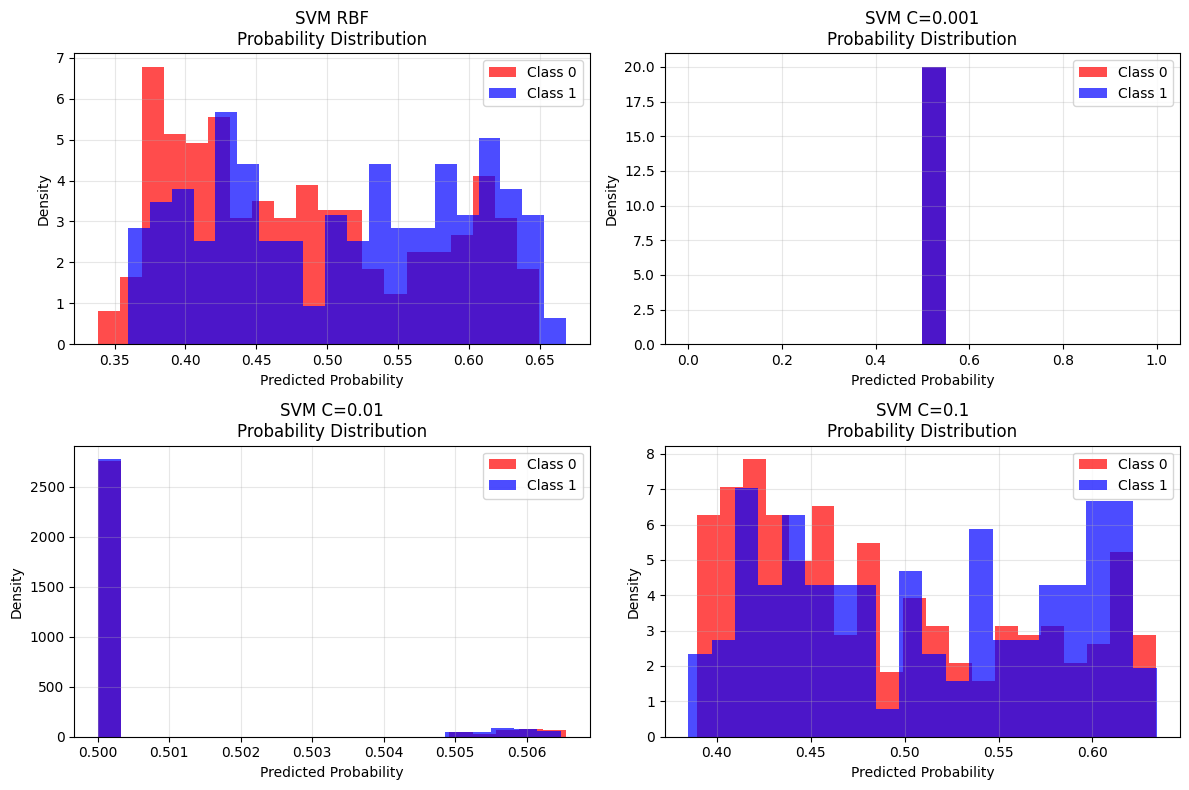


COMPREHENSIVE SVM RESULTS COMPARISON
     Method        Model  Accuracy  Precision  Sensitivity  Specificity  \
0  Pipeline      SVM RBF    0.5927     0.4867       0.5366       0.6294   
1  Explicit      SVM RBF    0.5927     0.4867       0.5366       0.6294   
2  C_Values  SVM C=0.001    0.5541     0.4188       0.3268       0.7029   
3  C_Values   SVM C=0.01    0.5541     0.4188       0.3268       0.7029   
4  C_Values    SVM C=0.1    0.5753     0.4654       0.4927       0.6294   
5  C_Values      SVM C=1    0.5927     0.4867       0.5366       0.6294   
6  C_Values     SVM C=10    0.5869     0.4810       0.5561       0.6070   
7  C_Values    SVM C=100    0.5734     0.4688       0.5854       0.5655   
8  C_Values   SVM C=1000    0.5714     0.4656       0.5610       0.5783   

   F1_Score     AUC  
0    0.5104  0.5978  
1    0.5104  0.5978  
2    0.3671  0.5000  
3    0.3671  0.5024  
4    0.4787  0.5809  
5    0.5104  0.5978  
6    0.5158  0.6114  
7    0.5206  0.6015  
8    0.5088  

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Initialize SVM models with different kernels
svm_models = {
    # "SVM Linear": SVC(kernel='linear', random_state=42, probability=True),
    "SVM RBF": SVC(kernel='rbf', random_state=42, probability=True),
    # "SVM Poly": SVC(kernel='poly', degree=3, random_state=42, probability=True),
    # "SVM Sigmoid": SVC(kernel='sigmoid', random_state=42, probability=True),
    # "SVM Default": SVC(random_state=42, probability=True)
}

def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Calculate all evaluation metrics including AUC
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = sensitivity  # Recall is the same as sensitivity
    
    # Calculate AUC if probabilities are provided
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    
    results = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }
    
    if auc is not None:
        results['AUC'] = auc
    
    return results

def train_and_evaluate_svm_pipeline(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate SVM models with SMOTE using Pipeline
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    all_probabilities = {}
    
    for svm_name, svm_model in svm_models.items():
        print(f"Training {svm_name}...")
        
        try:
            # Create pipeline with SMOTE and SVM
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', svm_model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions and probabilities
            y_pred = pipeline.predict(X_test)
            y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[svm_name] = metrics
            all_probabilities[svm_name] = y_proba
            
            # Print results
            print(f"{svm_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {svm_name}: {e}")
            results[svm_name] = None
    
    return results, X_test, y_test, all_probabilities

def train_and_evaluate_svm_explicit(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate SVM models with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    all_probabilities = {}
    
    for svm_name, svm_model in svm_models.items():
        print(f"Training {svm_name}...")
        
        try:
            # Fit the SVM model on resampled data
            svm_model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions and probabilities
            y_pred = svm_model.predict(X_test)
            y_proba = svm_model.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[svm_name] = metrics
            all_probabilities[svm_name] = y_proba
            
            # Print results
            print(f"{svm_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {svm_name}: {e}")
            results[svm_name] = None
    
    return results, X_test, y_test, all_probabilities

def plot_roc_curves(y_test, probabilities_dict, figsize=(10, 8)):
    """
    Plot ROC curves for all models
    """
    plt.figure(figsize=figsize)
    
    # Plot ROC curve for each model
    for model_name, y_proba in probabilities_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.5000)')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - SVM Models')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(results_df, figsize=(12, 8)):
    """
    Plot comparison of all metrics including AUC
    """
    metrics_to_plot = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']
    available_metrics = [metric for metric in metrics_to_plot if metric in results_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot for metrics
    results_df[available_metrics].plot(kind='bar', ax=axes[0], rot=45)
    axes[0].set_title('SVM Metrics Comparison')
    axes[0].set_ylabel('Score')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # AUC-focused comparison
    if 'AUC' in results_df.columns:
        auc_sorted = results_df.sort_values('AUC', ascending=False)
        colors = plt.cm.viridis(np.linspace(0, 1, len(auc_sorted)))
        bars = axes[1].bar(range(len(auc_sorted)), auc_sorted['AUC'], color=colors)
        axes[1].set_title('SVM AUC Scores Comparison')
        axes[1].set_ylabel('AUC Score')
        axes[1].set_xticks(range(len(auc_sorted)))
        axes[1].set_xticklabels(auc_sorted.index, rotation=45)
        axes[1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, auc_sorted['AUC']):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def display_results(results):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print("SVM RESULTS")
    print("="*80)
    print(results_df)
    
    # Find best model for each metric
    print("\n" + "="*80)
    print("BEST SVM MODELS FOR EACH METRIC")
    print("="*80)
    for metric in results_df.columns:
        if results_df[metric].notna().any():
            best_model = results_df[metric].idxmax()
            best_score = results_df[metric].max()
            print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

# SVM with hyperparameter tuning
def train_svm_with_hyperparameter_tuning(X, y, test_size=0.2, random_state=42):
    """
    Train SVM with GridSearchCV for hyperparameter optimization
    """
    from sklearn.model_selection import GridSearchCV
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE to training data
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # Define parameter grid for SVM
    param_grid = {
        'C': [100],
        'kernel': ['rbf'],
        'gamma': [0.01],
        'degree': [3]  # for poly kernel
    }
    
    print("Performing Grid Search for SVM...")
    svm = SVC(random_state=random_state, probability=True)
    grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Train with best parameters
    best_svm = grid_search.best_estimator_
    y_pred = best_svm.predict(X_test)
    y_proba = best_svm.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(y_test, y_pred, y_proba)
    
    print("\nTuned SVM Results:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    
    return metrics, best_svm, grid_search.best_params_, y_proba

# SVM with different C values
def train_svm_with_different_c(X, y, test_size=0.2, random_state=42):
    """
    Train SVM with different C values to see the effect on performance
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    results = {}
    probabilities_dict = {}
    
    for c in c_values:
        print(f"Training SVM with C={c}...")
        
        try:
            # Train SVM with specific C value
            svm_model = SVC(C=c, kernel='rbf', random_state=random_state, probability=True)
            svm_model.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions and probabilities
            y_pred = svm_model.predict(X_test)
            y_proba = svm_model.predict_proba(X_test)[:, 1]
            
            # Evaluate
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[f"SVM C={c}"] = metrics
            probabilities_dict[f"SVM C={c}"] = y_proba
            
            print(f"SVM C={c} Results:")
            print(f"  Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1 Score']:.4f}, AUC: {metrics.get('AUC', 'N/A')}")
            
        except Exception as e:
            print(f"Error training SVM with C={c}: {e}")
    
    return results, probabilities_dict

def plot_probability_distributions(probabilities_dict, y_test, figsize=(12, 8)):
    """
    Plot probability distributions for SVM models
    """
    n_models = len(probabilities_dict)
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()
    
    for idx, (model_name, y_proba) in enumerate(probabilities_dict.items()):
        if idx < len(axes):
            # Separate probabilities by true class
            proba_class_0 = y_proba[y_test == 0]
            proba_class_1 = y_proba[y_test == 1]
            
            # Plot histogram
            axes[idx].hist(proba_class_0, alpha=0.7, label='Class 0', bins=20, color='red', density=True)
            axes[idx].hist(proba_class_1, alpha=0.7, label='Class 1', bins=20, color='blue', density=True)
            axes[idx].set_title(f'{model_name}\nProbability Distribution')
            axes[idx].set_xlabel('Predicted Probability')
            axes[idx].set_ylabel('Density')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Main execution function
def main():
    """
    Main function to run all SVM experiments
    """
    print("🚀 SVM MODEL EVALUATION WITH SMOTE AND AUC")
    print("="*50)
    
    # Method 1: Using Pipeline
    print("\nMETHOD 1: SVM with Pipeline")
    print("="*30)
    results_pipeline, X_test, y_test, probabilities_pipeline = train_and_evaluate_svm_pipeline(embedding_custom, y)
    results_df_pipeline = display_results(results_pipeline)
    
    # Plot ROC curves for pipeline method
    print("\nGenerating ROC Curves for Pipeline Method...")
    plot_roc_curves(y_test, probabilities_pipeline)
    
    # Plot metrics comparison for pipeline method
    print("\nGenerating Metrics Comparison for Pipeline Method...")
    plot_metrics_comparison(results_df_pipeline)
    
    # Method 2: Explicit SMOTE
    print("\nMETHOD 2: SVM with Explicit SMOTE")
    print("="*30)
    results_explicit, X_test_explicit, y_test_explicit, probabilities_explicit = train_and_evaluate_svm_explicit(embedding_custom, y)
    results_df_explicit = display_results(results_explicit)
    
    # Plot ROC curves for explicit method
    print("\nGenerating ROC Curves for Explicit Method...")
    plot_roc_curves(y_test_explicit, probabilities_explicit)
    
    # Plot metrics comparison for explicit method
    print("\nGenerating Metrics Comparison for Explicit Method...")
    plot_metrics_comparison(results_df_explicit)
    
    # Method 3: Hyperparameter Tuning
    print("\nMETHOD 3: SVM with Hyperparameter Tuning")
    print("="*30)
    try:
        tuned_metrics, best_model, best_params, tuned_proba = train_svm_with_hyperparameter_tuning(embedding_custom, y)
        print(f"\nBest Parameters: {best_params}")
        
        # Add tuned model to results for comparison
        results_tuned = {"SVM Tuned": tuned_metrics}
        probabilities_tuned = {"SVM Tuned": tuned_proba}
        
        # Display tuned results
        display_results(results_tuned)
        
        # Plot ROC for tuned model
        plot_roc_curves(y_test, probabilities_tuned)
        
    except Exception as e:
        print(f"Hyperparameter tuning failed: {e}")
        tuned_metrics, best_model, best_params = None, None, None
        results_tuned = {}
    
    # Method 4: Different C values
    print("\nMETHOD 4: SVM with Different C Values")
    print("="*30)
    results_c, probabilities_c = train_svm_with_different_c(embedding_custom, y)
    results_df_c = display_results(results_c)
    
    # Plot ROC curves for different C values
    print("\nGenerating ROC Curves for Different C Values...")
    plot_roc_curves(y_test, probabilities_c)
    
    # Plot metrics comparison for C values
    print("\nGenerating Metrics Comparison for C Values...")
    plot_metrics_comparison(results_df_c)
    
    # Plot probability distributions
    print("\nAnalyzing Probability Distributions...")
    # Combine probabilities from different methods for analysis
    all_probabilities = {**probabilities_pipeline, **probabilities_explicit, **probabilities_c}
    plot_probability_distributions(all_probabilities, y_test)
    
    # Compare all results
    print("\n" + "="*80)
    print("COMPREHENSIVE SVM RESULTS COMPARISON")
    print("="*80)
    
    # Create comprehensive comparison
    comparison_data = []
    for method_name, results in [("Pipeline", results_pipeline), 
                                ("Explicit", results_explicit),
                                ("C_Values", results_c)]:
        for model_name, metrics in results.items():
            comparison_data.append({
                'Method': method_name,
                'Model': model_name,
                'Accuracy': metrics['Accuracy'],
                'Precision': metrics['Precision'],
                'Sensitivity': metrics['Sensitivity'],
                'Specificity': metrics['Specificity'],
                'F1_Score': metrics['F1 Score'],
                'AUC': metrics.get('AUC', None)
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.round(4))
    
    return {
        'results_pipeline': results_pipeline,
        'results_explicit': results_explicit,
        'results_c': results_c,
        'results_tuned': results_tuned,
        'probabilities_pipeline': probabilities_pipeline,
        'probabilities_explicit': probabilities_explicit,
        'probabilities_c': probabilities_c,
        'tuned_metrics': tuned_metrics,
        'best_model': best_model,
        'best_params': best_params
    }

# Run the main function
if __name__ == "__main__":
    # Run all SVM experiments
    svm_results = main()
    
    # Save results to CSV
    results_df_pipeline = pd.DataFrame(svm_results['results_pipeline']).T
    results_df_explicit = pd.DataFrame(svm_results['results_explicit']).T
    results_df_c = pd.DataFrame(svm_results['results_c']).T
    
    results_df_pipeline.to_csv('svm_pipeline_results.csv')
    results_df_explicit.to_csv('svm_explicit_results.csv')
    results_df_c.to_csv('svm_c_values_results.csv')
    
    print("\nResults saved to CSV files:")
    print("- svm_pipeline_results.csv")
    print("- svm_explicit_results.csv") 
    print("- svm_c_values_results.csv")

# MLP

🚀 MLP CLASSIFIER EVALUATION WITH SMOTE
Main Model: MLP with hidden_layer_sizes=(256, 128, 64, 32)
Activation: relu, Solver: adam, Max Iterations: 500

METHOD 1: MLP with Pipeline
Original training set shape: (2070, 10)
Class distribution in training set: [1250  820]
Test set shape: (518, 10)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training MLP (256, 128, 64, 32)...
MLP (256, 128, 64, 32) Results:
  Accuracy: 0.5000
  Precision: 0.4372
  Sensitivity: 0.9171
  Specificity: 0.2268
  F1 Score: 0.5921
  Recall: 0.9171
  Iterations: 99
  Loss: 0.6803
--------------------------------------------------
Training MLP (256, 128, 64)...
MLP (256, 128, 64) Results:
  Accuracy: 0.5695
  Precision: 0.4366
  Sensitivity: 0.3024
  Specificity: 0.7444
  F1 Score: 0.3573
  Recall: 0.3024
  Iterations: 39
  Loss: 0.6851
--------------------------------------------------
Training MLP (128, 64, 32)...
MLP (128, 64, 32) Result

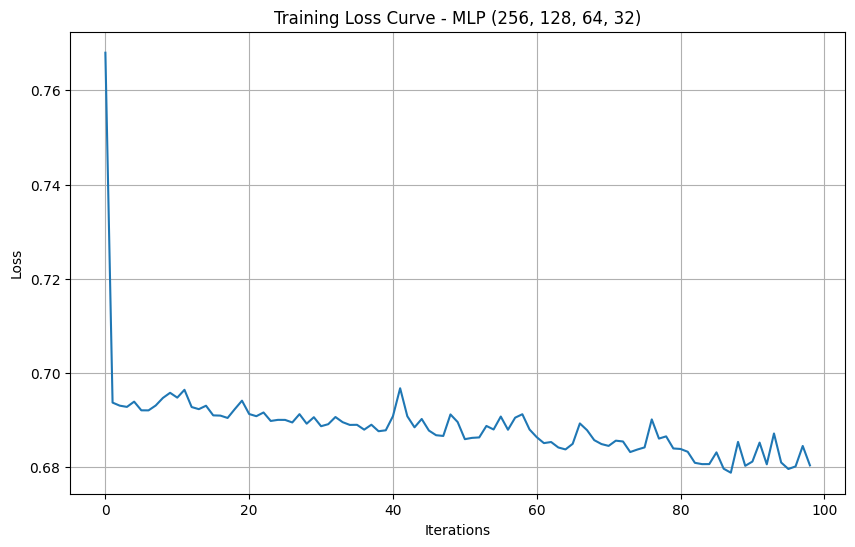

Final loss: 0.6803
Total iterations: 99

Results saved to CSV files:
- mlp_pipeline_results.csv
- mlp_explicit_results.csv
- mlp_architecture_results.csv


In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Initialize MLP models with different hidden layer configurations
mlp_models = {
    "MLP (256, 128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (256, 128, 64)": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (256, 128)": MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (128, 64)": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
}

# Additional MLP configurations for comparison
additional_mlp_models = {
    "MLP Single (256)": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP Single (128)": MLPClassifier(
        hidden_layer_sizes=(128,),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP Deep (512, 256, 128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
}

def evaluate_model(y_true, y_pred):
    """
    Calculate all evaluation metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = sensitivity  # Recall is the same as sensitivity
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }

def train_and_evaluate_mlp_pipeline(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate MLP models with SMOTE using Pipeline
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    trained_models = {}
    
    for mlp_name, mlp_model in mlp_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create pipeline with SMOTE and MLP
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', mlp_model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions
            y_pred = pipeline.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[mlp_name] = metrics
            trained_models[mlp_name] = pipeline
            
            # Print results
            print(f"{mlp_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            
            # Print training convergence info
            final_mlp = pipeline.named_steps['classifier']
            print(f"  Iterations: {final_mlp.n_iter_}")
            print(f"  Loss: {final_mlp.loss_:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
            results[mlp_name] = None
    
    return results, trained_models, X_test, y_test

def train_and_evaluate_mlp_explicit(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate MLP models with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    trained_models = {}
    
    for mlp_name, mlp_model in mlp_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create a fresh instance of the MLP model
            current_mlp = MLPClassifier(
                hidden_layer_sizes=mlp_model.hidden_layer_sizes,
                activation=mlp_model.activation,
                solver=mlp_model.solver,
                max_iter=mlp_model.max_iter,
                random_state=random_state
            )
            
            # Fit the MLP model on resampled data
            current_mlp.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions
            y_pred = current_mlp.predict(X_test)
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred)
            results[mlp_name] = metrics
            trained_models[mlp_name] = current_mlp
            
            # Print results
            print(f"{mlp_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            
            # Print training convergence info
            print(f"  Iterations: {current_mlp.n_iter_}")
            print(f"  Loss: {current_mlp.loss_:.4f}")
            print(f"  Final loss: {current_mlp.best_loss_:.4f}" if hasattr(current_mlp, 'best_loss_') else "  Best loss: N/A")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
            results[mlp_name] = None
    
    return results, trained_models, X_test, y_test

def train_mlp_with_different_architectures(X, y, test_size=0.2, random_state=42):
    """
    Train MLP with various architectures including the main one and additional ones
    """
    # Combine all models
    all_models = {**mlp_models, **additional_mlp_models}
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    results = {}
    trained_models = {}
    
    for mlp_name, mlp_model in all_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create a fresh instance
            current_mlp = MLPClassifier(
                hidden_layer_sizes=mlp_model.hidden_layer_sizes,
                activation=mlp_model.activation,
                solver=mlp_model.solver,
                max_iter=mlp_model.max_iter,
                random_state=random_state
            )
            
            current_mlp.fit(X_train_resampled, y_train_resampled)
            y_pred = current_mlp.predict(X_test)
            metrics = evaluate_model(y_test, y_pred)
            results[mlp_name] = metrics
            trained_models[mlp_name] = current_mlp
            
            print(f"{mlp_name} Results:")
            print(f"  Architecture: {current_mlp.hidden_layer_sizes}")
            print(f"  Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1 Score']:.4f}")
            print(f"  Iterations: {current_mlp.n_iter_}, Loss: {current_mlp.loss_:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
    
    return results, trained_models

def display_results(results, method_name=""):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print(f"MLP RESULTS - {method_name}")
    print("="*80)
    print(results_df)
    
    # Find best MLP for each metric
    print("\n" + "="*80)
    print(f"BEST MLP MODELS - {method_name}")
    print("="*80)
    for metric in results_df.columns:
        if results_df[metric].notna().any():
            best_model = results_df[metric].idxmax()
            best_score = results_df[metric].max()
            print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

def plot_mlp_training_loss(mlp_model, model_name):
    """
    Plot training loss curve for MLP model
    """
    import matplotlib.pyplot as plt
    
    if hasattr(mlp_model, 'loss_curve_'):
        plt.figure(figsize=(10, 6))
        plt.plot(mlp_model.loss_curve_)
        plt.title(f'Training Loss Curve - {model_name}')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()
        
        print(f"Final loss: {mlp_model.loss_curve_[-1]:.4f}")
        print(f"Total iterations: {len(mlp_model.loss_curve_)}")
    else:
        print("No loss curve available for this model")

def get_mlp_architecture_info(mlp_model):
    """
    Get detailed information about MLP architecture
    """
    info = {
        'hidden_layers': mlp_model.hidden_layer_sizes,
        'activation': mlp_model.activation,
        'solver': mlp_model.solver,
        'iterations': mlp_model.n_iter_,
        'final_loss': mlp_model.loss_,
        'layers': [mlp_model.n_features_in_] + list(mlp_model.hidden_layer_sizes) + [mlp_model.n_outputs_]
    }
    
    print(f"Architecture: {info['layers']}")
    print(f"Total layers: {len(info['layers'])}")
    print(f"Total parameters: Input({mlp_model.n_features_in_}) -> Hidden{mlp_model.hidden_layer_sizes} -> Output({mlp_model.n_outputs_})")
    print(f"Activation: {mlp_model.activation}, Solver: {mlp_model.solver}")
    print(f"Training iterations: {mlp_model.n_iter_}, Final loss: {mlp_model.loss_:.4f}")
    
    return info

# Main execution function
def main():
    """
    Main function to run all MLP experiments
    """
    print("🚀 MLP CLASSIFIER EVALUATION WITH SMOTE")
    print("="*50)
    print("Main Model: MLP with hidden_layer_sizes=(256, 128, 64, 32)")
    print("Activation: relu, Solver: adam, Max Iterations: 500")
    print("="*50)
    
    # Method 1: Using Pipeline
    print("\nMETHOD 1: MLP with Pipeline")
    print("="*30)
    results_pipeline, models_pipeline, X_test, y_test = train_and_evaluate_mlp_pipeline(embedding_custom, y)
    results_df_pipeline = display_results(results_pipeline, "Pipeline Method")
    
    # Method 2: Explicit SMOTE
    print("\nMETHOD 2: MLP with Explicit SMOTE")
    print("="*30)
    results_explicit, models_explicit, _, _ = train_and_evaluate_mlp_explicit(embedding_custom, y)
    results_df_explicit = display_results(results_explicit, "Explicit SMOTE")
    
    # Method 3: Compare different architectures
    print("\nMETHOD 3: MLP Architecture Comparison")
    print("="*30)
    results_arch, models_arch = train_mlp_with_different_architectures(embedding_custom, y)
    results_df_arch = display_results(results_arch, "Architecture Comparison")
    
    # Display detailed info for the main model
    print("\n" + "="*80)
    print("DETAILED INFO FOR MAIN MODEL: MLP (256, 128, 64, 32)")
    print("="*80)
    
    main_model_key = "MLP (256, 128, 64, 32)"
    if main_model_key in models_explicit:
        main_model = models_explicit[main_model_key]
        architecture_info = get_mlp_architecture_info(main_model)
        
        # Plot training loss if available
        plot_mlp_training_loss(main_model, main_model_key)
    
    return {
        'results_pipeline': results_pipeline,
        'results_explicit': results_explicit,
        'results_arch': results_arch,
        'models_pipeline': models_pipeline,
        'models_explicit': models_explicit,
        'models_arch': models_arch
    }

# Run the main function
if __name__ == "__main__":
    # Run all MLP experiments
    mlp_results = main()
    
    # Save results to CSV
    results_df_pipeline = pd.DataFrame(mlp_results['results_pipeline']).T
    results_df_explicit = pd.DataFrame(mlp_results['results_explicit']).T
    results_df_arch = pd.DataFrame(mlp_results['results_arch']).T
    
    results_df_pipeline.to_csv('mlp_pipeline_results.csv')
    results_df_explicit.to_csv('mlp_explicit_results.csv')
    results_df_arch.to_csv('mlp_architecture_results.csv')
    
    print("\nResults saved to CSV files:")
    print("- mlp_pipeline_results.csv")
    print("- mlp_explicit_results.csv") 
    print("- mlp_architecture_results.csv")

# MLP with AUC

🚀 MLP CLASSIFIER EVALUATION WITH SMOTE AND AUC
Main Model: MLP with hidden_layer_sizes=(256, 128, 64, 32)
Activation: relu, Solver: adam, Max Iterations: 500

METHOD 1: MLP with Pipeline
Original training set shape: (2070, 3)
Class distribution in training set: [1250  820]
Test set shape: (518, 3)
Class distribution in test set: [313 205]
--------------------------------------------------------------------------------
Training MLP (256, 128, 64, 32)...
MLP (256, 128, 64, 32) Results:
  Accuracy: 0.6139
  Precision: 0.5118
  Sensitivity: 0.5268
  Specificity: 0.6709
  F1 Score: 0.5192
  Recall: 0.5268
  AUC: 0.6286
  Iterations: 224
  Loss: 0.4403
--------------------------------------------------
Training MLP (256, 128, 64)...
MLP (256, 128, 64) Results:
  Accuracy: 0.6062
  Precision: 0.5022
  Sensitivity: 0.5659
  Specificity: 0.6326
  F1 Score: 0.5321
  Recall: 0.5659
  AUC: 0.6375
  Iterations: 267
  Loss: 0.4647
--------------------------------------------------
Training MLP (128,

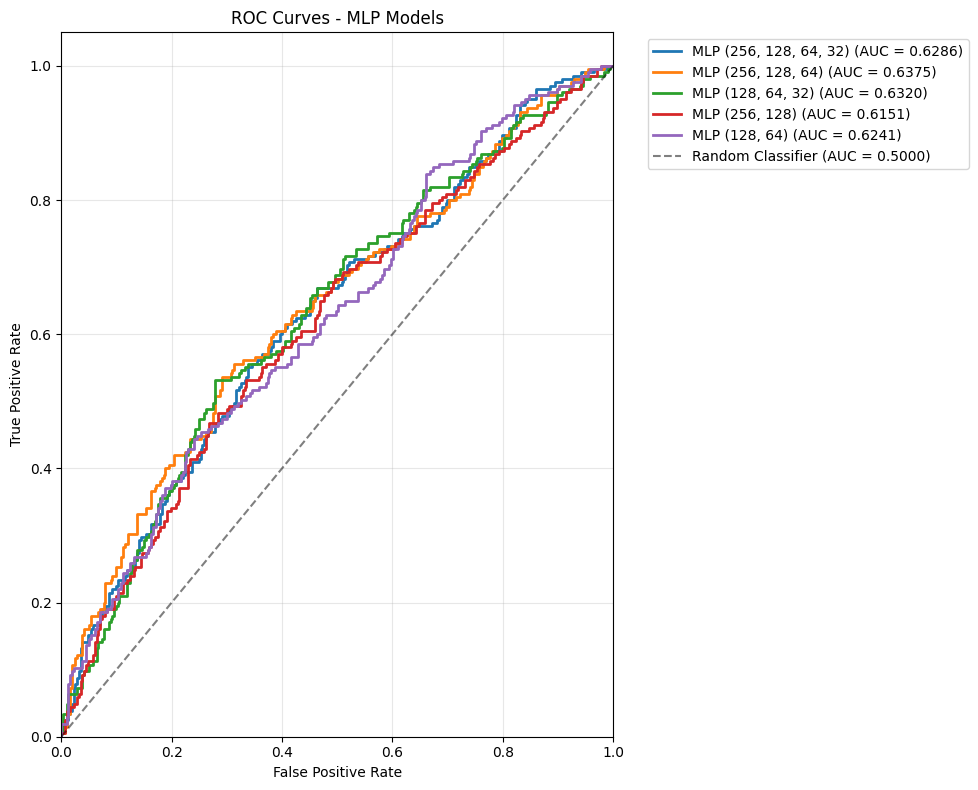


Generating Metrics Comparison for Pipeline Method...


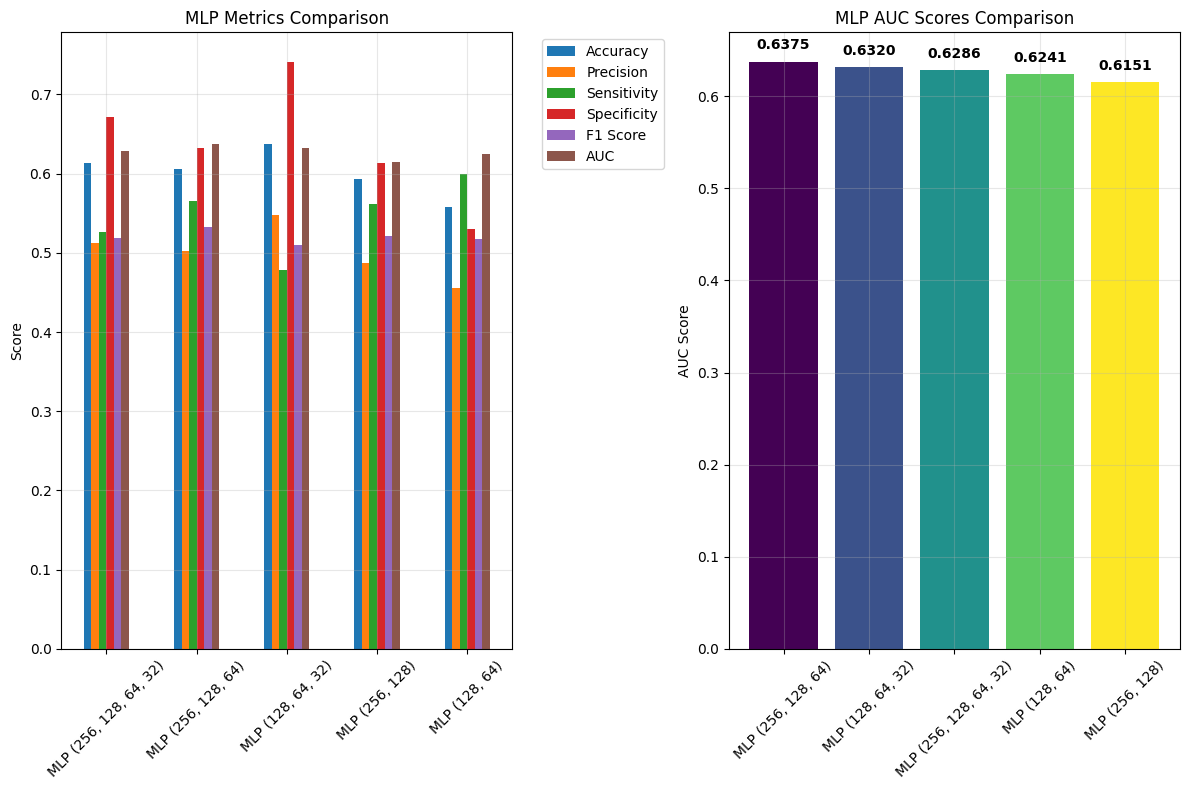


METHOD 2: MLP with Explicit SMOTE
Applying SMOTE only to training data...
Training set shape before SMOTE: (2070, 3)
Training set shape after SMOTE: (2500, 3)
Class distribution after SMOTE: [1250 1250]
--------------------------------------------------------------------------------
Training MLP (256, 128, 64, 32)...
MLP (256, 128, 64, 32) Results:
  Accuracy: 0.6139
  Precision: 0.5118
  Sensitivity: 0.5268
  Specificity: 0.6709
  F1 Score: 0.5192
  Recall: 0.5268
  AUC: 0.6286
  Iterations: 224
  Loss: 0.4403
  Final loss: 0.4271
--------------------------------------------------
Training MLP (256, 128, 64)...
MLP (256, 128, 64) Results:
  Accuracy: 0.6062
  Precision: 0.5022
  Sensitivity: 0.5659
  Specificity: 0.6326
  F1 Score: 0.5321
  Recall: 0.5659
  AUC: 0.6375
  Iterations: 267
  Loss: 0.4647
  Final loss: 0.4625
--------------------------------------------------
Training MLP (128, 64, 32)...
MLP (128, 64, 32) Results:
  Accuracy: 0.6371
  Precision: 0.5475
  Sensitivity: 0.

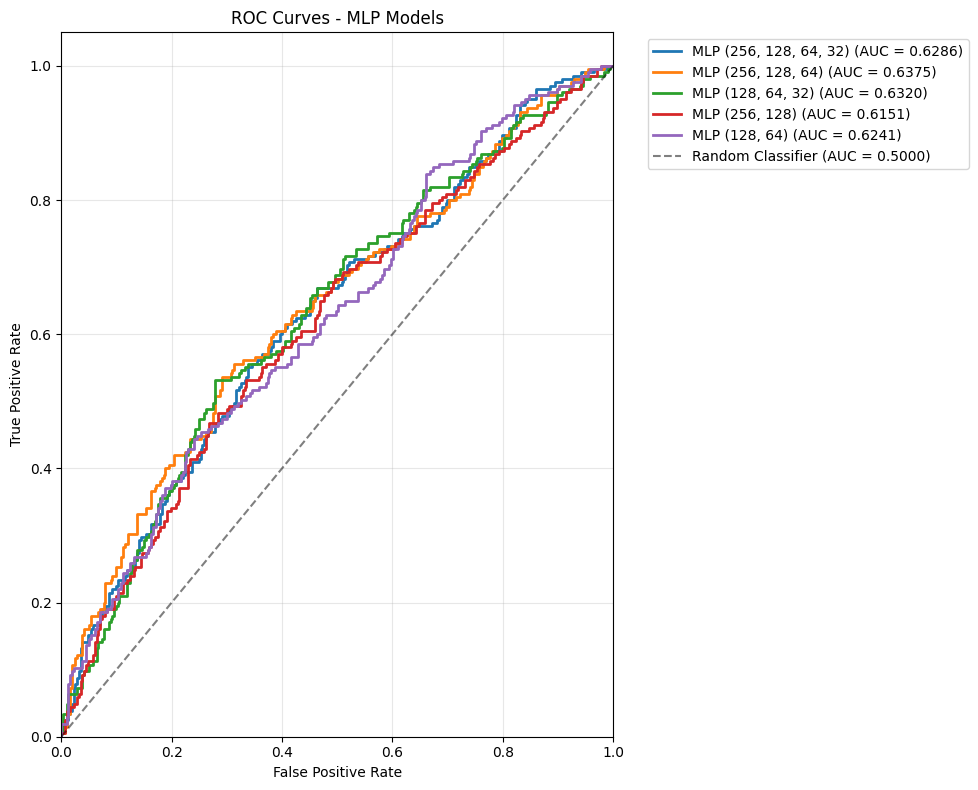


Generating Metrics Comparison for Explicit Method...


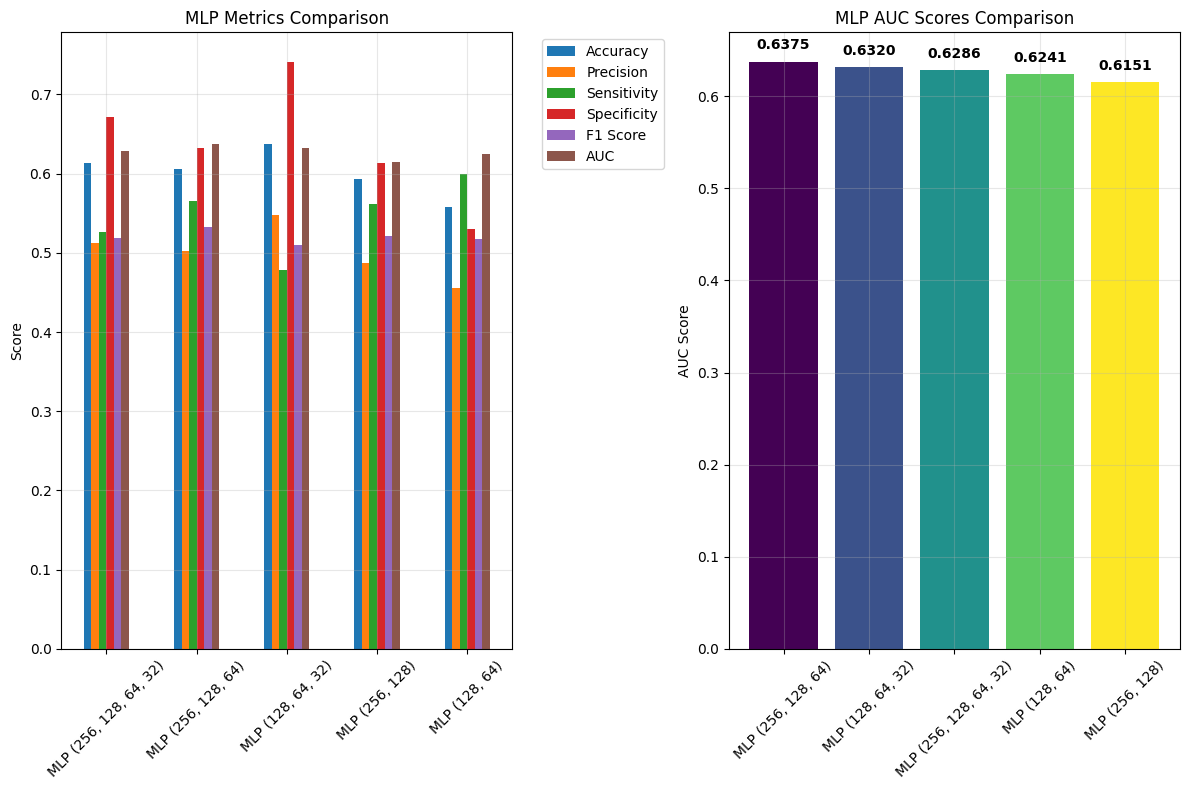


METHOD 3: MLP Architecture Comparison
Training MLP (256, 128, 64, 32)...
MLP (256, 128, 64, 32) Results:
  Architecture: (256, 128, 64, 32)
  Accuracy: 0.6139, F1: 0.5192, AUC: 0.6285513909452194
  Iterations: 224, Loss: 0.4403
--------------------------------------------------
Training MLP (256, 128, 64)...
MLP (256, 128, 64) Results:
  Architecture: (256, 128, 64)
  Accuracy: 0.6062, F1: 0.5321, AUC: 0.6375282474869477
  Iterations: 267, Loss: 0.4647
--------------------------------------------------
Training MLP (128, 64, 32)...
MLP (128, 64, 32) Results:
  Architecture: (128, 64, 32)
  Accuracy: 0.6371, F1: 0.5104, AUC: 0.632026805891062
  Iterations: 148, Loss: 0.5827
--------------------------------------------------
Training MLP (256, 128)...
MLP (256, 128) Results:
  Architecture: (256, 128)
  Accuracy: 0.5927, F1: 0.5215, AUC: 0.6150705213122418
  Iterations: 251, Loss: 0.5552
--------------------------------------------------
Training MLP (128, 64)...
MLP (128, 64) Results:


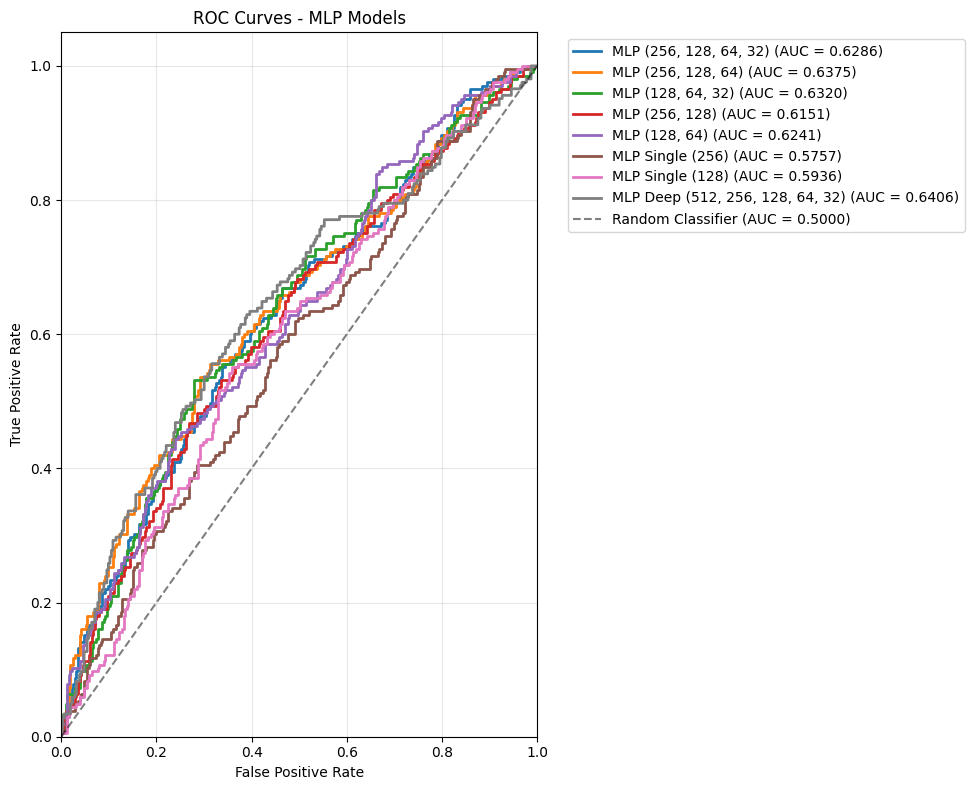


Generating Metrics Comparison for Architecture Comparison...


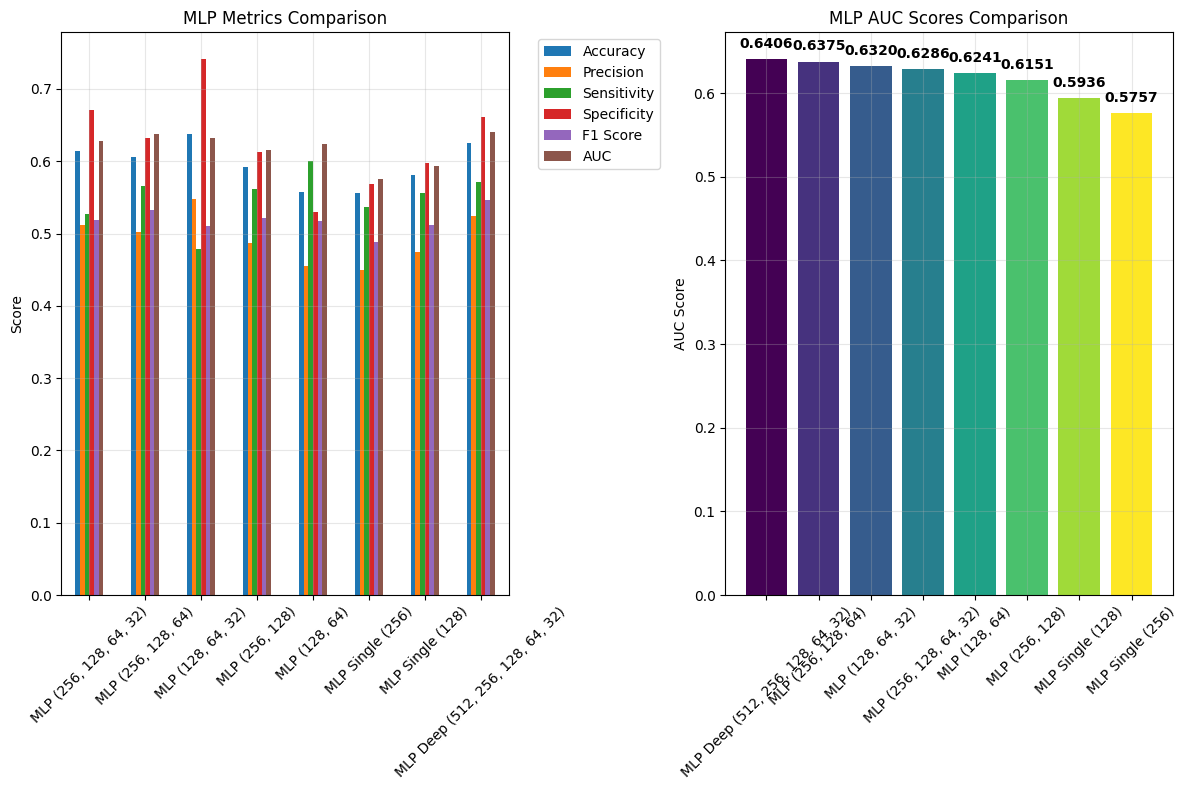


Analyzing Probability Distributions...


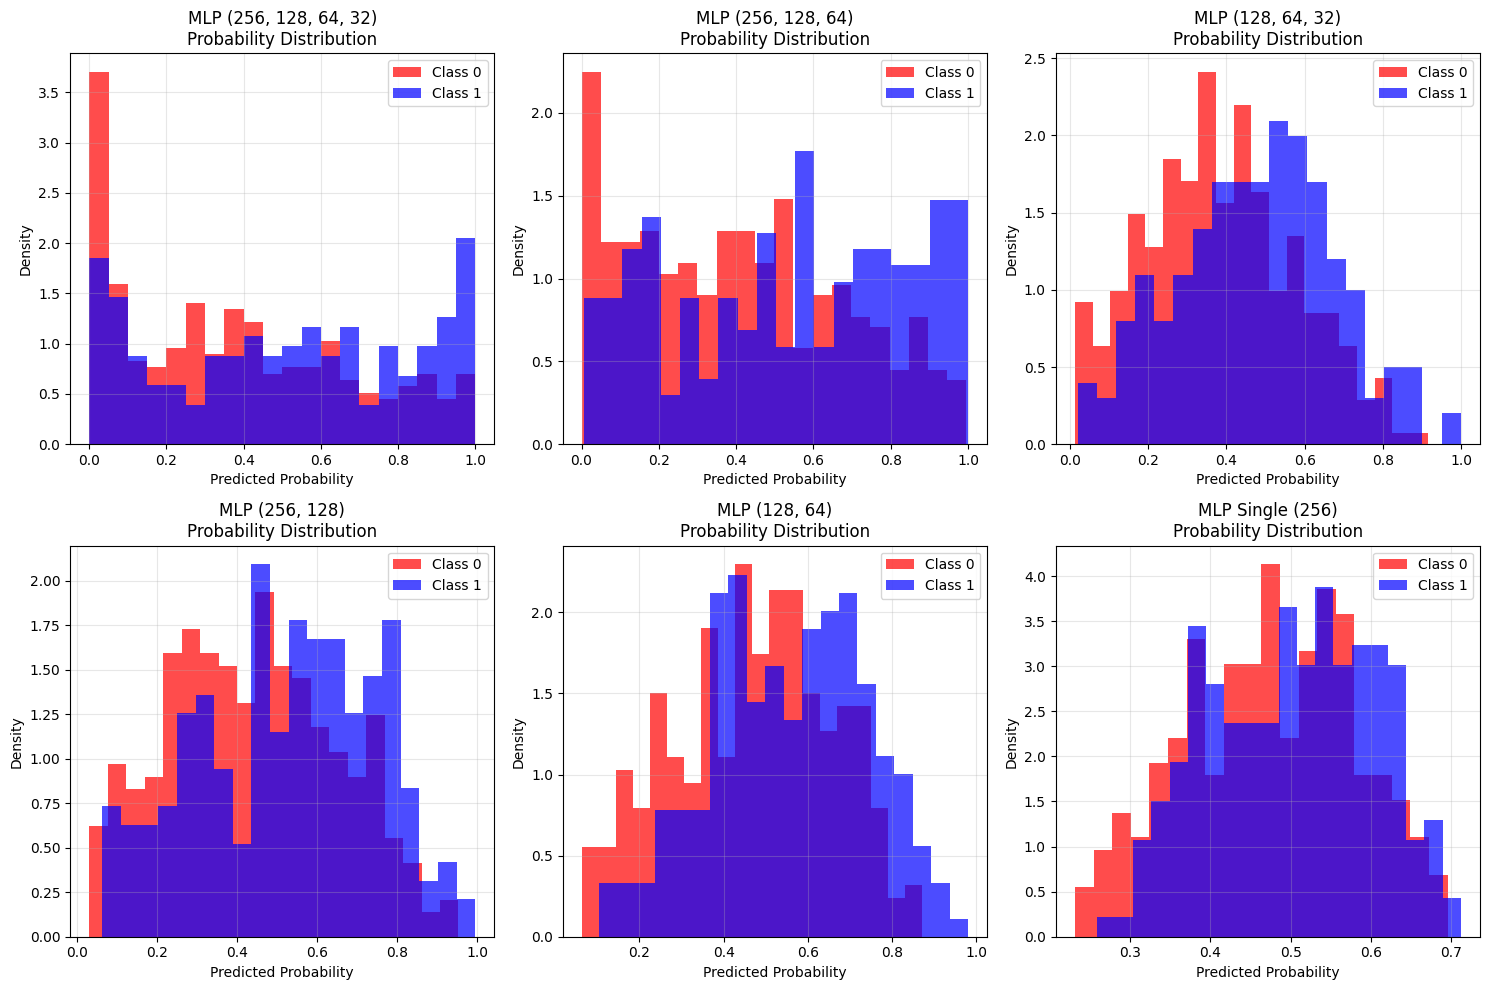


DETAILED INFO FOR MAIN MODEL: MLP (256, 128, 64, 32)
Architecture: [3, 256, 128, 64, 32, 1]
Total layers: 6
Total parameters: Input(3) -> Hidden(256, 128, 64, 32) -> Output(1)
Activation: relu, Solver: adam
Training iterations: 224, Final loss: 0.4403


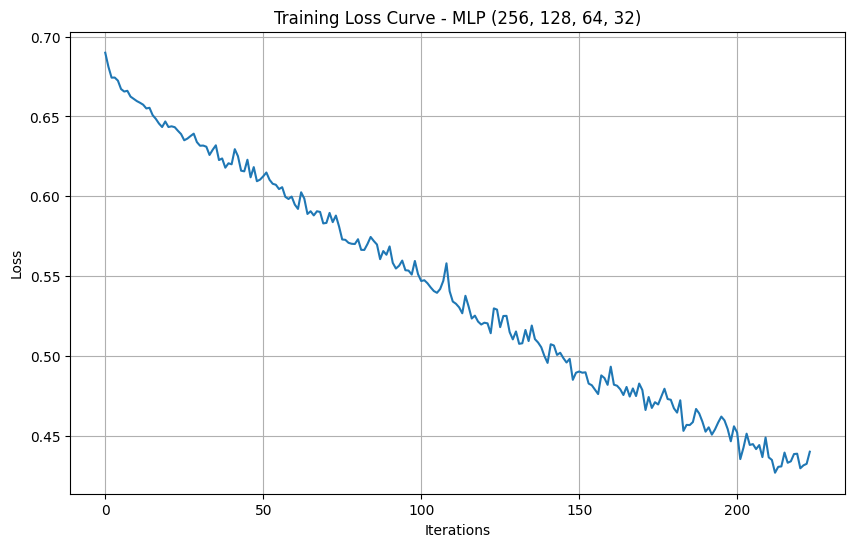

Final loss: 0.4403
Total iterations: 224

COMPREHENSIVE MLP RESULTS COMPARISON
          Method                             Model  Accuracy  Precision  \
0       Pipeline            MLP (256, 128, 64, 32)    0.6139     0.5118   
1       Pipeline                MLP (256, 128, 64)    0.6062     0.5022   
2       Pipeline                 MLP (128, 64, 32)    0.6371     0.5475   
3       Pipeline                    MLP (256, 128)    0.5927     0.4873   
4       Pipeline                     MLP (128, 64)    0.5579     0.4556   
5       Explicit            MLP (256, 128, 64, 32)    0.6139     0.5118   
6       Explicit                MLP (256, 128, 64)    0.6062     0.5022   
7       Explicit                 MLP (128, 64, 32)    0.6371     0.5475   
8       Explicit                    MLP (256, 128)    0.5927     0.4873   
9       Explicit                     MLP (128, 64)    0.5579     0.4556   
10  Architecture            MLP (256, 128, 64, 32)    0.6139     0.5118   
11  Architecture     

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Initialize MLP models with different hidden layer configurations
mlp_models = {
    "MLP (256, 128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (256, 128, 64)": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (256, 128)": MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP (128, 64)": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
}

# Additional MLP configurations for comparison
additional_mlp_models = {
    "MLP Single (256)": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP Single (128)": MLPClassifier(
        hidden_layer_sizes=(128,),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ),
    "MLP Deep (512, 256, 128, 64, 32)": MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
}

def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Calculate all evaluation metrics including AUC
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    recall = sensitivity  # Recall is the same as sensitivity
    
    # Calculate AUC if probabilities are provided
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    
    results = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'Recall': recall
    }
    
    if auc is not None:
        results['AUC'] = auc
    
    return results

def train_and_evaluate_mlp_pipeline(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate MLP models with SMOTE using Pipeline
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Original training set shape: {X_train.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Test set shape: {X_test.shape}")
    print(f"Class distribution in test set: {np.bincount(y_test)}")
    print("-" * 80)
    
    results = {}
    trained_models = {}
    all_probabilities = {}
    
    for mlp_name, mlp_model in mlp_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create pipeline with SMOTE and MLP
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=random_state)),
                ('classifier', mlp_model)
            ])
            
            # Fit the model (SMOTE will be applied only to training data)
            pipeline.fit(X_train, y_train)
            
            # Make predictions and probabilities
            y_pred = pipeline.predict(X_test)
            y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[mlp_name] = metrics
            trained_models[mlp_name] = pipeline
            all_probabilities[mlp_name] = y_proba
            
            # Print results
            print(f"{mlp_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            
            # Print training convergence info
            final_mlp = pipeline.named_steps['classifier']
            print(f"  Iterations: {final_mlp.n_iter_}")
            print(f"  Loss: {final_mlp.loss_:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
            results[mlp_name] = None
    
    return results, trained_models, X_test, y_test, all_probabilities

def train_and_evaluate_mlp_explicit(X, y, test_size=0.2, random_state=42):
    """
    Train and evaluate MLP models with explicit SMOTE application
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("Applying SMOTE only to training data...")
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Training set shape before SMOTE: {X_train.shape}")
    print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")
    print("-" * 80)
    
    results = {}
    trained_models = {}
    all_probabilities = {}
    
    for mlp_name, mlp_model in mlp_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create a fresh instance of the MLP model
            current_mlp = MLPClassifier(
                hidden_layer_sizes=mlp_model.hidden_layer_sizes,
                activation=mlp_model.activation,
                solver=mlp_model.solver,
                max_iter=mlp_model.max_iter,
                random_state=random_state
            )
            
            # Fit the MLP model on resampled data
            current_mlp.fit(X_train_resampled, y_train_resampled)
            
            # Make predictions and probabilities
            y_pred = current_mlp.predict(X_test)
            y_proba = current_mlp.predict_proba(X_test)[:, 1]  # Probability of positive class
            
            # Evaluate the model
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[mlp_name] = metrics
            trained_models[mlp_name] = current_mlp
            all_probabilities[mlp_name] = y_proba
            
            # Print results
            print(f"{mlp_name} Results:")
            for metric, value in metrics.items():
                print(f"  {metric}: {value:.4f}")
            
            # Print training convergence info
            print(f"  Iterations: {current_mlp.n_iter_}")
            print(f"  Loss: {current_mlp.loss_:.4f}")
            print(f"  Final loss: {current_mlp.best_loss_:.4f}" if hasattr(current_mlp, 'best_loss_') else "  Best loss: N/A")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
            results[mlp_name] = None
    
    return results, trained_models, X_test, y_test, all_probabilities

def train_mlp_with_different_architectures(X, y, test_size=0.2, random_state=42):
    """
    Train MLP with various architectures including the main one and additional ones
    """
    # Combine all models
    all_models = {**mlp_models, **additional_mlp_models}
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Apply SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    results = {}
    trained_models = {}
    all_probabilities = {}
    
    for mlp_name, mlp_model in all_models.items():
        print(f"Training {mlp_name}...")
        
        try:
            # Create a fresh instance
            current_mlp = MLPClassifier(
                hidden_layer_sizes=mlp_model.hidden_layer_sizes,
                activation=mlp_model.activation,
                solver=mlp_model.solver,
                max_iter=mlp_model.max_iter,
                random_state=random_state
            )
            
            current_mlp.fit(X_train_resampled, y_train_resampled)
            y_pred = current_mlp.predict(X_test)
            y_proba = current_mlp.predict_proba(X_test)[:, 1]  # Probability of positive class
            metrics = evaluate_model(y_test, y_pred, y_proba)
            results[mlp_name] = metrics
            trained_models[mlp_name] = current_mlp
            all_probabilities[mlp_name] = y_proba
            
            print(f"{mlp_name} Results:")
            print(f"  Architecture: {current_mlp.hidden_layer_sizes}")
            print(f"  Accuracy: {metrics['Accuracy']:.4f}, F1: {metrics['F1 Score']:.4f}, AUC: {metrics.get('AUC', 'N/A')}")
            print(f"  Iterations: {current_mlp.n_iter_}, Loss: {current_mlp.loss_:.4f}")
            print("-" * 50)
            
        except Exception as e:
            print(f"Error training {mlp_name}: {e}")
    
    return results, trained_models, all_probabilities

def plot_roc_curves(y_test, probabilities_dict, figsize=(10, 8)):
    """
    Plot ROC curves for all MLP models
    """
    plt.figure(figsize=figsize)
    
    # Plot ROC curve for each model
    for model_name, y_proba in probabilities_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.5000)')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - MLP Models')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(results_df, figsize=(12, 8)):
    """
    Plot comparison of all metrics including AUC
    """
    metrics_to_plot = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'AUC']
    available_metrics = [metric for metric in metrics_to_plot if metric in results_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot for metrics
    results_df[available_metrics].plot(kind='bar', ax=axes[0], rot=45)
    axes[0].set_title('MLP Metrics Comparison')
    axes[0].set_ylabel('Score')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # AUC-focused comparison
    if 'AUC' in results_df.columns:
        auc_sorted = results_df.sort_values('AUC', ascending=False)
        colors = plt.cm.viridis(np.linspace(0, 1, len(auc_sorted)))
        bars = axes[1].bar(range(len(auc_sorted)), auc_sorted['AUC'], color=colors)
        axes[1].set_title('MLP AUC Scores Comparison')
        axes[1].set_ylabel('AUC Score')
        axes[1].set_xticks(range(len(auc_sorted)))
        axes[1].set_xticklabels(auc_sorted.index, rotation=45)
        axes[1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, auc_sorted['AUC']):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_probability_distributions(probabilities_dict, y_test, figsize=(15, 10)):
    """
    Plot probability distributions for MLP models
    """
    n_models = len(probabilities_dict)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    
    for idx, (model_name, y_proba) in enumerate(probabilities_dict.items()):
        if idx < len(axes):
            # Separate probabilities by true class
            proba_class_0 = y_proba[y_test == 0]
            proba_class_1 = y_proba[y_test == 1]
            
            # Plot histogram
            axes[idx].hist(proba_class_0, alpha=0.7, label='Class 0', bins=20, color='red', density=True)
            axes[idx].hist(proba_class_1, alpha=0.7, label='Class 1', bins=20, color='blue', density=True)
            axes[idx].set_title(f'{model_name}\nProbability Distribution')
            axes[idx].set_xlabel('Predicted Probability')
            axes[idx].set_ylabel('Density')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def display_results(results):
    """
    Display results in a formatted table
    """
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    
    print("\n" + "="*80)
    print("MLP RESULTS")
    print("="*80)
    print(results_df)
    
    # Find best MLP for each metric
    print("\n" + "="*80)
    print("BEST MLP MODELS FOR EACH METRIC")
    print("="*80)
    for metric in results_df.columns:
        if results_df[metric].notna().any():
            best_model = results_df[metric].idxmax()
            best_score = results_df[metric].max()
            print(f"{metric}: {best_model} ({best_score:.4f})")
    
    return results_df

def plot_mlp_training_loss(mlp_model, model_name):
    """
    Plot training loss curve for MLP model
    """
    if hasattr(mlp_model, 'loss_curve_'):
        plt.figure(figsize=(10, 6))
        plt.plot(mlp_model.loss_curve_)
        plt.title(f'Training Loss Curve - {model_name}')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()
        
        print(f"Final loss: {mlp_model.loss_curve_[-1]:.4f}")
        print(f"Total iterations: {len(mlp_model.loss_curve_)}")
    else:
        print("No loss curve available for this model")

def get_mlp_architecture_info(mlp_model):
    """
    Get detailed information about MLP architecture
    """
    info = {
        'hidden_layers': mlp_model.hidden_layer_sizes,
        'activation': mlp_model.activation,
        'solver': mlp_model.solver,
        'iterations': mlp_model.n_iter_,
        'final_loss': mlp_model.loss_,
        'layers': [mlp_model.n_features_in_] + list(mlp_model.hidden_layer_sizes) + [mlp_model.n_outputs_]
    }
    
    print(f"Architecture: {info['layers']}")
    print(f"Total layers: {len(info['layers'])}")
    print(f"Total parameters: Input({mlp_model.n_features_in_}) -> Hidden{mlp_model.hidden_layer_sizes} -> Output({mlp_model.n_outputs_})")
    print(f"Activation: {mlp_model.activation}, Solver: {mlp_model.solver}")
    print(f"Training iterations: {mlp_model.n_iter_}, Final loss: {mlp_model.loss_:.4f}")
    
    return info

# Main execution function
def main():
    """
    Main function to run all MLP experiments
    """
    print("🚀 MLP CLASSIFIER EVALUATION WITH SMOTE AND AUC")
    print("="*50)
    print("Main Model: MLP with hidden_layer_sizes=(256, 128, 64, 32)")
    print("Activation: relu, Solver: adam, Max Iterations: 500")
    print("="*50)
    
    # Method 1: Using Pipeline
    print("\nMETHOD 1: MLP with Pipeline")
    print("="*30)
    results_pipeline, models_pipeline, X_test, y_test, probabilities_pipeline = train_and_evaluate_mlp_pipeline(embedding_custom, y)
    results_df_pipeline = display_results(results_pipeline)
    
    # Plot ROC curves for pipeline method
    print("\nGenerating ROC Curves for Pipeline Method...")
    plot_roc_curves(y_test, probabilities_pipeline)
    
    # Plot metrics comparison for pipeline method
    print("\nGenerating Metrics Comparison for Pipeline Method...")
    plot_metrics_comparison(results_df_pipeline)
    
    # Method 2: Explicit SMOTE
    print("\nMETHOD 2: MLP with Explicit SMOTE")
    print("="*30)
    results_explicit, models_explicit, X_test_explicit, y_test_explicit, probabilities_explicit = train_and_evaluate_mlp_explicit(embedding_custom, y)
    results_df_explicit = display_results(results_explicit)
    
    # Plot ROC curves for explicit method
    print("\nGenerating ROC Curves for Explicit Method...")
    plot_roc_curves(y_test_explicit, probabilities_explicit)
    
    # Plot metrics comparison for explicit method
    print("\nGenerating Metrics Comparison for Explicit Method...")
    plot_metrics_comparison(results_df_explicit)
    
    # Method 3: Compare different architectures
    print("\nMETHOD 3: MLP Architecture Comparison")
    print("="*30)
    results_arch, models_arch, probabilities_arch = train_mlp_with_different_architectures(embedding_custom, y)
    results_df_arch = display_results(results_arch)
    
    # Plot ROC curves for architecture comparison
    print("\nGenerating ROC Curves for Architecture Comparison...")
    plot_roc_curves(y_test, probabilities_arch)
    
    # Plot metrics comparison for architecture comparison
    print("\nGenerating Metrics Comparison for Architecture Comparison...")
    plot_metrics_comparison(results_df_arch)
    
    # Plot probability distributions
    print("\nAnalyzing Probability Distributions...")
    # Combine probabilities from different methods for analysis
    all_probabilities = {**probabilities_pipeline, **probabilities_explicit, **probabilities_arch}
    plot_probability_distributions(all_probabilities, y_test)
    
    # Display detailed info for the main model
    print("\n" + "="*80)
    print("DETAILED INFO FOR MAIN MODEL: MLP (256, 128, 64, 32)")
    print("="*80)
    
    main_model_key = "MLP (256, 128, 64, 32)"
    if main_model_key in models_explicit:
        main_model = models_explicit[main_model_key]
        architecture_info = get_mlp_architecture_info(main_model)
        
        # Plot training loss if available
        plot_mlp_training_loss(main_model, main_model_key)
    
    # Compare all results
    print("\n" + "="*80)
    print("COMPREHENSIVE MLP RESULTS COMPARISON")
    print("="*80)
    
    # Create comprehensive comparison
    comparison_data = []
    for method_name, results in [("Pipeline", results_pipeline), 
                                ("Explicit", results_explicit),
                                ("Architecture", results_arch)]:
        for model_name, metrics in results.items():
            comparison_data.append({
                'Method': method_name,
                'Model': model_name,
                'Accuracy': metrics['Accuracy'],
                'Precision': metrics['Precision'],
                'Sensitivity': metrics['Sensitivity'],
                'Specificity': metrics['Specificity'],
                'F1_Score': metrics['F1 Score'],
                'AUC': metrics.get('AUC', None)
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.round(4))
    
    return {
        'results_pipeline': results_pipeline,
        'results_explicit': results_explicit,
        'results_arch': results_arch,
        'models_pipeline': models_pipeline,
        'models_explicit': models_explicit,
        'models_arch': models_arch,
        'probabilities_pipeline': probabilities_pipeline,
        'probabilities_explicit': probabilities_explicit,
        'probabilities_arch': probabilities_arch
    }

# Run the main function
if __name__ == "__main__":
    # Run all MLP experiments
    mlp_results = main()
    
    # Save results to CSV
    results_df_pipeline = pd.DataFrame(mlp_results['results_pipeline']).T
    results_df_explicit = pd.DataFrame(mlp_results['results_explicit']).T
    results_df_arch = pd.DataFrame(mlp_results['results_arch']).T
    
    results_df_pipeline.to_csv('mlp_pipeline_results.csv')
    results_df_explicit.to_csv('mlp_explicit_results.csv')
    results_df_arch.to_csv('mlp_architecture_results.csv')
    
    print("\nResults saved to CSV files:")
    print("- mlp_pipeline_results.csv")
    print("- mlp_explicit_results.csv") 
    print("- mlp_architecture_results.csv")

# LSTM (CPU and GPU)

CPU devices available: 1
=== TensorFlow Configuration ===
GPU devices: []
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Running on CPU: True

=== Dataset Preparation ===
Original data shape: (2588, 2)
Target shape: (2588,)
Shuffled data shape: (2588, 2)
Original class distribution: [1563 1025]
Class 0: 1563 samples
Class 1: 1025 samples

===== Fold 1/5 =====
Training samples: 2070, Test samples: 518
Original Train class distribution: [1250  820]
Test class distribution: [313 205]

Applying SMOTE to training data...
After SMOTE - Train samples: 2500
After SMOTE - Class distribution: [1250 1250]
SMOTE created 430 synthetic samples
Training data shape for LSTM: (2500, 2, 1)
Test data shape for LSTM: (518, 2, 1)
Training model on SMOTE-balanced data...
Making predictions...
✓ Fold 1 - Accuracy: 0.5965, F1: 0.3569, AUC: 0.5395
  Completed: 5/15 epochs
  Final training loss: 0.6740
  Final validation loss: 0.9409

===== Fold 2/5 =====
Training samples: 2070,

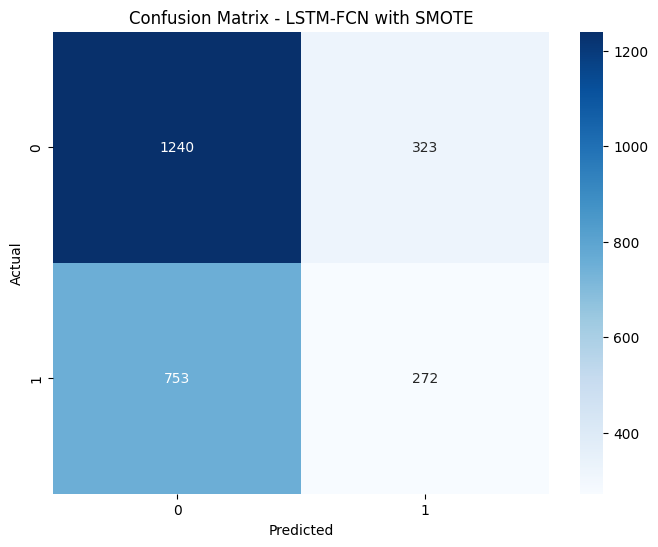

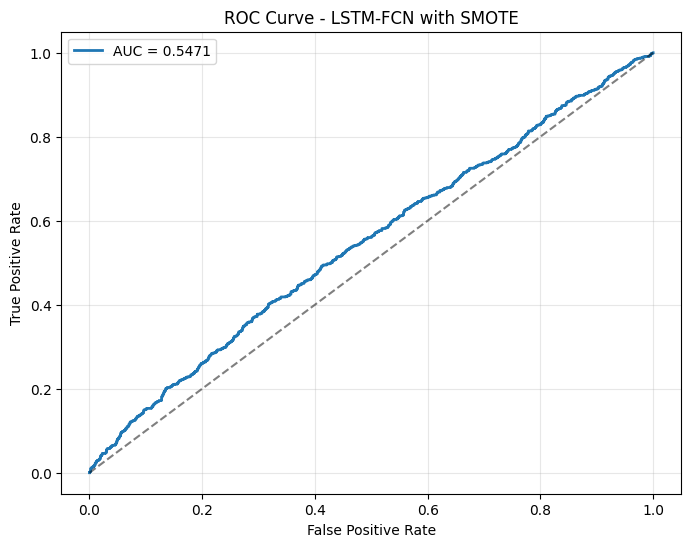

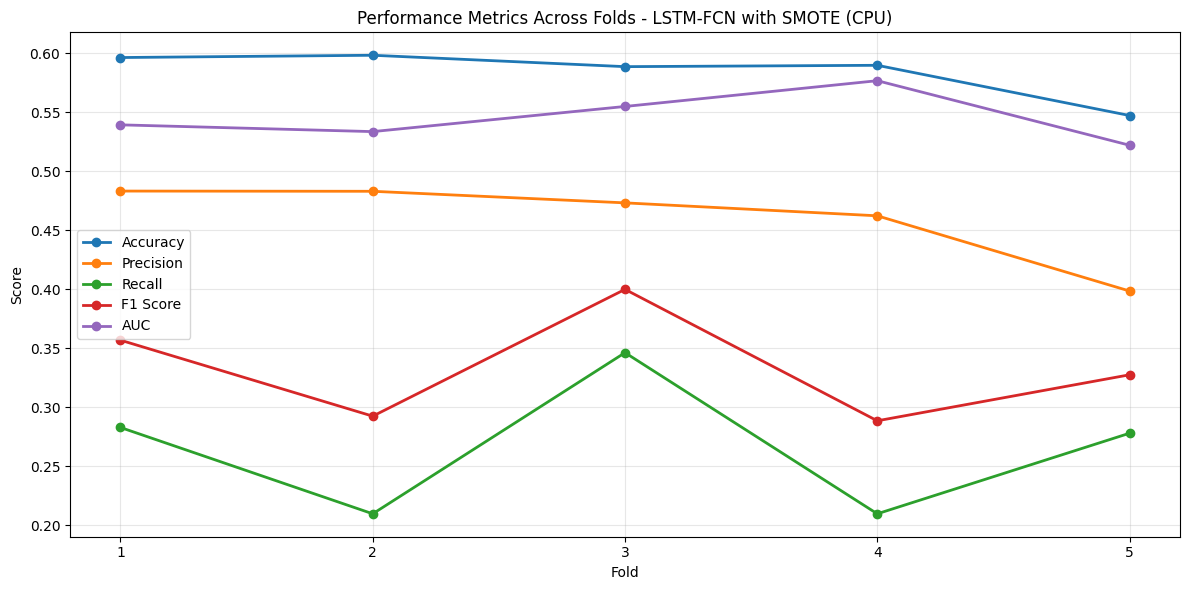

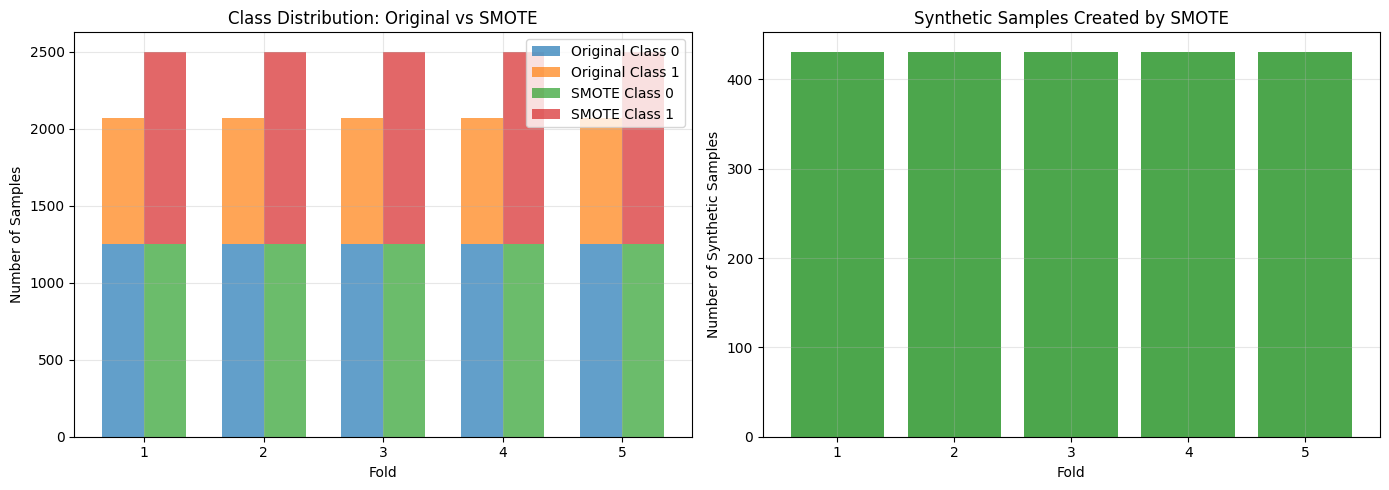


=== Model Information ===
Classifier: Custom LSTM-FCN with SMOTE (Forced CPU Execution)
Architecture: LSTM(64) + Conv1D(64,128,64) + GlobalAveragePooling1D
Number of epochs: 15
Batch size: 8
Learning rate: 0.001
Early stopping patience: 3
Number of folds: 5
SMOTE applied: Yes (only to training folds, before reshaping)
TensorFlow running on: CPU ONLY (GPU forcefully disabled)
Original data shape: (2588, 2)
Reshaped data shape for LSTM: (samples, 2, 1)


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==== FORCE CPU ONLY - Multiple safeguards ====
# Method 1: Environment variables (set before ANY TensorFlow import)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations

# Method 2: Disable GPU via TensorFlow configuration
import tensorflow as tf

# Disable GPU completely
tf.config.set_visible_devices([], 'GPU')

# Force CPU
try:
    cpu_devices = tf.config.list_physical_devices('CPU')
    tf.config.set_visible_devices(cpu_devices, 'CPU')
    print(f"CPU devices available: {len(cpu_devices)}")
except:
    pass

# Disable JIT compilation
tf.config.run_functions_eagerly(True)
tf.data.experimental.enable_debug_mode()  # Disable optimizations

# Set TensorFlow to use CPU exclusively
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Conv1D, GlobalAveragePooling1D, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.utils import shuffle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Verify GPU is disabled
print("=== TensorFlow Configuration ===")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")
print(f"CPU devices: {tf.config.list_physical_devices('CPU')}")
print(f"Running on CPU: {len(tf.config.list_physical_devices('GPU')) == 0}")
print("="*50)

# ==== LSTM-FCN Model Definition ====
def create_lstm_fcn_model(input_shape, n_classes=2, learning_rate=0.001):
    """
    Create LSTM-FCN model for time series classification
    """
    with tf.device('/CPU:0'):  # Explicitly force CPU
        inputs = Input(shape=input_shape)
        
        # LSTM branch
        lstm_out = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(inputs)
        lstm_out = Dropout(0.3)(lstm_out)
        
        # FCN branch
        # Conv block 1
        conv1 = Conv1D(64, 8, activation='relu', padding='same')(inputs)
        conv1 = BatchNormalization()(conv1)
        
        # Conv block 2
        conv2 = Conv1D(128, 5, activation='relu', padding='same')(conv1)
        conv2 = BatchNormalization()(conv2)
        
        # Conv block 3
        conv3 = Conv1D(64, 3, activation='relu', padding='same')(conv2)
        conv3 = BatchNormalization()(conv3)
        
        # Global pooling
        gap = GlobalAveragePooling1D()(conv3)
        gap = Dropout(0.3)(gap)
        
        # Concatenate branches
        concatenated = Concatenate()([lstm_out, gap])
        
        # Output layer
        if n_classes == 2:
            outputs = Dense(1, activation='sigmoid')(concatenated)
        else:
            outputs = Dense(n_classes, activation='softmax')(concatenated)
        
        model = Model(inputs=inputs, outputs=outputs)
        
        # Compile model
        if n_classes == 2:
            model.compile(optimizer=Adam(learning_rate=learning_rate), 
                         loss='binary_crossentropy', 
                         metrics=['accuracy'])
        else:
            model.compile(optimizer=Adam(learning_rate=learning_rate), 
                         loss='sparse_categorical_crossentropy', 
                         metrics=['accuracy'])
        
        return model

# ==== Prepare data for LSTM-FCN ====
def prepare_lstm_fcn_data(X, y):
    """
    Prepare data for LSTM-FCN model
    Expected input: X is 2D array (samples, features)
    Output: Reshaped to (samples, timesteps, features) for LSTM
    """
    # Reshape to 3D: (samples, timesteps, features)
    if len(X.shape) == 2:
        X_reshaped = X.reshape(X.shape[0], X.shape[1], 1)
    else:
        X_reshaped = X
    
    return X_reshaped, y

# ==== Evaluation Utilities ====
def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return acc, prec, recall, f1, specificity

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix - LSTM-FCN with SMOTE")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - LSTM-FCN with SMOTE")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ==== Dataset Preparation ====
print("\n=== Dataset Preparation ===")
print(f"Original data shape: {embedding_custom.shape}")
print(f"Target shape: {y.shape}")

# Shuffle the data (keep in 2D for SMOTE)
X_shuffled, y_shuffled = shuffle(embedding_custom, y, random_state=42)

print(f"Shuffled data shape: {X_shuffled.shape}")
print(f"Original class distribution: {np.bincount(y_shuffled)}")
print(f"Class 0: {np.bincount(y_shuffled)[0]} samples")
print(f"Class 1: {np.bincount(y_shuffled)[1] if len(np.bincount(y_shuffled)) > 1 else 0} samples")
print("="*50)

# ==== Training Parameters (Reduced for CPU) ====
N_EPOCHS = 15
BATCH_SIZE = 8
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 3

# Initialize SMOTE
smote = SMOTE(random_state=42)

# ==== 5-Fold Cross-Validation with SMOTE (applied to 2D data) ====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_true, all_preds, all_probs = [], [], []
fold_metrics = []
fold_smote_info = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_shuffled, y_shuffled), 1):
    print(f"\n===== Fold {fold}/5 =====")
    print(f"Training samples: {len(train_idx)}, Test samples: {len(test_idx)}")
    
    # Get fold data (still in 2D for SMOTE)
    X_train_2d, X_test_2d = X_shuffled[train_idx], X_shuffled[test_idx]
    y_train, y_test = y_shuffled[train_idx], y_shuffled[test_idx]
    
    # Print original class distribution
    print(f"Original Train class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
    
    # Apply SMOTE to training data (2D array)
    print("\nApplying SMOTE to training data...")
    X_train_resampled_2d, y_train_resampled = smote.fit_resample(X_train_2d, y_train)
    
    # Print SMOTE results
    print(f"After SMOTE - Train samples: {len(X_train_resampled_2d)}")
    print(f"After SMOTE - Class distribution: {np.bincount(y_train_resampled)}")
    print(f"SMOTE created {len(X_train_resampled_2d) - len(X_train_2d)} synthetic samples")
    
    # Store SMOTE info
    fold_smote_info.append({
        'Fold': fold,
        'Original_train_size': len(X_train_2d),
        'SMOTE_train_size': len(X_train_resampled_2d),
        'Synthetic_samples': len(X_train_resampled_2d) - len(X_train_2d),
        'Original_class_0': np.bincount(y_train)[0] if len(np.bincount(y_train)) > 0 else 0,
        'Original_class_1': np.bincount(y_train)[1] if len(np.bincount(y_train)) > 1 else 0,
        'SMOTE_class_0': np.bincount(y_train_resampled)[0] if len(np.bincount(y_train_resampled)) > 0 else 0,
        'SMOTE_class_1': np.bincount(y_train_resampled)[1] if len(np.bincount(y_train_resampled)) > 1 else 0
    })
    
    # Reshape to 3D for LSTM-FCN
    X_train_reshaped = X_train_resampled_2d.reshape(X_train_resampled_2d.shape[0], X_train_resampled_2d.shape[1], 1)
    X_test_reshaped = X_test_2d.reshape(X_test_2d.shape[0], X_test_2d.shape[1], 1)
    
    print(f"Training data shape for LSTM: {X_train_reshaped.shape}")
    print(f"Test data shape for LSTM: {X_test_reshaped.shape}")
    
    try:
        # Clear session to avoid memory issues
        tf.keras.backend.clear_session()
        gc.collect()
        
        # Create model (explicitly on CPU)
        with tf.device('/CPU:0'):
            model = create_lstm_fcn_model(
                input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]),
                n_classes=2,
                learning_rate=LEARNING_RATE
            )
        
        # Early stopping callback
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        )
        
        # Train model on SMOTE-resampled data
        print("Training model on SMOTE-balanced data...")
        history = model.fit(
            X_train_reshaped, y_train_resampled,
            epochs=N_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )
        
        # Make predictions
        print("Making predictions...")
        y_proba = model.predict(X_test_reshaped, verbose=0).flatten()
        y_pred = (y_proba > 0.5).astype(int)
        
        # Store results
        all_true.extend(y_test)
        all_preds.extend(y_pred)
        all_probs.extend(y_proba)
        
        # Calculate fold metrics
        acc_fold, prec_fold, recall_fold, f1_fold, spec_fold = evaluate_metrics(y_test, y_pred)
        auc_fold = roc_auc_score(y_test, y_proba)
        
        fold_metrics.append({
            'Fold': fold,
            'Accuracy': acc_fold,
            'Precision': prec_fold,
            'Recall': recall_fold,
            'Specificity': spec_fold,
            'F1 Score': f1_fold,
            'AUC': auc_fold
        })
        
        print(f"✓ Fold {fold} - Accuracy: {acc_fold:.4f}, F1: {f1_fold:.4f}, AUC: {auc_fold:.4f}")
        
        # Print training info
        final_epoch = len(history.history['loss'])
        print(f"  Completed: {final_epoch}/{N_EPOCHS} epochs")
        print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
        print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")
        
    except Exception as e:
        print(f"✗ Error in fold {fold}: {e}")
        import traceback
        traceback.print_exc()
        continue

# ==== Final Evaluation ====
if len(all_true) > 0:
    acc, prec, recall, f1, spec = evaluate_metrics(all_true, all_preds)
    auc = roc_auc_score(all_true, all_probs)

    print("\n" + "="*60)
    print("=== FINAL EVALUATION AFTER CROSS-VALIDATION WITH SMOTE ===")
    print("="*60)
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Sensitivity  : {recall:.4f}")
    print(f"Specificity  : {spec:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"AUC          : {auc:.4f}")

    # Print SMOTE summary
    if fold_smote_info:
        print("\n=== SMOTE APPLICATION SUMMARY ===")
        smote_df = pd.DataFrame(fold_smote_info)
        print(smote_df)
        print(f"\nAverage synthetic samples created per fold: {smote_df['Synthetic_samples'].mean():.0f}")
    
    # Print fold summary statistics
    if fold_metrics:
        print("\n=== CROSS-VALIDATION SUMMARY ===")
        fold_metrics_df = pd.DataFrame(fold_metrics)
        print(fold_metrics_df.round(4))
        print("\nMean metrics across folds:")
        print(fold_metrics_df.drop('Fold', axis=1).mean().round(4))
        print(f"\nStandard deviation across folds:")
        print(fold_metrics_df.drop('Fold', axis=1).std().round(4))

    print("\n=== Classification Report ===")
    print(classification_report(all_true, all_preds, digits=4))

    # Plot results
    plot_confusion_matrix(all_true, all_preds)
    plot_roc_curve(all_true, all_probs)

    # Plot fold performance comparison
    if fold_metrics:
        plt.figure(figsize=(12, 6))
        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
        for metric in metrics_to_plot:
            plt.plot(fold_metrics_df['Fold'], fold_metrics_df[metric], marker='o', label=metric, linewidth=2)
        plt.xlabel('Fold')
        plt.ylabel('Score')
        plt.title('Performance Metrics Across Folds - LSTM-FCN with SMOTE (CPU)')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.xticks(range(1, len(fold_metrics) + 1))
        plt.tight_layout()
        plt.show()
        
    # Plot SMOTE impact
    if fold_smote_info:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Class distribution before and after SMOTE
        ax1 = axes[0]
        folds = smote_df['Fold']
        width = 0.35
        ax1.bar(folds - width/2, smote_df['Original_class_0'], width, label='Original Class 0', alpha=0.7)
        ax1.bar(folds - width/2, smote_df['Original_class_1'], width, label='Original Class 1', alpha=0.7, bottom=smote_df['Original_class_0'])
        ax1.bar(folds + width/2, smote_df['SMOTE_class_0'], width, label='SMOTE Class 0', alpha=0.7)
        ax1.bar(folds + width/2, smote_df['SMOTE_class_1'], width, label='SMOTE Class 1', alpha=0.7, bottom=smote_df['SMOTE_class_0'])
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Number of Samples')
        ax1.set_title('Class Distribution: Original vs SMOTE')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # Synthetic samples created
        ax2 = axes[1]
        ax2.bar(folds, smote_df['Synthetic_samples'], color='green', alpha=0.7)
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Number of Synthetic Samples')
        ax2.set_title('Synthetic Samples Created by SMOTE')
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()

else:
    print("\n❌ No successful folds completed.")
    print("\nTroubleshooting suggestions:")
    print("1. Check if your data has the correct shape")
    print("2. Try using a simpler model like Random Forest first")
    print("3. Reduce the number of folds to 3")
    print("4. Reduce epochs to 5")
    print("5. Check system memory availability")
    print("6. Ensure imbalanced-learn is installed: pip install imbalanced-learn")

# Print model information
print("\n=== Model Information ===")
print("Classifier: Custom LSTM-FCN with SMOTE (Forced CPU Execution)")
print(f"Architecture: LSTM(64) + Conv1D(64,128,64) + GlobalAveragePooling1D")
print(f"Number of epochs: {N_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Number of folds: {skf.n_splits}")
print(f"SMOTE applied: Yes (only to training folds, before reshaping)")
print(f"TensorFlow running on: CPU ONLY (GPU forcefully disabled)")
print(f"Original data shape: {embedding_custom.shape}")
print(f"Reshaped data shape for LSTM: (samples, {embedding_custom.shape[1]}, 1)")

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

from sktime.classification.deep_learning.lstmfcn import LSTMFCNClassifier
from sktime.datatypes._panel._convert import from_2d_array_to_nested


# ==== Dataset Preparation ====
# Assuming df_power is a pandas DataFrame with features and a 'Label' column
# X = np.array(combined_df.drop(columns=["Label"]), dtype=np.float32)
# y = np.array(combined_df["Label"], dtype=np.int32)

# ==== Apply SMOTE ====
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(embedding_custom, y)
X_res, y_res = shuffle(X_res, y_res, random_state=42)

# ==== Convert to sktime format ====
X_nested = from_2d_array_to_nested(X_res)

# ==== Evaluation Utilities ====
def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    return acc, prec, recall, f1, specificity

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

# ==== 10-Fold Cross-Validation ====
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_true, all_preds, all_probs = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_nested, y_res), 1):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X_nested.iloc[train_idx], X_nested.iloc[test_idx]
    y_train, y_test = y_res[train_idx], y_res[test_idx]

    clf = LSTMFCNClassifier(n_epochs=50, batch_size=4, random_state=42, verbose=False)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    all_true.extend(y_test)
    all_preds.extend(y_pred)
    all_probs.extend(y_proba)

# ==== Final Metrics ====
acc, prec, recall, f1, spec = evaluate_metrics(all_true, all_preds)
auc = roc_auc_score(all_true, all_probs)

print("\n=== Final Evaluation After 10-Fold Cross-Validation ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(all_true, all_preds, digits=4))

plot_confusion_matrix(all_true, all_preds)
plot_roc_curve(all_true, all_probs)



===== Fold 1 =====


2026-04-09 12:36:35.659038: W tensorflow/core/framework/op_kernel.cc:1842] UNKNOWN: JIT compilation failed.
2026-04-09 12:36:35.659056: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: UNKNOWN: JIT compilation failed.


UnknownError: {{function_node __wrapped__Sign_device_/job:localhost/replica:0/task:0/device:GPU:0}} JIT compilation failed. [Op:Sign] name: 

# Transformer

Using device: cuda
🚀 TRANSFORMER MODEL TRAINING
Model Parameters:
  Embedding Dimension: 256
  Number of Heads: 8
  Number of Layers: 1
  Dropout: 0.1
Training Parameters:
  Epochs: 100
  Learning Rate: 0.0001
  Batch Size: 32
Preparing data...
After SMOTE - X shape: (3126, 10), y distribution: [1563 1563]
Training samples: 2500
Validation samples: 626
Model initialized with input_dim: 10, num_classes: 2
Total parameters: 961,858

Starting training...
Epoch [10/100]
  Train Loss: 0.5715, Train Acc: 70.92%
  Val Loss: 0.6126, Val Acc: 66.29%
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.4969, Train Acc: 75.52%
  Val Loss: 0.5669, Val Acc: 70.77%
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.4300, Train Acc: 79.16%
  Val Loss: 0.5576, Val Acc: 73.00%
--------------------------------------------------
Epoch [40/100]
  Train Loss: 0.3747, Train Acc: 83.56%
  Val Loss: 0.5700, Val Acc: 75.40%
---------------------------

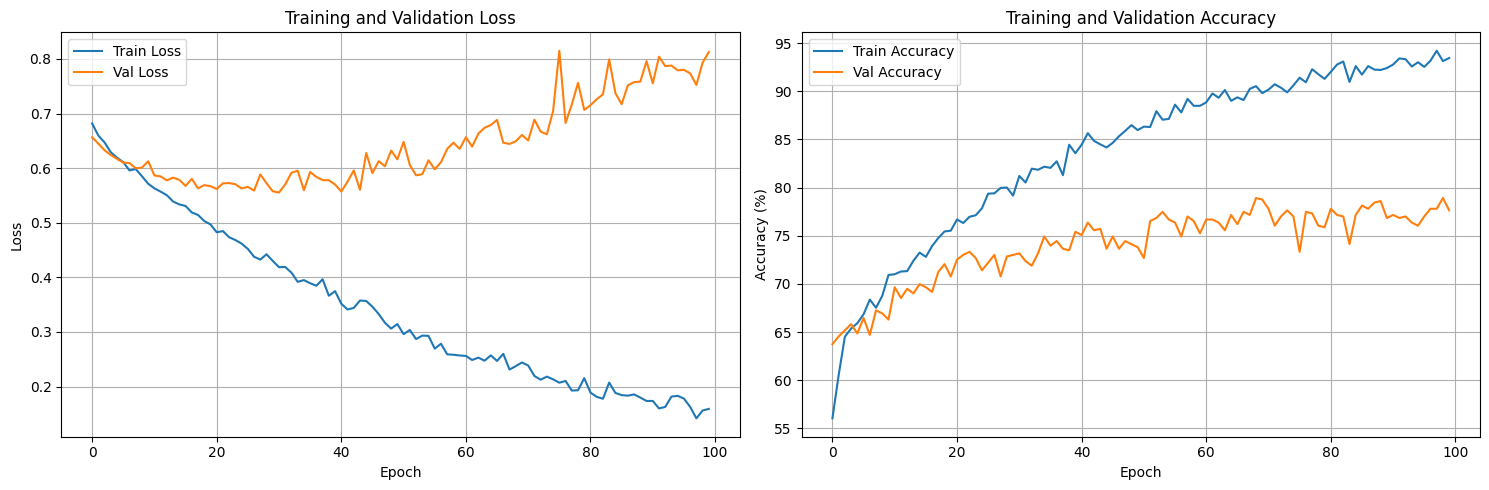


TRANSFORMER TRAINING COMPLETED
Best validation accuracy: 78.91%
Best validation loss: 0.5554
Model saved as 'transformer_model.pth'


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Transformer Model Definition
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, embed_dim=256, num_heads=8, num_layers=1, num_classes=2, dropout=0.1, max_seq_len=500):
        super(TransformerClassifier, self).__init__()
        
        self.embed_dim = embed_dim
        self.input_projection = nn.Linear(input_dim, embed_dim)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_seq_len, embed_dim))
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        batch_size, seq_len, input_dim = x.shape
        
        # Project input to embedding dimension
        x = self.input_projection(x)  # (batch_size, seq_len, embed_dim)
        
        # Add positional encoding
        x = x + self.pos_encoding[:, :seq_len, :]
        
        # Transformer encoder
        x = self.transformer_encoder(x)  # (batch_size, seq_len, embed_dim)
        
        # Use the first token representation for classification (like [CLS] token)
        x = x[:, 0, :]  # (batch_size, embed_dim)
        
        # Classification
        x = self.classifier(x)  # (batch_size, num_classes)
        
        return x

# Data Preparation Functions
def prepare_transformer_data(X, y, sequence_length=1, apply_smote=True, random_state=42):
    """
    Prepare data for Transformer model
    """
    # Convert to numpy if they are DataFrames
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values
    
    # Apply SMOTE if requested
    if apply_smote:
        smote = SMOTE(random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X, y)
        print(f"After SMOTE - X shape: {X_resampled.shape}, y distribution: {np.bincount(y_resampled)}")
        X, y = X_resampled, y_resampled
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reshape for Transformer: (samples, sequence_length, features)
    # For tabular data, we treat each sample as a sequence of length 1
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], sequence_length, X_scaled.shape[1])
    
    # Convert to PyTorch tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    
    return X_tensor, y_tensor, scaler

def create_data_loaders(X_tensor, y_tensor, batch_size=32, train_ratio=0.8):
    """
    Create train and validation data loaders
    """
    dataset = TensorDataset(X_tensor, y_tensor)
    
    # Split dataset
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

# Training Functions
def train_transformer(model, train_loader, val_loader, criterion, optimizer, num_epochs=100):
    """
    Train the Transformer model
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())
        
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}%')
            print(f'  Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracy:.2f}%')
            print('-' * 50)
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'model': model
    }

# Evaluation Functions
def evaluate_model_pytorch(model, data_loader):
    """
    Evaluate the model and return metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    # Calculate specificity from confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        specificity = 0
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Sensitivity': recall,  # Same as recall
        'Specificity': specificity,
        'F1 Score': f1,
        'Predictions': all_preds,
        'True_Labels': all_labels
    }

def plot_training_history(history):
    """
    Plot training history
    """
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot losses
    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracies
    ax2.plot(history['train_accuracies'], label='Train Accuracy')
    ax2.plot(history['val_accuracies'], label='Val Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Main Training Function
def train_transformer_model(X, y, model_params=None, training_params=None):
    """
    Main function to train Transformer model
    """
    # Default parameters
    if model_params is None:
        model_params = {
            'embed_dim': 256,
            'num_heads': 8,
            'num_layers': 1,
            'dropout': 0.1,
            'sequence_length': 1
        }
    
    if training_params is None:
        training_params = {
            'num_epochs': 100,
            'learning_rate': 0.0001,
            'batch_size': 32,
            'train_ratio': 0.8
        }
    
    print("🚀 TRANSFORMER MODEL TRAINING")
    print("="*50)
    print(f"Model Parameters:")
    print(f"  Embedding Dimension: {model_params['embed_dim']}")
    print(f"  Number of Heads: {model_params['num_heads']}")
    print(f"  Number of Layers: {model_params['num_layers']}")
    print(f"  Dropout: {model_params['dropout']}")
    print(f"Training Parameters:")
    print(f"  Epochs: {training_params['num_epochs']}")
    print(f"  Learning Rate: {training_params['learning_rate']}")
    print(f"  Batch Size: {training_params['batch_size']}")
    print("="*50)
    
    # Prepare data
    print("Preparing data...")
    X_tensor, y_tensor, scaler = prepare_transformer_data(
        X, y, 
        sequence_length=model_params['sequence_length'],
        apply_smote=True
    )
    
    # Create data loaders
    train_loader, val_loader = create_data_loaders(
        X_tensor, y_tensor,
        batch_size=training_params['batch_size'],
        train_ratio=training_params['train_ratio']
    )
    
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    
    # Initialize model
    input_dim = X_tensor.shape[2]  # Number of features
    num_classes = len(np.unique(y))
    
    model = TransformerClassifier(
        input_dim=input_dim,
        embed_dim=model_params['embed_dim'],
        num_heads=model_params['num_heads'],
        num_layers=model_params['num_layers'],
        num_classes=num_classes,
        dropout=model_params['dropout']
    ).to(device)
    
    print(f"Model initialized with input_dim: {input_dim}, num_classes: {num_classes}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=training_params['learning_rate'])
    
    # Train model
    print("\nStarting training...")
    history = train_transformer(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=training_params['num_epochs']
    )
    
    # Evaluate on validation set
    print("\nFinal Evaluation:")
    val_metrics = evaluate_model_pytorch(model, val_loader)
    
    print("Validation Results:")
    for metric, value in val_metrics.items():
        if metric not in ['Predictions', 'True_Labels']:
            print(f"  {metric}: {value:.4f}")
    
    # Plot training history
    plot_training_history(history)
    
    return {
        'model': history['model'],
        'history': history,
        'val_metrics': val_metrics,
        'scaler': scaler,
        'model_params': model_params,
        'training_params': training_params
    }

# Function for inference
def predict_transformer(model, X, scaler, sequence_length=1):
    """
    Make predictions using trained Transformer model
    """
    model.eval()
    
    # Preprocess input
    X_scaled = scaler.transform(X)
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], sequence_length, X_scaled.shape[1])
    X_tensor = torch.FloatTensor(X_reshaped).to(device)
    
    with torch.no_grad():
        outputs = model(X_tensor)
        _, predictions = torch.max(outputs.data, 1)
    
    return predictions.cpu().numpy()

# Example usage
if __name__ == "__main__":
    # Your data
    X, y = embedding_custom, y
    
    # Define parameters
    model_params = {
        'embed_dim': 256,
        'num_heads': 8,
        'num_layers': 1,
        'dropout': 0.1,
        'sequence_length': 1
    }
    
    training_params = {
        'num_epochs': 100,
        'learning_rate': 0.0001,
        'batch_size': 32,
        'train_ratio': 0.8
    }
    
    # Train the model
    results = train_transformer_model(
        embedding_custom, y,
        model_params=model_params,
        training_params=training_params
    )
    
    print("\n" + "="*80)
    print("TRANSFORMER TRAINING COMPLETED")
    print("="*80)
    print(f"Best validation accuracy: {max(results['history']['val_accuracies']):.2f}%")
    print(f"Best validation loss: {min(results['history']['val_losses']):.4f}")
    
    # Save model
    torch.save({
        'model_state_dict': results['model'].state_dict(),
        'model_params': results['model_params'],
        'training_params': results['training_params'],
        'scaler': results['scaler'],
        'val_metrics': results['val_metrics']
    }, 'transformer_model.pth')
    
    print("Model saved as 'transformer_model.pth'")

Using device: cuda
Single Run Training:
🚀 TRANSFORMER MODEL TRAINING WITH AUC
Model Parameters:
  Embedding Dimension: 256
  Number of Heads: 8
  Number of Layers: 1
  Dropout: 0.1
Training Parameters:
  Epochs: 100
  Learning Rate: 0.0001
  Batch Size: 32
Preparing data...
After SMOTE - X shape: (3126, 2), y distribution: [1563 1563]
Training samples: 2500
Validation samples: 626
Model initialized with input_dim: 2, num_classes: 2
Total parameters: 959,810

Starting training...
Epoch [10/100]
  Train Loss: 0.6858, Train Acc: 55.96%
  Val Loss: 0.6851, Val Acc: 55.75%
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.6811, Train Acc: 57.12%
  Val Loss: 0.6830, Val Acc: 55.75%
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.6773, Train Acc: 57.04%
  Val Loss: 0.6823, Val Acc: 55.59%
--------------------------------------------------
Epoch [40/100]
  Train Loss: 0.6725, Train Acc: 58.60%
  Val Loss: 0.6879, Val Acc: 56.71%

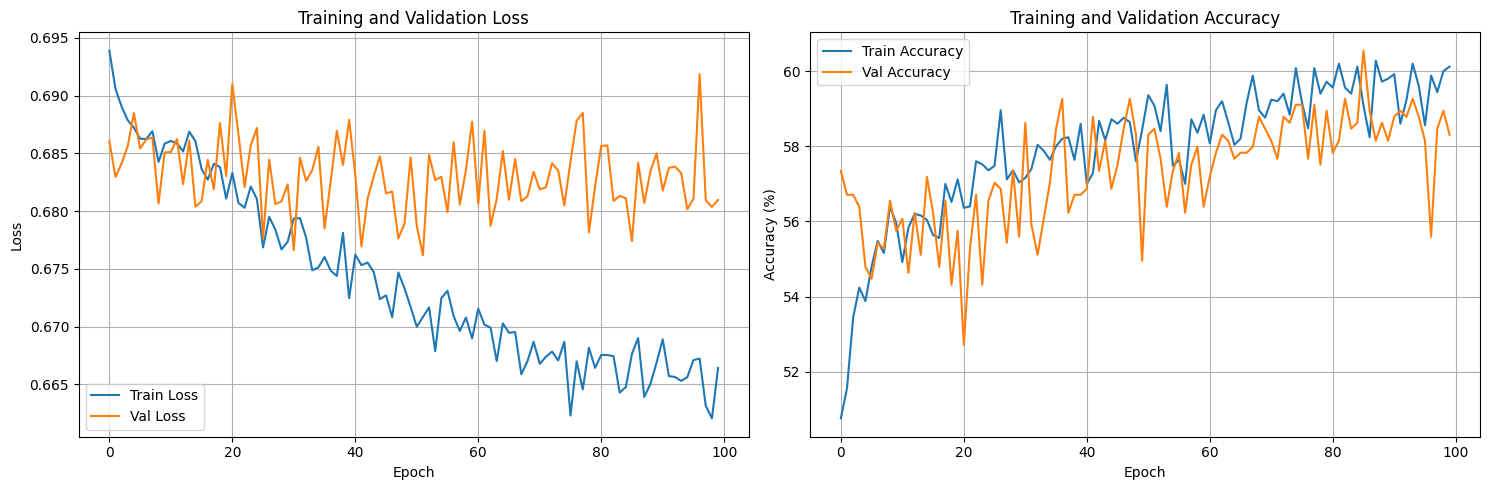


Generating ROC Curve...


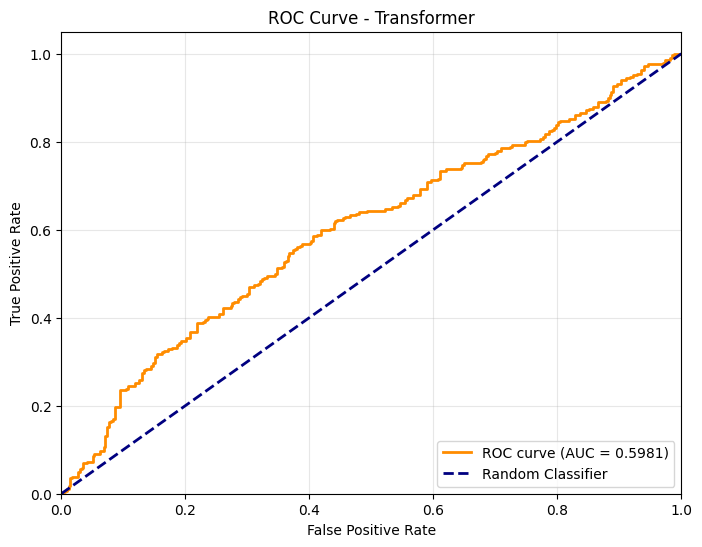


Analyzing Probability Distribution...


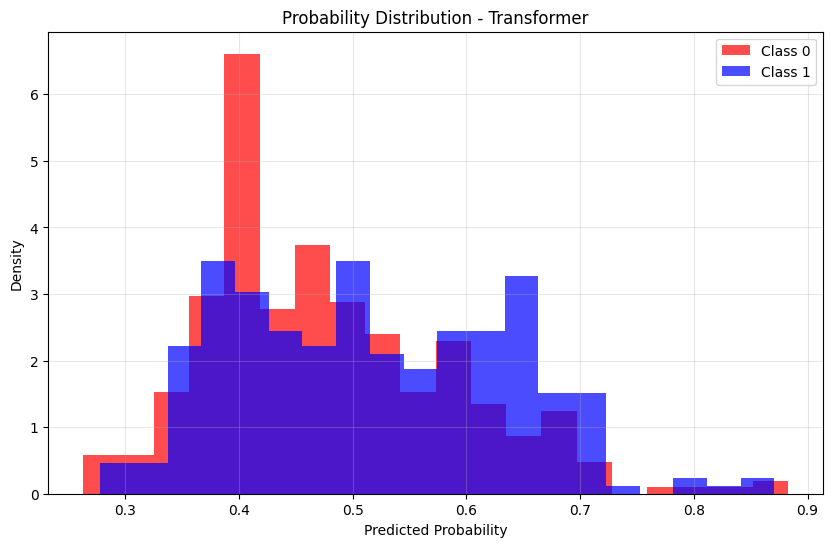

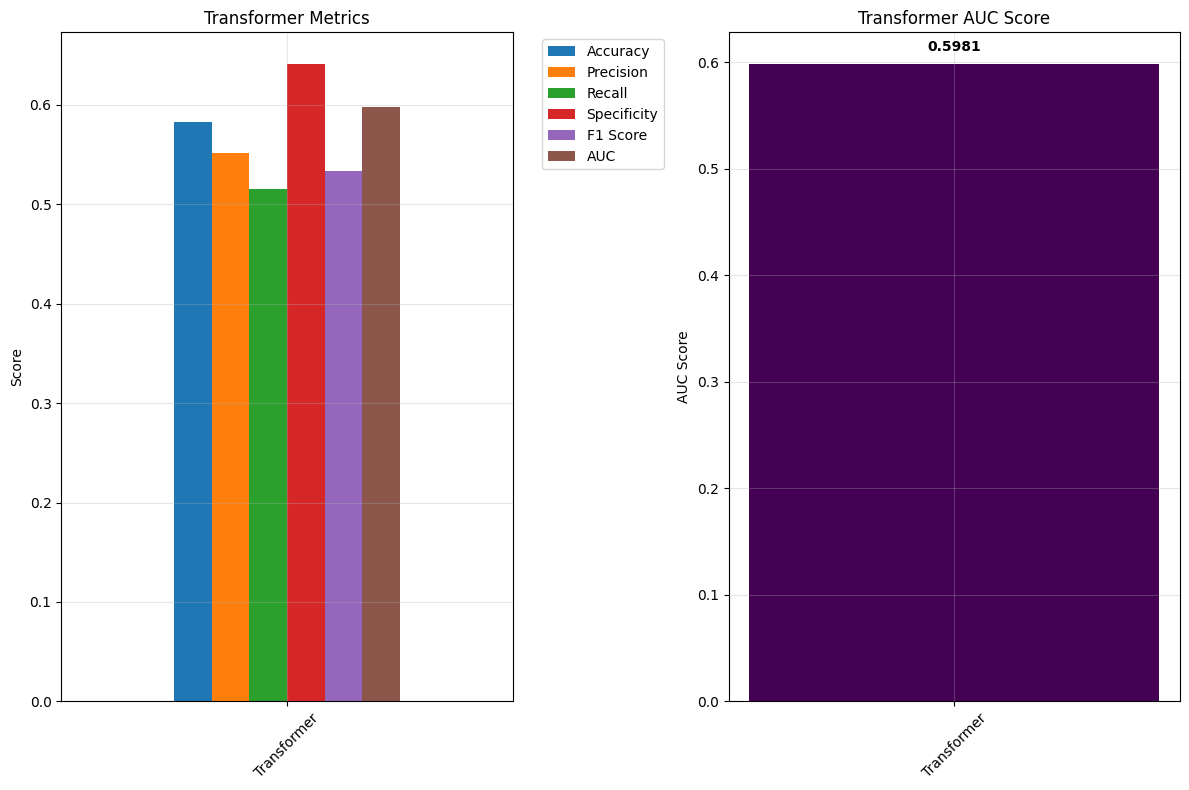


TRANSFORMER TRAINING COMPLETED
Best validation accuracy: 60.54%
Best validation loss: 0.6762
Final AUC: 0.5981

MULTIPLE RUNS FOR RELIABLE AUC ESTIMATION

Run 1/3
------------------------------
🚀 TRANSFORMER MODEL TRAINING WITH AUC
Model Parameters:
  Embedding Dimension: 256
  Number of Heads: 8
  Number of Layers: 1
  Dropout: 0.1
Training Parameters:
  Epochs: 100
  Learning Rate: 0.0001
  Batch Size: 32
Preparing data...
After SMOTE - X shape: (3126, 2), y distribution: [1563 1563]
Training samples: 2500
Validation samples: 626
Model initialized with input_dim: 2, num_classes: 2
Total parameters: 959,810

Starting training...
Epoch [10/100]
  Train Loss: 0.6870, Train Acc: 55.48%
  Val Loss: 0.6867, Val Acc: 57.67%
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.6827, Train Acc: 56.20%
  Val Loss: 0.6849, Val Acc: 55.59%
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.6800, Train Acc: 57.08%
  Val Loss: 0.6843, Va

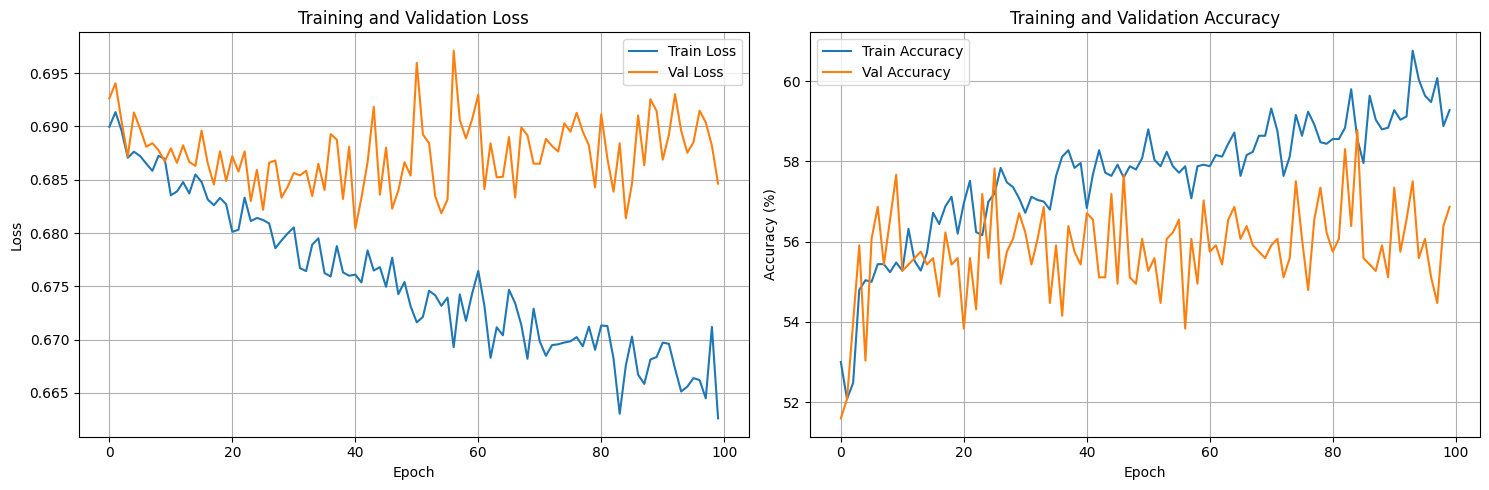


Generating ROC Curve...


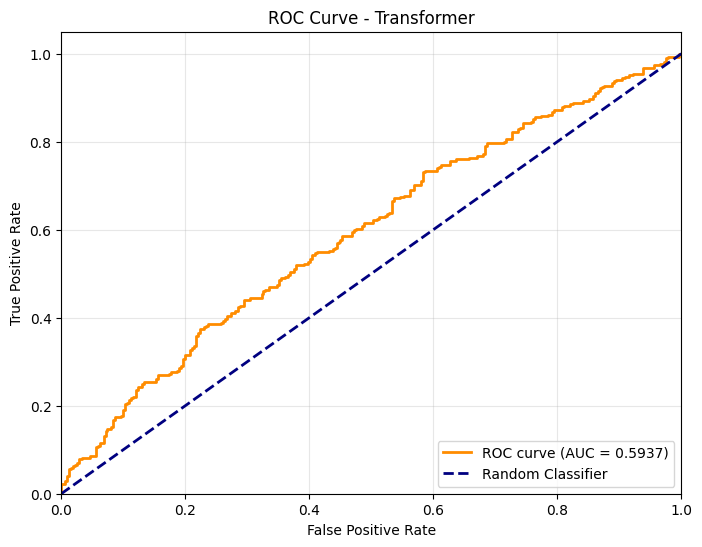


Analyzing Probability Distribution...


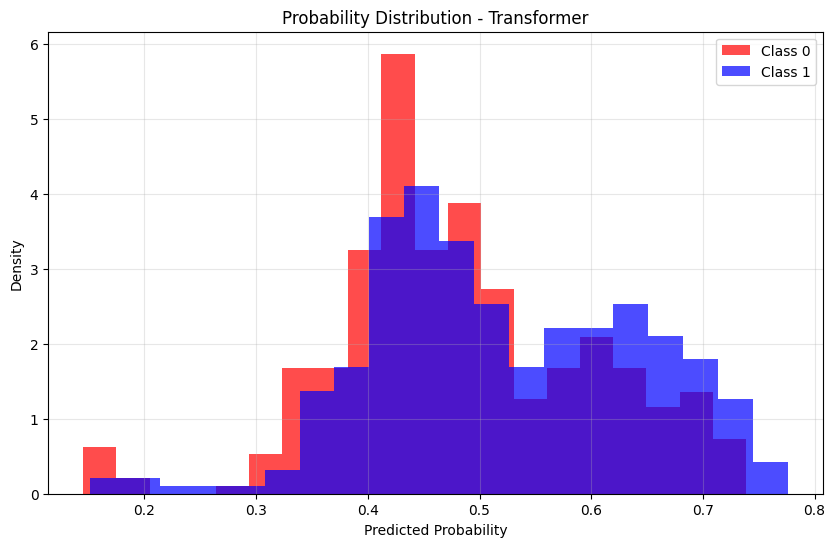

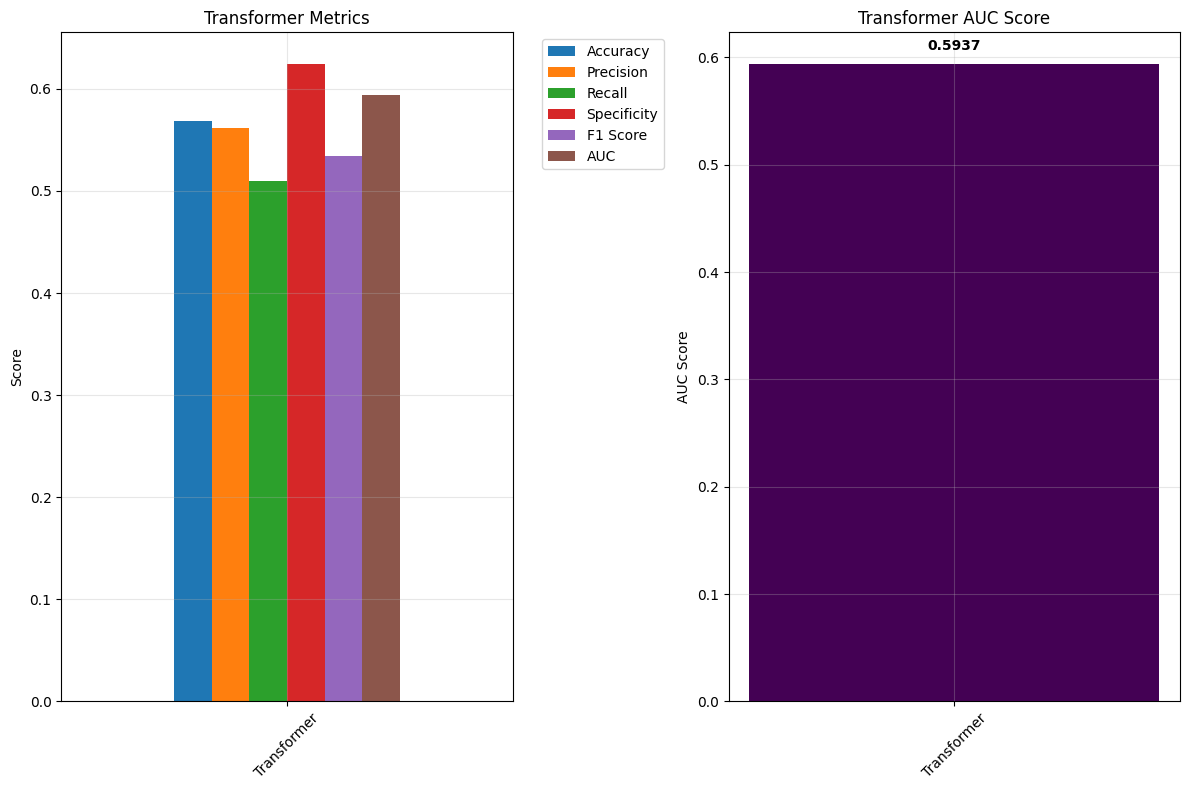

Run 1 AUC: 0.5937

Run 2/3
------------------------------
🚀 TRANSFORMER MODEL TRAINING WITH AUC
Model Parameters:
  Embedding Dimension: 256
  Number of Heads: 8
  Number of Layers: 1
  Dropout: 0.1
Training Parameters:
  Epochs: 100
  Learning Rate: 0.0001
  Batch Size: 32
Preparing data...
After SMOTE - X shape: (3126, 2), y distribution: [1563 1563]
Training samples: 2500
Validation samples: 626
Model initialized with input_dim: 2, num_classes: 2
Total parameters: 959,810

Starting training...
Epoch [10/100]
  Train Loss: 0.6830, Train Acc: 56.08%
  Val Loss: 0.6880, Val Acc: 53.04%
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.6839, Train Acc: 55.84%
  Val Loss: 0.6856, Val Acc: 53.51%
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.6793, Train Acc: 57.08%
  Val Loss: 0.6872, Val Acc: 56.55%
--------------------------------------------------
Epoch [40/100]
  Train Loss: 0.6733, Train Acc: 57.56%
  Val Loss: 0.685

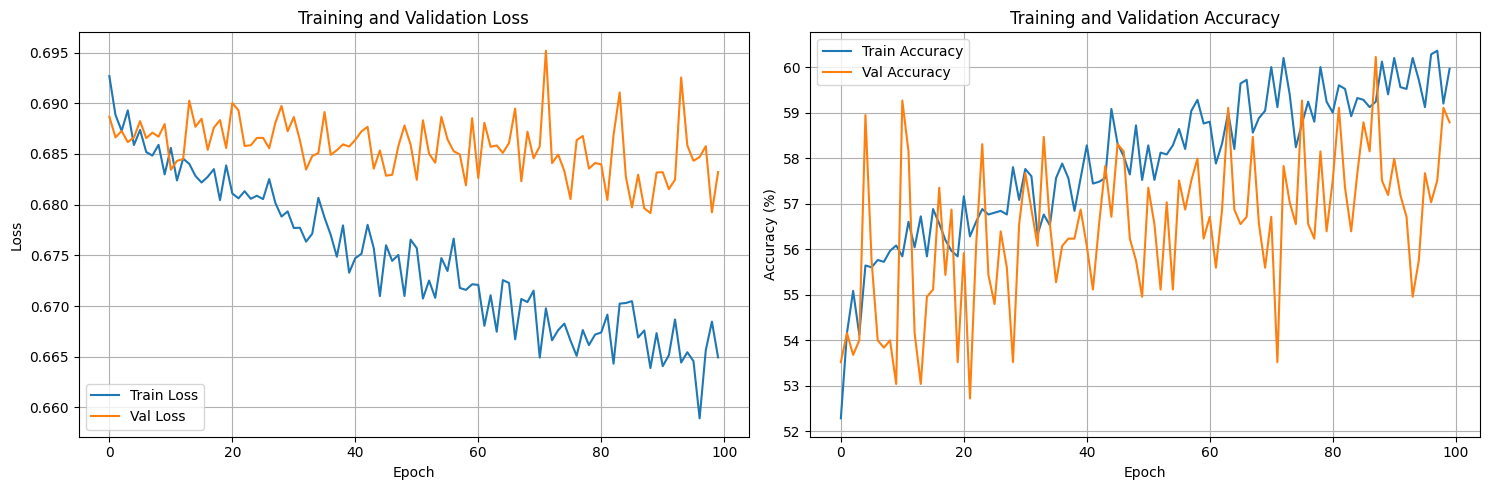


Generating ROC Curve...


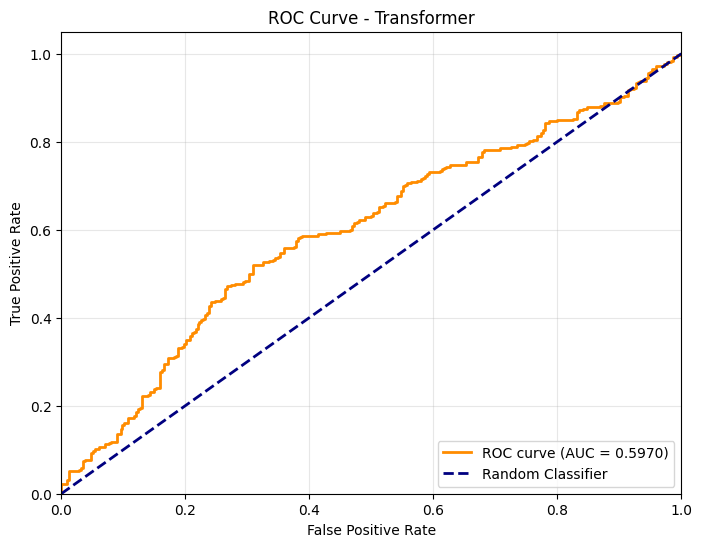


Analyzing Probability Distribution...


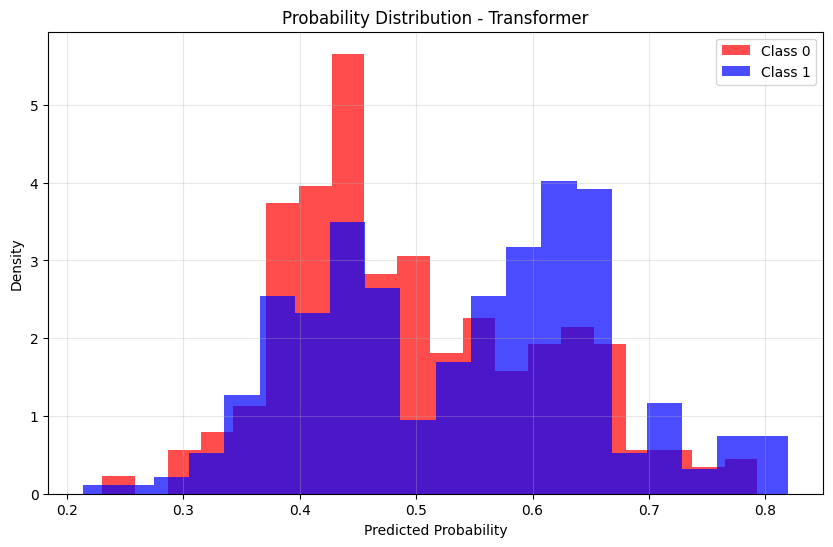

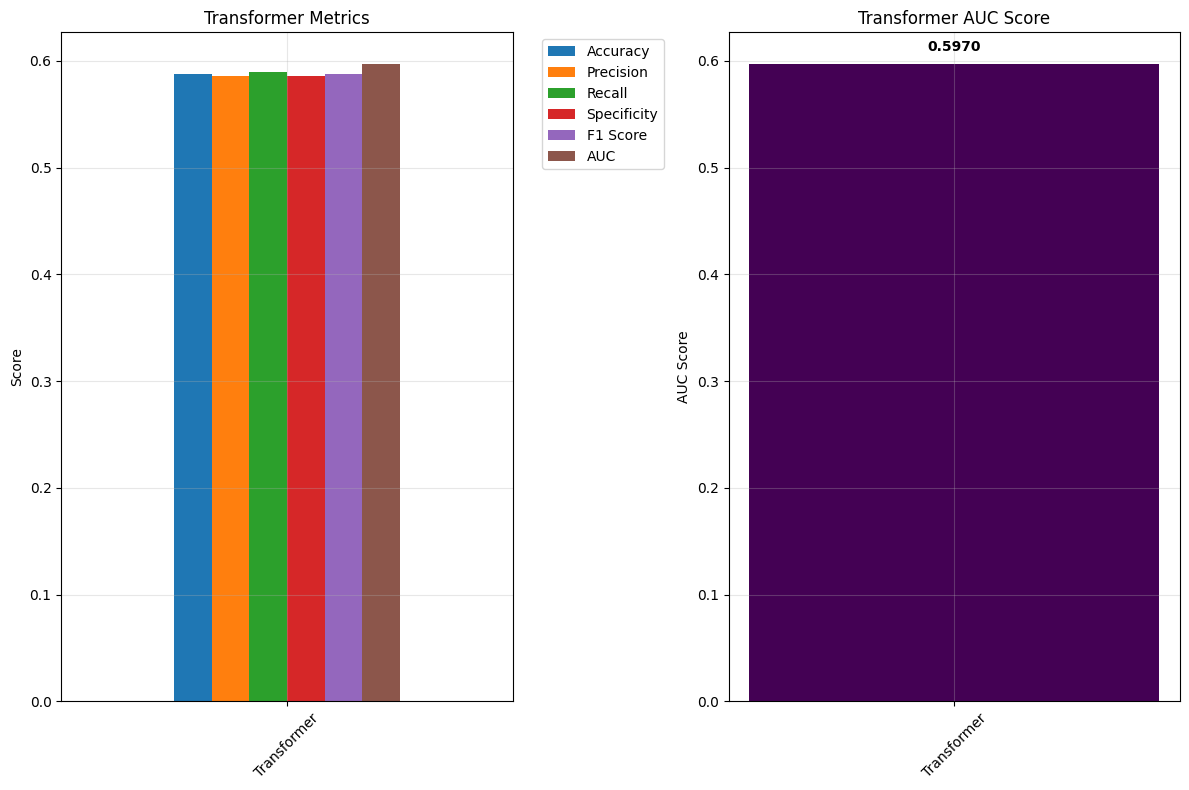

Run 2 AUC: 0.5970

Run 3/3
------------------------------
🚀 TRANSFORMER MODEL TRAINING WITH AUC
Model Parameters:
  Embedding Dimension: 256
  Number of Heads: 8
  Number of Layers: 1
  Dropout: 0.1
Training Parameters:
  Epochs: 100
  Learning Rate: 0.0001
  Batch Size: 32
Preparing data...
After SMOTE - X shape: (3126, 2), y distribution: [1563 1563]
Training samples: 2500
Validation samples: 626
Model initialized with input_dim: 2, num_classes: 2
Total parameters: 959,810

Starting training...
Epoch [10/100]
  Train Loss: 0.6824, Train Acc: 56.44%
  Val Loss: 0.6955, Val Acc: 52.40%
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.6798, Train Acc: 56.92%
  Val Loss: 0.6950, Val Acc: 53.04%
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.6769, Train Acc: 57.68%
  Val Loss: 0.6944, Val Acc: 52.72%
--------------------------------------------------
Epoch [40/100]
  Train Loss: 0.6714, Train Acc: 58.08%
  Val Loss: 0.693

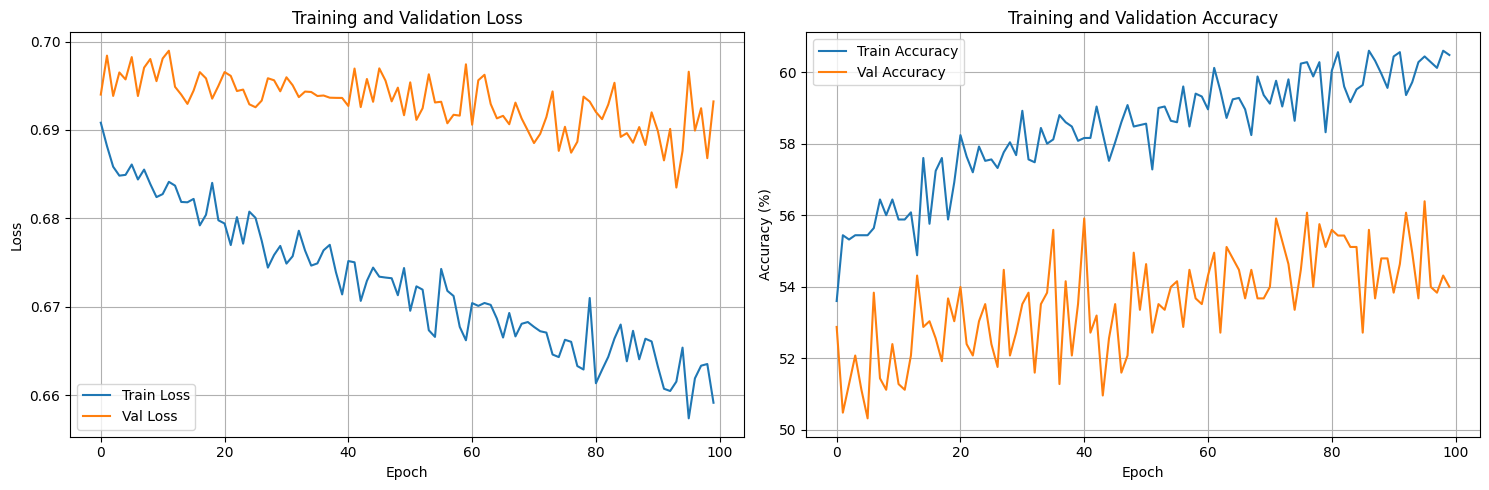


Generating ROC Curve...


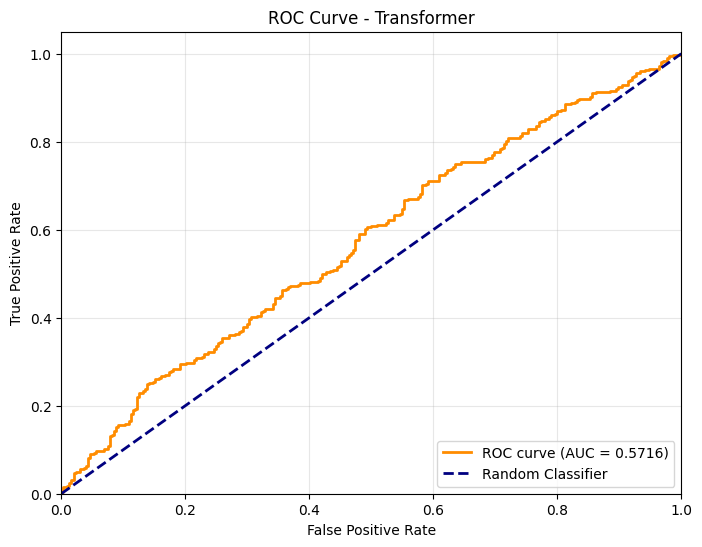


Analyzing Probability Distribution...


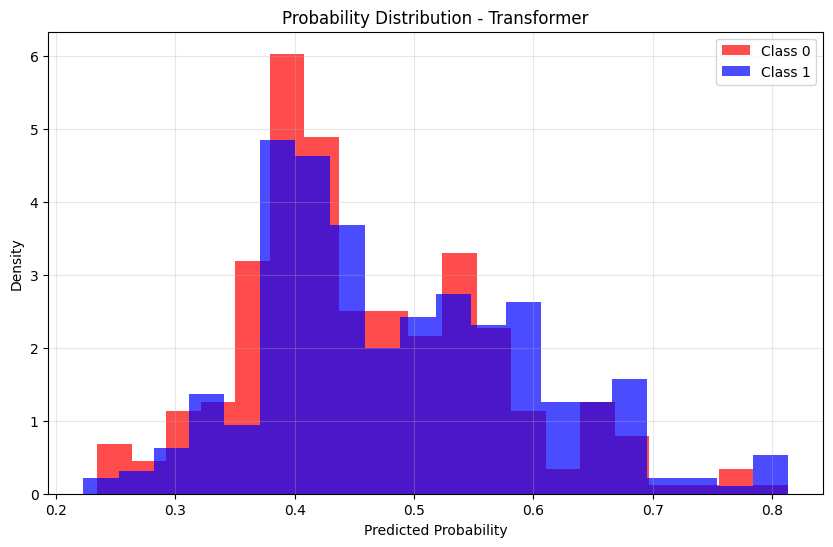

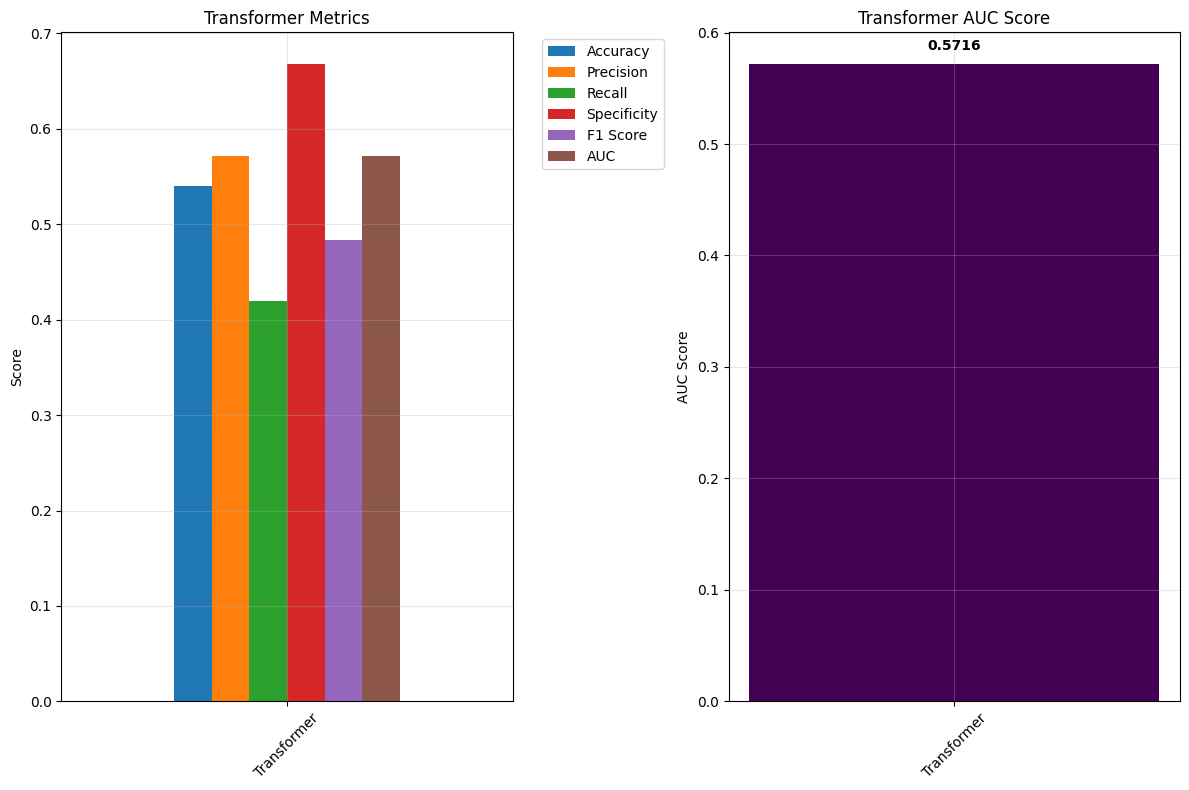

Run 3 AUC: 0.5716

AUC Statistics over 3 runs:
Mean AUC: 0.5874
Std AUC: 0.0112
Min AUC: 0.5716
Max AUC: 0.5970


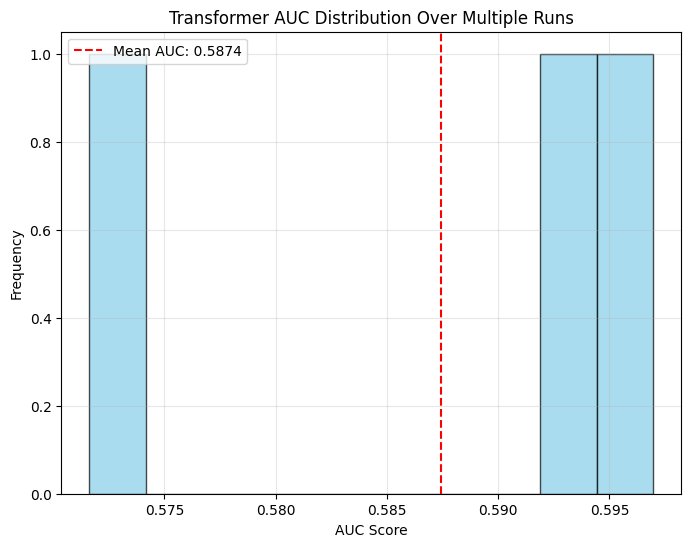


Model saved as 'transformer_model.pth'


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Transformer Model Definition
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, embed_dim=256, num_heads=8, num_layers=1, num_classes=2, dropout=0.1, max_seq_len=500):
        super(TransformerClassifier, self).__init__()
        
        self.embed_dim = embed_dim
        self.input_projection = nn.Linear(input_dim, embed_dim)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_seq_len, embed_dim))
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        batch_size, seq_len, input_dim = x.shape
        
        # Project input to embedding dimension
        x = self.input_projection(x)  # (batch_size, seq_len, embed_dim)
        
        # Add positional encoding
        x = x + self.pos_encoding[:, :seq_len, :]
        
        # Transformer encoder
        x = self.transformer_encoder(x)  # (batch_size, seq_len, embed_dim)
        
        # Use the first token representation for classification (like [CLS] token)
        x = x[:, 0, :]  # (batch_size, embed_dim)
        
        # Classification
        x = self.classifier(x)  # (batch_size, num_classes)
        
        return x

# Data Preparation Functions
def prepare_transformer_data(X, y, sequence_length=1, apply_smote=True, random_state=42):
    """
    Prepare data for Transformer model
    """
    # Convert to numpy if they are DataFrames
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values
    
    # Apply SMOTE if requested
    if apply_smote:
        smote = SMOTE(random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X, y)
        print(f"After SMOTE - X shape: {X_resampled.shape}, y distribution: {np.bincount(y_resampled)}")
        X, y = X_resampled, y_resampled
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reshape for Transformer: (samples, sequence_length, features)
    # For tabular data, we treat each sample as a sequence of length 1
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], sequence_length, X_scaled.shape[1])
    
    # Convert to PyTorch tensors
    X_tensor = torch.FloatTensor(X_reshaped)
    y_tensor = torch.LongTensor(y)
    
    return X_tensor, y_tensor, scaler

def create_data_loaders(X_tensor, y_tensor, batch_size=32, train_ratio=0.8):
    """
    Create train and validation data loaders
    """
    dataset = TensorDataset(X_tensor, y_tensor)
    
    # Split dataset
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

# Training Functions
def train_transformer(model, train_loader, val_loader, criterion, optimizer, num_epochs=100):
    """
    Train the Transformer model
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []
        all_probabilities = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
                
                # Get probabilities for AUC calculation
                probabilities = torch.softmax(outputs, dim=1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
        
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            best_probabilities = all_probabilities
            best_labels = all_labels
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}%')
            print(f'  Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracy:.2f}%')
            print('-' * 50)
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'model': model,
        'best_probabilities': best_probabilities,
        'best_labels': best_labels
    }

# Evaluation Functions
def evaluate_model_pytorch(model, data_loader):
    """
    Evaluate the model and return metrics including AUC
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            
            # Get probabilities for AUC calculation
            probabilities = torch.softmax(outputs, dim=1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_probabilities = np.array(all_probabilities)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    # Calculate AUC
    auc = roc_auc_score(all_labels, all_probabilities[:, 1])
    
    # Calculate specificity from confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        specificity = 0
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Sensitivity': recall,  # Same as recall
        'Specificity': specificity,
        'F1 Score': f1,
        'AUC': auc,
        'Predictions': all_preds,
        'True_Labels': all_labels,
        'Probabilities': all_probabilities
    }

def plot_training_history(history):
    """
    Plot training history
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot losses
    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracies
    ax2.plot(history['train_accuracies'], label='Train Accuracy')
    ax2.plot(history['val_accuracies'], label='Val Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_proba, model_name="Transformer"):
    """
    Plot ROC curve for the model
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return auc, fpr, tpr

def plot_probability_distribution(y_true, y_proba, model_name="Transformer"):
    """
    Plot probability distribution for the model
    """
    plt.figure(figsize=(10, 6))
    
    # Separate probabilities by true class
    proba_class_0 = y_proba[y_true == 0]
    proba_class_1 = y_proba[y_true == 1]
    
    plt.hist(proba_class_0, alpha=0.7, label='Class 0', bins=20, color='red', density=True)
    plt.hist(proba_class_1, alpha=0.7, label='Class 1', bins=20, color='blue', density=True)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.title(f'Probability Distribution - {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_metrics_comparison(metrics_dict, figsize=(12, 8)):
    """
    Plot comparison of all metrics including AUC
    """
    metrics_df = pd.DataFrame(metrics_dict).T
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1 Score', 'AUC']
    available_metrics = [metric for metric in metrics_to_plot if metric in metrics_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot for metrics
    metrics_df[available_metrics].plot(kind='bar', ax=axes[0], rot=45)
    axes[0].set_title('Transformer Metrics')
    axes[0].set_ylabel('Score')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # AUC-focused comparison
    if 'AUC' in metrics_df.columns:
        auc_sorted = metrics_df.sort_values('AUC', ascending=False)
        colors = plt.cm.viridis(np.linspace(0, 1, len(auc_sorted)))
        bars = axes[1].bar(range(len(auc_sorted)), auc_sorted['AUC'], color=colors)
        axes[1].set_title('Transformer AUC Score')
        axes[1].set_ylabel('AUC Score')
        axes[1].set_xticks(range(len(auc_sorted)))
        axes[1].set_xticklabels(auc_sorted.index, rotation=45)
        axes[1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, auc_sorted['AUC']):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Main Training Function
def train_transformer_model(X, y, model_params=None, training_params=None):
    """
    Main function to train Transformer model
    """
    # Default parameters
    if model_params is None:
        model_params = {
            'embed_dim': 256,
            'num_heads': 8,
            'num_layers': 1,
            'dropout': 0.1,
            'sequence_length': 1
        }
    
    if training_params is None:
        training_params = {
            'num_epochs': 100,
            'learning_rate': 0.0001,
            'batch_size': 32,
            'train_ratio': 0.8
        }
    
    print("🚀 TRANSFORMER MODEL TRAINING WITH AUC")
    print("="*50)
    print(f"Model Parameters:")
    print(f"  Embedding Dimension: {model_params['embed_dim']}")
    print(f"  Number of Heads: {model_params['num_heads']}")
    print(f"  Number of Layers: {model_params['num_layers']}")
    print(f"  Dropout: {model_params['dropout']}")
    print(f"Training Parameters:")
    print(f"  Epochs: {training_params['num_epochs']}")
    print(f"  Learning Rate: {training_params['learning_rate']}")
    print(f"  Batch Size: {training_params['batch_size']}")
    print("="*50)
    
    # Prepare data
    print("Preparing data...")
    X_tensor, y_tensor, scaler = prepare_transformer_data(
        X, y, 
        sequence_length=model_params['sequence_length'],
        apply_smote=True
    )
    
    # Create data loaders
    train_loader, val_loader = create_data_loaders(
        X_tensor, y_tensor,
        batch_size=training_params['batch_size'],
        train_ratio=training_params['train_ratio']
    )
    
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    
    # Initialize model
    input_dim = X_tensor.shape[2]  # Number of features
    num_classes = len(np.unique(y))
    
    model = TransformerClassifier(
        input_dim=input_dim,
        embed_dim=model_params['embed_dim'],
        num_heads=model_params['num_heads'],
        num_layers=model_params['num_layers'],
        num_classes=num_classes,
        dropout=model_params['dropout']
    ).to(device)
    
    print(f"Model initialized with input_dim: {input_dim}, num_classes: {num_classes}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=training_params['learning_rate'])
    
    # Train model
    print("\nStarting training...")
    history = train_transformer(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=training_params['num_epochs']
    )
    
    # Evaluate on validation set
    print("\nFinal Evaluation:")
    val_metrics = evaluate_model_pytorch(model, val_loader)
    
    print("Validation Results:")
    for metric, value in val_metrics.items():
        if metric not in ['Predictions', 'True_Labels', 'Probabilities']:
            print(f"  {metric}: {value:.4f}")
    
    # Plot training history
    plot_training_history(history)
    
    # Plot ROC curve
    print("\nGenerating ROC Curve...")
    auc_score, fpr, tpr = plot_roc_curve(
        val_metrics['True_Labels'], 
        val_metrics['Probabilities'][:, 1],
        "Transformer"
    )
    
    # Plot probability distribution
    print("\nAnalyzing Probability Distribution...")
    plot_probability_distribution(
        val_metrics['True_Labels'],
        val_metrics['Probabilities'][:, 1],
        "Transformer"
    )
    
    # Create metrics dictionary for comparison
    metrics_dict = {
        "Transformer": {
            'Accuracy': val_metrics['Accuracy'],
            'Precision': val_metrics['Precision'],
            'Recall': val_metrics['Recall'],
            'Specificity': val_metrics['Specificity'],
            'F1 Score': val_metrics['F1 Score'],
            'AUC': val_metrics['AUC']
        }
    }
    
    # Plot metrics comparison
    plot_metrics_comparison(metrics_dict)
    
    return {
        'model': history['model'],
        'history': history,
        'val_metrics': val_metrics,
        'scaler': scaler,
        'model_params': model_params,
        'training_params': training_params,
        'auc_score': auc_score
    }

# Function for inference with probabilities
def predict_transformer_with_probabilities(model, X, scaler, sequence_length=1):
    """
    Make predictions and return probabilities using trained Transformer model
    """
    model.eval()
    
    # Preprocess input
    X_scaled = scaler.transform(X)
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], sequence_length, X_scaled.shape[1])
    X_tensor = torch.FloatTensor(X_reshaped).to(device)
    
    with torch.no_grad():
        outputs = model(X_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs.data, 1)
    
    return predictions.cpu().numpy(), probabilities.cpu().numpy()

# Function to calculate AUC for multiple runs
def calculate_transformer_auc_multiple_runs(X, y, n_runs=5, model_params=None, training_params=None):
    """
    Calculate AUC over multiple runs to get more reliable results
    """
    auc_scores = []
    all_metrics = []
    
    for run in range(n_runs):
        print(f"\nRun {run + 1}/{n_runs}")
        print("-" * 30)
        
        try:
            results = train_transformer_model(X, y, model_params, training_params)
            auc_scores.append(results['auc_score'])
            all_metrics.append(results['val_metrics'])
            
            print(f"Run {run + 1} AUC: {results['auc_score']:.4f}")
            
        except Exception as e:
            print(f"Error in run {run + 1}: {e}")
            continue
    
    if auc_scores:
        print(f"\nAUC Statistics over {len(auc_scores)} runs:")
        print(f"Mean AUC: {np.mean(auc_scores):.4f}")
        print(f"Std AUC: {np.std(auc_scores):.4f}")
        print(f"Min AUC: {np.min(auc_scores):.4f}")
        print(f"Max AUC: {np.max(auc_scores):.4f}")
        
        # Plot AUC distribution
        plt.figure(figsize=(8, 6))
        plt.hist(auc_scores, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(np.mean(auc_scores), color='red', linestyle='--', label=f'Mean AUC: {np.mean(auc_scores):.4f}')
        plt.xlabel('AUC Score')
        plt.ylabel('Frequency')
        plt.title('Transformer AUC Distribution Over Multiple Runs')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return auc_scores, all_metrics

# Example usage
if __name__ == "__main__":
    # Your data
    # X, y = embedding_custom, y
    
    # Define parameters
    model_params = {
        'embed_dim': 256,
        'num_heads': 8,
        'num_layers': 1,
        'dropout': 0.1,
        'sequence_length': 1
    }
    
    training_params = {
        'num_epochs': 100,
        'learning_rate': 0.0001,
        'batch_size': 32,
        'train_ratio': 0.8
    }
    
    # Train the model
    print("Single Run Training:")
    results = train_transformer_model(
        embedding_custom, y,
        model_params=model_params,
        training_params=training_params
    )
    
    print("\n" + "="*80)
    print("TRANSFORMER TRAINING COMPLETED")
    print("="*80)
    print(f"Best validation accuracy: {max(results['history']['val_accuracies']):.2f}%")
    print(f"Best validation loss: {min(results['history']['val_losses']):.4f}")
    print(f"Final AUC: {results['auc_score']:.4f}")
    
    # Multiple runs for more reliable AUC
    print("\n" + "="*80)
    print("MULTIPLE RUNS FOR RELIABLE AUC ESTIMATION")
    print("="*80)
    auc_scores, all_metrics = calculate_transformer_auc_multiple_runs(
        embedding_custom, y,
        n_runs=3,  # You can increase this number for more reliable results
        model_params=model_params,
        training_params=training_params
    )
    
    # Save model
    torch.save({
        'model_state_dict': results['model'].state_dict(),
        'model_params': results['model_params'],
        'training_params': results['training_params'],
        'scaler': results['scaler'],
        'val_metrics': results['val_metrics'],
        'auc_score': results['auc_score']
    }, 'transformer_model.pth')
    
    print("\nModel saved as 'transformer_model.pth'")